<a href="https://colab.research.google.com/github/tsbawa61/Machine-Learning/blob/master/FinalChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.kill(os.getpid(), 9)

### Mounting Device

In [1]:
import os
from google.colab import drive

mount_point = '/content/drive'
if not os.path.exists(mount_point):
    drive.mount(mount_point)
    # print(f"Drive mounted at {mount_point}")
else:
    print(f"Drive already mounted at {mount_point}, to forcibly remount, call drive.mount(fileName, force_remount=True).")

print("Current Working Directory :", os.getcwd())

ValueError: mount failed

# Optional: Install neccessary packages

In [ ]:
# To install a missing library
# !pip install streamlit

# !npm install localtunnel

# pip install Boruta

# Setting Environment
---

#### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

from google.colab import drive
import sys
import os

from google.colab import files
import shutil

from datetime import datetime
from scipy import stats

# import streamlit as st

# pip install jupyterlab-code-bookmarks
print("Done : Import Environment has been Setup ")


Done : Import Environment has been Setup 


In [ ]:
# from sklearn.model_selection import GridSearchCV

#### Defining path to directory containing your .py file

In [ ]:

# Define the path to the directory containing your .py file
# Modify this path to match your file's actual location in Google Drive
file_path = '/content/drive/MyDrive/ColabNotebooks/'

# Add the path to the system path
sys.path.insert(0, file_path)

print("System Path : ", sys.path)

System Path :  ['/content/drive/MyDrive/ColabNotebooks/', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']


### Initializing Variables

In [ ]:
folder_visualization_output = '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output'
folder_Modelling_output = "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"

metric_precision_parameters=['Metric', 'Feature Selection Method', 'Accuracy', 'AUC Score', 'Gini Coefficient', 'F1 Score', 'Precision', 'Recall']


# Writing Utility Functions and importing them

---



#### my_utils.py file

In [ ]:
%%writefile my_utils.py

def check_file_type(filename):
    import os
    _, ext = os.path.splitext(filename)
    ext = ext.lower()
    if ext == '.csv':
        return 'CSV'
    elif ext in ['.xls', '.xlsx']:
        return 'Excel'
    else:
        return 'Unknown'

def dfDescribe(df, fileV):
  import os
  # import textwrap

  df.describe().to_string(fileV)
  strV, _ = os.path.splitext(fileV)
  print(f"\n \u001b[1m df{strV} \u001b[0m \n")
  with open(fileV, "r") as f:
    print(f.read())

# Wrap text to 100 characters
    # wrapped_text = textwrap.fill(f.read(), width=100)

def dateOnlyCols(df) :
  from datetime import datetime
  import pandas as pd

  date_cols = []
    # df=dfSubscriptions
  for col in df.columns:
      if df[col].dtype == 'object':
          try:
              pd.to_datetime(df[col], errors='raise',format='%m/%d/%Y')
              date_cols.append(col)
          except (ValueError, TypeError):
              continue
  return date_cols

from sklearn.metrics import accuracy_score
def modelPerformance(y_true, predictions) :
  print(f"Accuracy: {accuracy_score(y_true, predictions)}")


def tableToImage(df, titleV, widthFig=8, height_Fig=4, decimal_places=None, destination_folder=None, image_file=None):
  """
    Converts DataFrame Information into an Image
  """
  import matplotlib.pyplot as plt
  import pandas as pd
  import os
  import re


  # Get the value counts of the 'age_band' column
  # age_band_counts = df['age_band'].value_counts().reset_index()
  # age_band_counts.columns = ['Age Band', 'Count']
  if destination_folder is None:
    destination_folder = '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output'

  if image_file is None:
    if not os.path.exists(destination_folder):
      os.makedirs(destination_folder)
    if titleV.strip == "" :
      titleV = "Tmp"
    image_file = titleV.replace(" ", "")
    # [^a-zA-Z0-9] means "anything that is NOT a letter or number"
    image_file = re.sub(r'[^a-zA-Z0-9]', '', image_file) + ".png"

  # Create a figure and an axes object
  fig, ax = plt.subplots(figsize=(widthFig, height_Fig)) # Adjust figure size as needed

  # Hide axes
  ax.axis('off')
  ax.axis('tight')

  if decimal_places is not None:
    df = df.round(decimal_places)

  # Create a table
  # Create the table and add it to the axes
  table = ax.table(cellText=df.values,
                  colLabels=df.columns,
                  loc='center',
                  cellLoc='left')

  # Adjust font size and layout
  table.auto_set_font_size(False)
  table.set_fontsize(10)
  table.auto_set_column_width(col=list(range(len(df.columns))))

  # plt.title('Distribution of Age Bands', loc='center', fontsize=14)
  plt.title(titleV, loc='center', fontsize=14)
  fig.tight_layout()

  # Save the figure to an image file before displaying it
  plt.savefig(image_file, bbox_inches='tight', dpi=300)
  print(f"Table with Title {titleV} saved as {image_file}")
  move_file_to_folder(image_file, destination_folder)
  plt.show()

def capitalized(str,delimiter='_'):
  str = str.replace(delimiter, " ")
  return str.title()

leftoverAminusB = lambda A, B: list(set(A) - set(B))


def move_file_to_folder(source_file, target_folder):
  import os, shutil

  # Ensure your Google Drive is mounted
  # If it's not already mounted, this will prompt you for authentication
  # mount_point = os.getcwd() # '/content/drive'
  # if not os.path.exists(mount_point):
  #     drive.mount(mount_point)
  # else:
  #     print(f"Drive already mounted at {mount_point}")

  # Replace 'My Drive/SaasChurn' with the actual path in your Drive where you want to save the file


  # Create the target folder in Drive if it doesn't exist
  os.makedirs(target_folder, exist_ok=True)

  # Construct the full destination path using os.path.join()
  destination_file_path = os.path.join(target_folder, source_file)

  # print(f'Source: {source_file_path}, Destination: {destination_file_path}')
  # # Move the file
  shutil.move(source_file, destination_file_path)
  print(f"Moved '{source_file}' to '{destination_file_path}' in your Google Drive.")

def joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
    import pandas as pd
    # print(f"Columns given to {test_name} : ({ len(features_for_test)}) \n",features_for_test)
    #print(df_selected_features)
    # print(f"Features Selected after test {test_name} : ({len(features_selected)}) \n", features_selected)

    #Leftover Unimportant Columns from Columns given to given Test
    leftOut1 = leftoverAminusB(features_for_test, features_selected)
    print(f"\nleftOut1 : Leftover Unimportant Columns: ({len(leftOut1)}) \n" , leftOut1)

    if len(leftOut1) > 0:
      df_leftOut1 = pd.DataFrame(leftOut1, columns=['Features'])
      df_leftOut1[test_name] = 0   #Unimportant Columns
      # print("\ndf_leftOut1 (", len(df_leftOut1), "): \n", df_leftOut1)
      df_features_for_test1 = pd.concat([df_selected_features[['Features',test_name]], df_leftOut1], ignore_index=True)

    else:
      # print("All Features Given For Test Were Selected as Important")
      df_features_for_test1 = df_selected_features[['Features',test_name]]

    # display(df_features_for_test1)
    displayDFsummary(df_features_for_test1,'df_features_for_test1')

    # # #Columns which were not considered for the given Test
    displayString('features_for_test', features_for_test)
    displayString('all_features_list', all_features_list)
    leftOut2 = leftoverAminusB(all_features_list, features_for_test)
    print(f"leftOut2: Columns not considered for {test_name} : ({len(leftOut2)})" , leftOut2)

    if len(leftOut2) > 0:
      df_leftOut2 = pd.DataFrame(leftOut2, columns=['Features'])
      df_leftOut2[test_name] = -1  #These Columns were not considered for the Test
      # print("df_leftOut2", df_leftOut2)
      df_features_for_test = pd.concat([df_features_for_test1, df_leftOut2], ignore_index=True)
    else:
      # print("No Features left Unselected")
      df_features_for_test = df_features_for_test1

    #display(df_features_for_test)
    displayDFsummary(df_features_for_test,'df_features_for_test')

    # # # Merging df_for_column_addition with df_features_for_test
    left_df = df_for_column_addition.merge(df_features_for_test, on='Features', how='left')
    # print("left_df: After Merging\n", left_df.columns)
    # display(left_df)
    # # #Filling features which are not in features_to_keep with ZERO i.e. they are not categoried important by this test
    # # df_features_total=left_df #left_df.fillna(0)

    # # print(f"\n {len(df_features_total)}", df_features_total)
    return left_df

def give_rank__to_columns(df_selected, test_name, is_no_rank=False) :
  df_selected = df_selected.reset_index().rename(columns={'index': 'ID'})
  if is_no_rank:
    df_selected[test_name] = 1
  else:
    df_selected[test_name] = df_selected.index+1
  # print("df_selected Shape: ", df_selected.shape)
  # display(df_selected)
  return df_selected

displayDFsummary = lambda df, df_name: print(f"Summary of Datafrme {df_name} : Shape: ",df.shape, " Type: ", type(df), "\n", "Columns: ", df.columns.to_list())
displayString = lambda messageV, strV: print(f"{messageV} ({len(strV)}) : {strV}")
appendToList = lambda l, x: l.append(x) if x not in l else None


def writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):
  #Write these  feature ranks to an excel file
  df.to_excel(f"{filename}.xlsx", index=False)
  print(f"Dataframe {df_name} saved to {filename}.xlsx")
  move_file_to_folder(f"{filename}.xlsx", destination_folder_path)

def calculate_condition_index(X):
    import numpy as np
    import pandas as pd

    # 1. Standardize the data (Scale to unit length)
    # This is crucial because the Condition Index is scale-sensitive
    X_scaled = X / np.linalg.norm(X, axis=0)

    # 2. Compute the eigenvalues of (X'X)
    xtx = np.dot(X_scaled.T, X_scaled)
    eigenvalues = np.linalg.eigvals(xtx)

    # 3. Sort eigenvalues in descending order
    eigenvalues = np.sort(eigenvalues)[::-1]

    # 4. Calculate Condition Indices
    # Formula: sqrt(max_eigenvalue / current_eigenvalue)
    max_ev = eigenvalues[0]
    condition_indices = np.sqrt(max_ev / eigenvalues)

    # 5. Create a readable output
    ci_df = pd.DataFrame({
        'Eigenvalue': eigenvalues,
        'Condition_Index': condition_indices
    })

    return ci_df


def getClassificationMetrics1(model_name, y_true, predictions, isPrint=True) :
  from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

  # Calculate accuracy
  accuracy_score_value = accuracy_score(y_true, predictions)

  if isPrint:
    print(f"--- {model_name} Model Evaluation ---")
    print(f"Accuracy: {accuracy_score_value:.2%}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, predictions))
    print("\nClassification Report:\n", classification_report(y_true, predictions, zero_division=0))
  return accuracy_score_value

def getClassificationMetrics2(model, X_test, y_test, y_pred, isPrint=True) :
  #(rfc_model_boruta, X_test_boruta, y_test, y_pred_boruta)
  from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

  y_pred_proba = None
  if hasattr(model, 'predict_proba'):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
  elif hasattr(model, 'decision_function'):
    # For models like LinearSVC that provide decision_function instead of predict_proba
    y_pred_proba = model.decision_function(X_test)
  else:
    print("Warning: Model does not have 'predict_proba' or 'decision_function'. AUC/Gini cannot be calculated.")
    auc_score = 0.0
    gini_coefficient = -1.0
    # You might want to return here or handle default values

  if y_pred_proba is not None:
    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # Calculate Gini Coefficient (Gini = 2*AUC - 1)
    gini_coefficient = 2 * auc_score - 1

  # Calculate F1 Score
  f1_value = f1_score(y_test, y_pred, zero_division=0)

  # Calculate Precision
  precision_value = precision_score(y_test, y_pred, zero_division=0)

  # Calculate Recall
  recall_value = recall_score(y_test, y_pred, zero_division=0)

  if isPrint:
    print("\n--- Additional Model Metrics ---")
    print(f"AUC Score: {auc_score:.4f}")
    print(f"Gini Coefficient: {gini_coefficient:.4f}")
    print(f"F1 Score: {f1_value:.4f}")
    print(f"Precision: {precision_value:.4f}")
    print(f"Recall: {recall_value:.4f}")

  return auc_score, gini_coefficient, f1_value, precision_value, recall_value

def currentTimeIST():
    from datetime import datetime, timedelta, timezone
    # Get current UTC time
    now_utc = datetime.now(timezone.utc)
    # IST is UTC+5:30
    now_ist = now_utc + timedelta(hours=5, minutes=30)
    print(f"Current time: {now_ist.strftime('%H:%M:%S')}, Date: {now_ist.strftime('%d-%m-%Y')}")
    return now_ist


Writing my_utils.py


In [ ]:
from datetime import datetime, timedelta, timezone
# Get current UTC time
now_utc = datetime.now(timezone.utc)
# IST is UTC+5:30
now_ist = now_utc + timedelta(hours=5, minutes=30)
print(f"Current time: {now_ist.strftime('%H:%M:%S')}, Date: {now_ist.strftime('%d-%m-%Y')}")


Current time: 11:30:33, Date: 22-03-2026


#### Importing Methods from my_utils

In [ ]:
#importing functions from my_utils

# Reload the module to pick up recent changes

import my_utils
import importlib
importlib.reload(my_utils)

from my_utils import check_file_type, capitalized, leftoverAminusB
from my_utils import move_file_to_folder, joinLists, give_rank__to_columns
from my_utils import appendToList, currentTimeIST

from my_utils import dfDescribe, dateOnlyCols, tableToImage
from my_utils import modelPerformance, calculate_condition_index
from my_utils import displayDFsummary, displayString, writeDFtoXlsx
from my_utils import getClassificationMetrics1, getClassificationMetrics2

In [ ]:
currentTimeIST()

Current time: 11:30:33, Date: 22-03-2026


datetime.datetime(2026, 3, 22, 11, 30, 33, 846578, tzinfo=datetime.timezone.utc)

# Optional: Get the source code

In [ ]:
# Get the source code of E.G. dfDescribe function
import inspect
source_code = inspect.getsource(my_utils.dfDescribe)

print("Current definition of dfDescribe in my_utils.py:")
print(source_code)

#  File Reading

### Read file from Google Drive to the Colab environment

In [ ]:
# First Delete CSV or Excel Files or other designated files in current Google Colab Directory

#  Get the current working directory
current_directory = os.getcwd()
print(f"Current directory: {current_directory}")

# List all files and directories in the current directory
items_in_directory = os.listdir(current_directory)

files_deleted = []
allowed_extensions = ['.csv', '.xls', '.xlsx','.joblib', '.txt']

for item in items_in_directory:
    item_path = os.path.join(current_directory, item)
    if os.path.isfile(item_path):
        file_extension = os.path.splitext(item)[1].lower()
        if file_extension in allowed_extensions:
            try:
                os.remove(item_path)
                files_deleted.append(item)
            except Exception as e:
                print(f"Error deleting {item_path}: {e}")

if files_deleted:
    print("Successfully deleted the following CSV or Excel files:")
    for f in files_deleted:
        print(f"- {f}")
else:
    print("No files with following extensions found and deleted in the current directory.")
    print(allowed_extensions)

Current directory: /content
No files with following extensions found and deleted in the current directory.
['.csv', '.xls', '.xlsx', '.joblib', '.txt']


In [ ]:
# Now Reading a uploaded file into a dataframe and DO Initial Inspection

mountpoint_path =  os.getcwd()

path = '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/input/Customer_Churn_business_dataset.xlsx'

df = pd.read_excel(path)

# Initial inspection
# View first 5 rows
print("\n\t\t\t \033[4m \033[1m-- 1. DATA OVERVIEW --- \033[0m ")

print(f"\n \033[1m Dataset Shape  \033[0m : {df.shape} \n")
print("-"*100)
print("\t\t\t \033[1m First Five Rows:  \033[0m ")
print(df.head())


			  -- 1. DATA OVERVIEW ---  

  Dataset Shape   : (10000, 32) 

----------------------------------------------------------------------------------------------------
			  First Five Rows:   
  customer_id  gender  age     country      city customer_segment  \
0  CUST_00001    Male   68  Bangladesh    London              SME   
1  CUST_00002  Female   57      Canada    Sydney       Individual   
2  CUST_00003    Male   24     Germany  New York              SME   
3  CUST_00004    Male   49   Australia     Dhaka       Individual   
4  CUST_00005    Male   65  Bangladesh     Delhi       Individual   

   tenure_months signup_channel contract_type  monthly_logins  ...  \
0             22            Web       Monthly              26  ...   
1              9         Mobile       Monthly               7  ...   
2             58            Web        Yearly              19  ...   
3             19         Mobile        Yearly              34  ...   
4             52            Web       Mont

# Exploring Data

### Table's Basic Information

#### Table's Various Counts

In [ ]:
# Column Names
import textwrap
print("No of Columns in the Table  : ", len(df.columns))

print("\nColumns in the Table are as Follows:")
print()

long_text = ", ".join(df.columns.to_list())

# Wrap text to 100 characters
wrapped_text = textwrap.fill(long_text, width=100)

print(wrapped_text)

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
# categorical_cols=categorical_cols[1:]
print("No of numeric_cols : ", len(numeric_cols))

print(numeric_cols)


No of Columns in the Table  :  32

Columns in the Table are as Follows:

customer_id, gender, age, country, city, customer_segment, tenure_months, signup_channel,
contract_type, monthly_logins, weekly_active_days, avg_session_time, features_used,
usage_growth_rate, last_login_days_ago, monthly_fee, total_revenue, payment_method,
payment_failures, discount_applied, price_increase_last_3m, support_tickets, avg_resolution_time,
complaint_type, csat_score, escalations, email_open_rate, marketing_click_rate, nps_score,
survey_response, referral_count, churn
No of numeric_cols :  20
['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'churn']


In [ ]:
print("\n\t\t\t \u001b[4m \u001b[1m--- 2. SUMMARY STATISTICS ---\u001b[0m \n")

# Check data types and missing values
print("\t\t\t \u001b[1m Data types and missing values \u001b[0m \n")
print(df.info())



			  --- 2. SUMMARY STATISTICS --- 

			  Data types and missing values  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rat

In [ ]:
# Summary statistics for numeric columns
# print("\n \t\t\t \033[1m Summary statistics for numeric columns \033[0m \n\n", df.describe())
dfDescribe(df, "summaryNumericCols.txt")
print("-"*100)

# Check if column is unique

uniqueColumns = []
dfColumnNames = df.columns.tolist()
for colName in dfColumnNames:
  if df[colName].is_unique:
    uniqueColumns.append(colName)
print(f"\nUnique Columns in the table Are: {"NIL" if uniqueColumns == [] else uniqueColumns}")

#Now checking whether combo of columns is unique
if uniqueColumns == []:
  idColumnNames = [col for col in dfColumnNames if 'id' in col.lower() or 'cd' in col.lower() or 'code' in col.lower()]
  # print(idColumnNames)
  comboUniqueCols= False
  if idColumnNames != [] :
    for colName1  in idColumnNames:
      for colName2 in dfColumnNames:
        if colName1 != colName2:
          is_AB_combo_unique = not df.duplicated(subset=[colName1, colName2]).any()
          if is_AB_combo_unique :
            if comboUniqueCols == False:
              print("  Following Combination of Columns in this table \033[1mis Unique: \033[0m ")
              comboUniqueCols = True
            print(f"\t\t\t\033[1m{colName2}, {colName1} \033[0m ")



  dfsummaryNumericCols  

                age  tenure_months  monthly_logins  weekly_active_days  avg_session_time  features_used  usage_growth_rate  last_login_days_ago   monthly_fee  total_revenue  payment_failures  support_tickets  avg_resolution_time    csat_score   escalations  email_open_rate  marketing_click_rate     nps_score  referral_count         churn
count  10000.000000   10000.000000    10000.000000        10000.000000      10000.000000   10000.000000       10000.000000         10000.000000  10000.000000   10000.000000      10000.000000     10000.000000         10000.000000  10000.000000  10000.000000     10000.000000          10000.000000  10000.000000      10000.0000  10000.000000
mean      45.906100      30.155700       19.672000            3.479400         15.187890       4.990800           0.019423             9.505200     34.930000    1057.018000          0.501000         1.206600            23.953210      3.486700      0.294100         0.499610              0.2535

In [ ]:
# To get specific summary on Numeric Columns

filterRows = ["count", "mean", "min", "max"]
print( df.describe().loc[filterRows])

              age  tenure_months  monthly_logins  weekly_active_days  \
count  10000.0000     10000.0000       10000.000          10000.0000   
mean      45.9061        30.1557          19.672              3.4794   
min       18.0000         1.0000           0.000              0.0000   
max       74.0000        59.0000          54.000              7.0000   

       avg_session_time  features_used  usage_growth_rate  \
count      10000.000000     10000.0000       10000.000000   
mean          15.187890         4.9908           0.019423   
min            1.000000         1.0000          -0.580000   
max           41.996411        15.0000           0.540000   

       last_login_days_ago  monthly_fee  total_revenue  payment_failures  \
count           10000.0000     10000.00      10000.000         10000.000   
mean                9.5052        34.93       1057.018             0.501   
min                 0.0000        10.00         10.000             0.000   
max                80.0000   

#### Missing Values Treatment

In [ ]:
#2. Data Cleaning
# Missing Values Treatment

# Check for null values per column
print("\nMissing Values:\n")

print(df.isnull().sum().sort_values(ascending=False))

# Fill missing 'complaint_type' values with the most frequent

imputer_referral = SimpleImputer(strategy='most_frequent')
df['complaint_type'] = imputer_referral.fit_transform(df[['complaint_type']]).ravel()

# Cannot substitute with median as complaint_type is not numeric
# Fill missing 'complaint_type' values with the median

# imputer_seats = SimpleImputer(strategy='median')
# df['complaint_type'] = imputer_seats.fit_transform(df[['complaint_type']])
# OR use the following
# df['complaint_type_new1'] = df['complaint_type'].fillna(df['complaint_type'].median())

#
# Drop columns with too many missing values or irrelevant info or with high-cardinality or redundant columns
#df.drop(columns=['deck', 'embark_town'], inplace=True)

print("\nMissing Values After Substitution:\n")

print(df.isnull().sum().sort_values(ascending=False))



Missing Values:

complaint_type            2045
customer_id                  0
age                          0
gender                       0
city                         0
customer_segment             0
tenure_months                0
country                      0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
signup_channel               0
monthly_fee                  0
total_revenue                0
payment_failures             0
payment_method               0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                

### Checking Durations

In [ ]:
# Get  the names of only datetime columns

date_cols = dateOnlyCols(df)
print('Date Columns are : ', date_cols)

Date Columns are :  []


### Churn Statistics

value_counts() function : 
 churn
0    8979
1    1021
Name: count, dtype: int64

 value_counts() %ages : 
 churn
0    89.79
1    10.21
Name: proportion, dtype: float64

 df[churn].describe() : 
 count    10000.000000
mean         0.102100
std          0.302795
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churn, dtype: float64


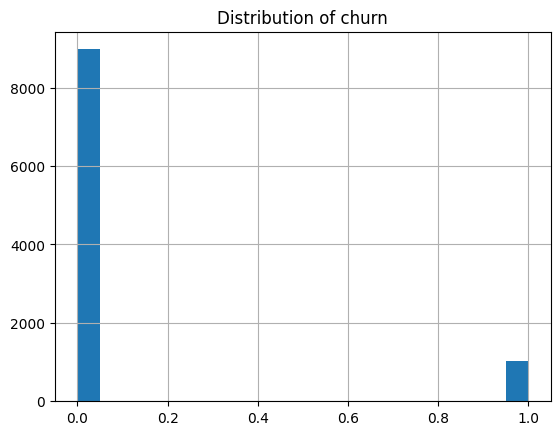

In [ ]:

colName='churn'
counts = df[colName].value_counts()
print('value_counts() function : \n', counts)

percentages = df[colName].value_counts(normalize=True) * 100
print('\n value_counts() %ages : \n', percentages)

print(f'\n df[{colName}].describe() : \n', df[colName].describe())

colNameNum='churn'
df[colNameNum].hist(bins=20)
plt.title(f'Distribution of {colName}')
plt.show()


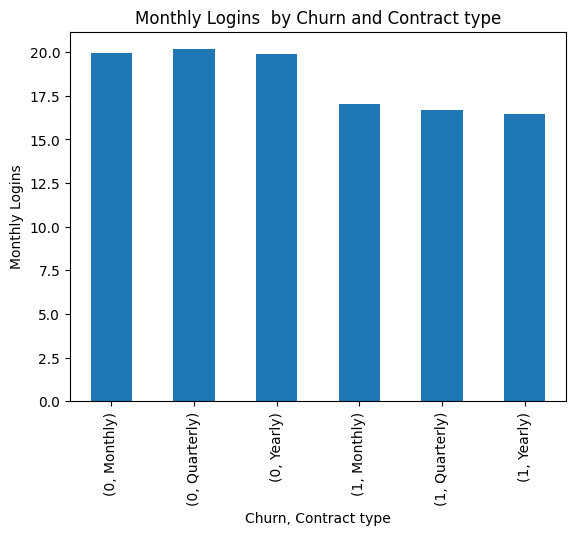

In [ ]:
df.groupby(['churn', 'contract_type'])['monthly_logins'].mean().plot(kind='bar')
plt.title('Monthly Logins  by Churn and Contract type')
plt.ylabel('Monthly Logins')
plt.xlabel('Churn, Contract type')
# plt.xticks(rotation=0)
plt.show()

In [ ]:
# Summarising dfChurnEvents on account_id giving counts and totals

df_survey_summary = df.groupby('survey_response').agg(
    complaint_type_count=('complaint_type', 'count'),
    total_revenue_amount=('total_revenue', 'sum')
).reset_index()

print(f"\033[1mSummary of {capitalized('survey_response')} :\033[0m")
print(df_survey_summary.head())
print(f"\nTotal No of {capitalized('survey_response')}s: {len(df_survey_summary)}")
print(f"Average Complaint Type Count per Survey Response: {df_survey_summary['complaint_type_count'].mean():,.2f}")
print(f"Total revenue amount across all Survey Responses: ${df_survey_summary['total_revenue_amount'].sum():,.0f}")

Summary of Survey Response :
  survey_response  complaint_type_count  total_revenue_amount
0         Neutral                  2978               3121340
1       Satisfied                  4975               5272930
2     Unsatisfied                  2047               2175910

Total No of Survey Responses: 3
Average Complaint Type Count per Survey Response: 3,333.33
Total revenue amount across all Survey Responses: $10,570,180


/tmp/ipykernel_826/2699951654.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


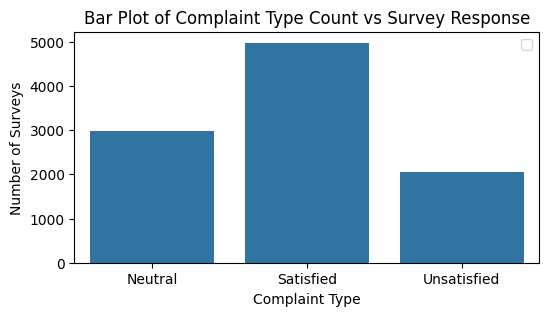

In [ ]:
# Distribution of Complaint Type Count per Survey Response

plt.figure(figsize=(6, 3))
# sns.barplot(df_survey_summary['complaint_type_count'])
sns.barplot(x='survey_response', y='complaint_type_count', data=df_survey_summary)
plt.title('Bar Plot of Complaint Type Count vs Survey Response')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Surveys')
plt.legend()
plt.show()

In [ ]:
# # Calculate the correlation between churn event count and total refund amount

# correlation = df_survey_summary['complaint_type_count'].corr(df_survey_summary['total_revenue_amount'])
# print(f"\033[1m\tCorrelation between Complaint type Count and Total Revenue Amount: {correlation:.2f}\033[0m")

# # Visualize the relationship with a scatter plot
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='complaint_type_count', y='total_revenue_amount', data=df_survey_summary)
# plt.title('\nRelationship between Complaint type Count and Total Revenue Amount Using Scatter Plot\n')
# plt.xlabel('Complaint type Count')
# plt.ylabel('Total Revenue Amount (USD)')
# plt.grid(True)
# plt.show()

In [ ]:
# # Statistical summary for total_revenue_amount

# print("\033[1mStatistical Summary for Total Refund Amount:\033[0m")
# print(df_survey_summary['total_revenue_amount'].describe())

# # Visualization of total_revenue_amount distribution
# plt.figure(figsize=(10, 6))
# sns.histplot(df_survey_summary['total_revenue_amount'], kde=True)
# plt.title('\nDistribution of Total Revenue Amount per Survey\n')
# plt.xlabel('Total Revenue Amount (USD)')
# plt.ylabel('Number of Surveys')
# plt.show()

In [ ]:
# # Calculate total refund amount for each churn reason

# refund_by_reason = dfChurnEvents.groupby('reason_code')['refund_amount_usd'].sum().sort_values(ascending=False)

# # Calculate counts of each churn reason
# churn_reasons_counts = dfChurnEvents['reason_code'].value_counts()

# # Combine these two series into a DataFrame for easier analysis
# churn_refund_analysis = pd.DataFrame({
#     'total_refund_amount_usd': refund_by_reason,
#     'churn_event_count': churn_reasons_counts
# }).fillna(0) # Fill NaN with 0 if a reason has no refunds or no counts


# # Sort by total refund amount to see the biggest impact reasons
# churn_refund_analysis = churn_refund_analysis.sort_values(by='total_refund_amount_usd', ascending=False)

# print("\033[1mChurn Reasons by Total Refund Amount and Event Count:\033[0m")
# display(churn_refund_analysis)

# # Optional: Visualize the relationship between count and refund amount for each reason
# plt.figure(figsize=(12, 7))
# sns.scatterplot(x='churn_event_count', y='total_refund_amount_usd', hue=churn_refund_analysis.index, data=churn_refund_analysis, s=200, palette='viridis')
# plt.title('Relationship Between Churn Event Count and Total Refund Amount by Reason')
# plt.xlabel('Churn Event Count')
# plt.ylabel('Total Refund Amount (USD)')
# plt.grid(True)
# for i, row in churn_refund_analysis.iterrows():
#     plt.text(row['churn_event_count'] + 5, row['total_refund_amount_usd'] + 5, i, fontsize=9)
# plt.tight_layout()
# plt.show()

# # Optional: Visualize the top 5
# plt.figure(figsize=(10, 6))
# sns.barplot(x=refund_by_reason.head(5).index, y=refund_by_reason.head(5).values, hue=refund_by_reason.head(5).index, palette='plasma', legend=False)

# plt.title('Top 5 Churn Reasons by Total Refund Amount')
# plt.xlabel('Churn Reason Code')
# plt.ylabel('Total Refund Amount (USD)')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

### Distribution of All Categorical Columns

In [ ]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn'],
      dtype='object')

In [ ]:
# Finalizing Categorical Columns

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols=categorical_cols[1:]
print("No of categorical_cols Finalized : ", len(categorical_cols))

print(categorical_cols)


No of categorical_cols Finalized :  11
['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']



1 Distribution: gender
Male      5013
Female    4987
Name: count, dtype: int64

2 Distribution: country
Bangladesh    1494
Canada        1488
USA           1442
India         1427
Australia     1400
UK            1382
Germany       1367
Name: count, dtype: int64

3 Distribution: city
London      1518
Sydney      1471
Dhaka       1459
Delhi       1402
Berlin      1386
New York    1385
Toronto     1379
Name: count, dtype: int64


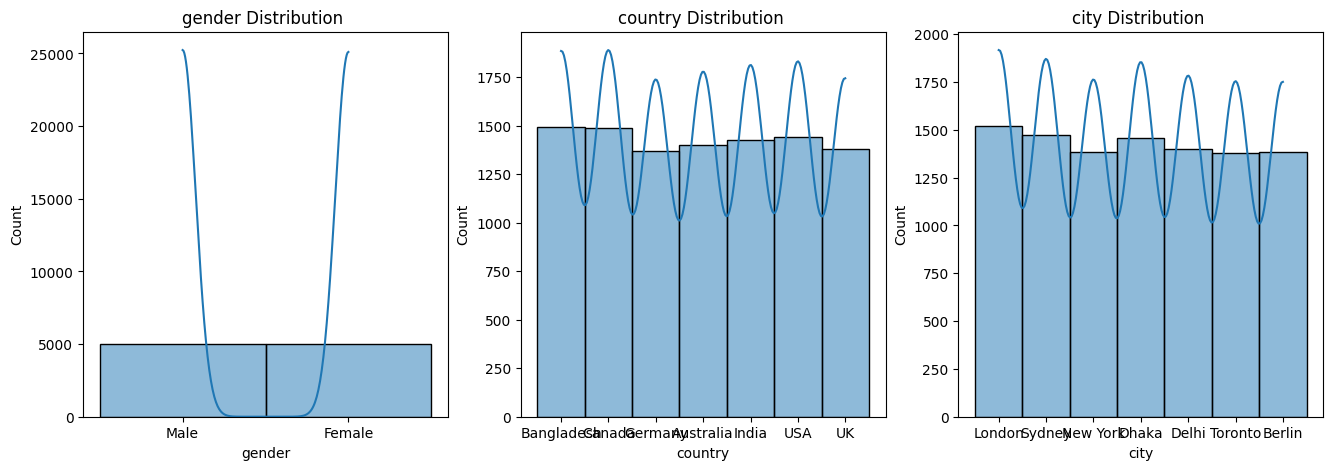


4 Distribution: customer_segment
Individual    5984
SME           3029
Enterprise     987
Name: count, dtype: int64

5 Distribution: signup_channel
Web         5036
Mobile      2960
Referral    2004
Name: count, dtype: int64

6 Distribution: contract_type
Monthly      4967
Quarterly    3050
Yearly       1983
Name: count, dtype: int64


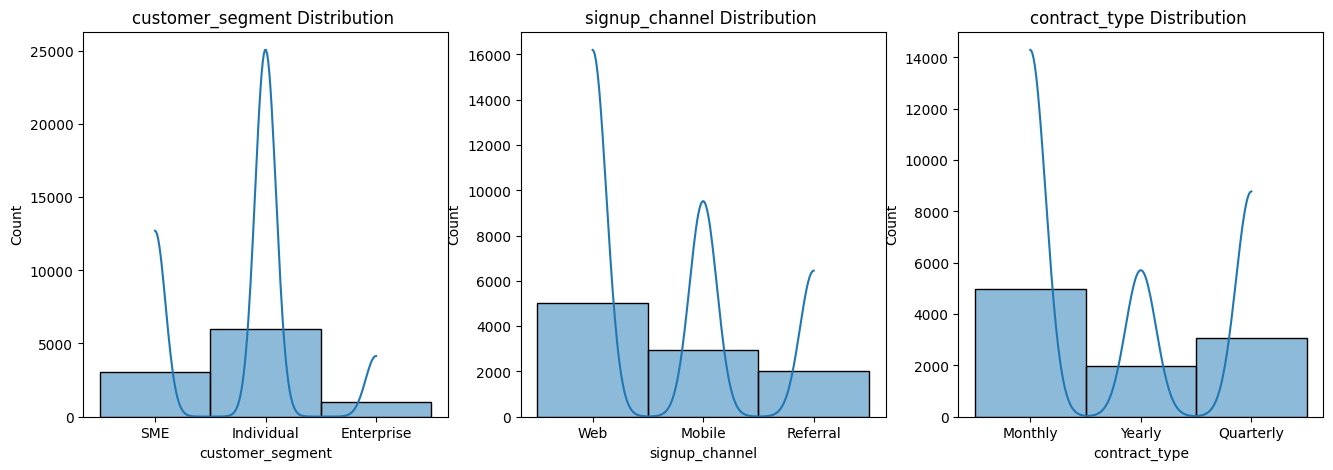


7 Distribution: payment_method
Card             5955
PayPal           2557
Bank Transfer    1488
Name: count, dtype: int64

8 Distribution: discount_applied
No     6950
Yes    3050
Name: count, dtype: int64

9 Distribution: price_increase_last_3m
No     8055
Yes    1945
Name: count, dtype: int64


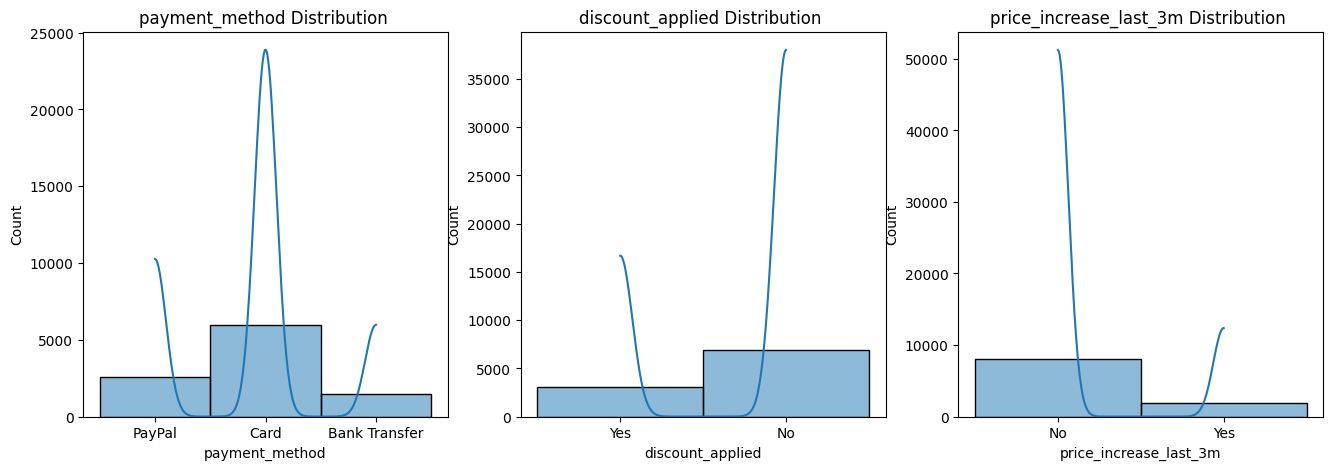


10 Distribution: complaint_type
Technical    5543
Billing      2427
Service      2030
Name: count, dtype: int64

11 Distribution: survey_response
Satisfied      4975
Neutral        2978
Unsatisfied    2047
Name: count, dtype: int64


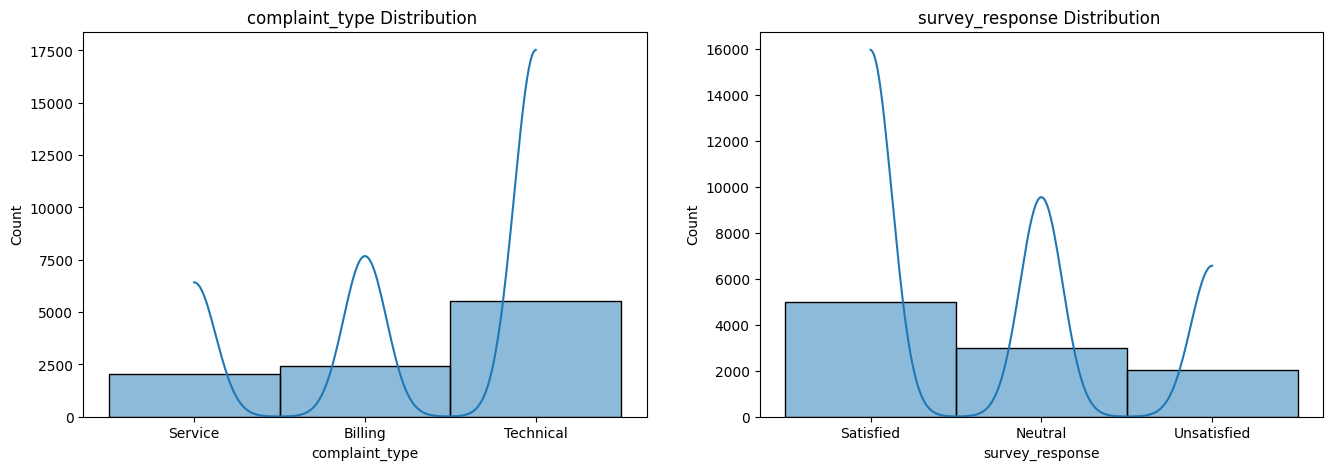

In [ ]:
# Distribution of All Categorical Columns

for i in range(0, len(categorical_cols), 3):
  if i < len(categorical_cols) -3:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
  else:
    fig, axes = plt.subplots(1, len(categorical_cols) -i, figsize=(16, 5))

  for j in range(0, 3):
    if i+j >= len(categorical_cols):
      break
    colName=categorical_cols[i+j]
    counts = df[colName].value_counts()
    print(f'\n{i+j+1} Distribution:', counts)

    # # Original Data
    if (i>= int(len(categorical_cols) / 3)*3 and len(categorical_cols) %3 == 1):
      axV=axes
    else:
      axV=axes[0+j]

   #   sns.countplot(x=colName, data=df, ax=axes[j])

    sns.histplot(df[colName], kde=True, ax=axV)
    axV.set_title(f"{colName} Distribution ") #(Skew: {df[colName].skew():.2f})

  plt.show()

In [ ]:
len(categorical_cols) % 3

2


 12. Distribution: referral_count
0    3704
1    3671
2    1841
3     613
4     134
5      29
6       7
7       1
Name: count, dtype: int64

 13 Distribution: escalations
0    7445
1    2216
2     296
3      39
4       4
Name: count, dtype: int64
Chart saved as 'referral_escalations_distribution.png'
Moved 'referral_escalations_distribution.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/referral_escalations_distribution.png' in your Google Drive.


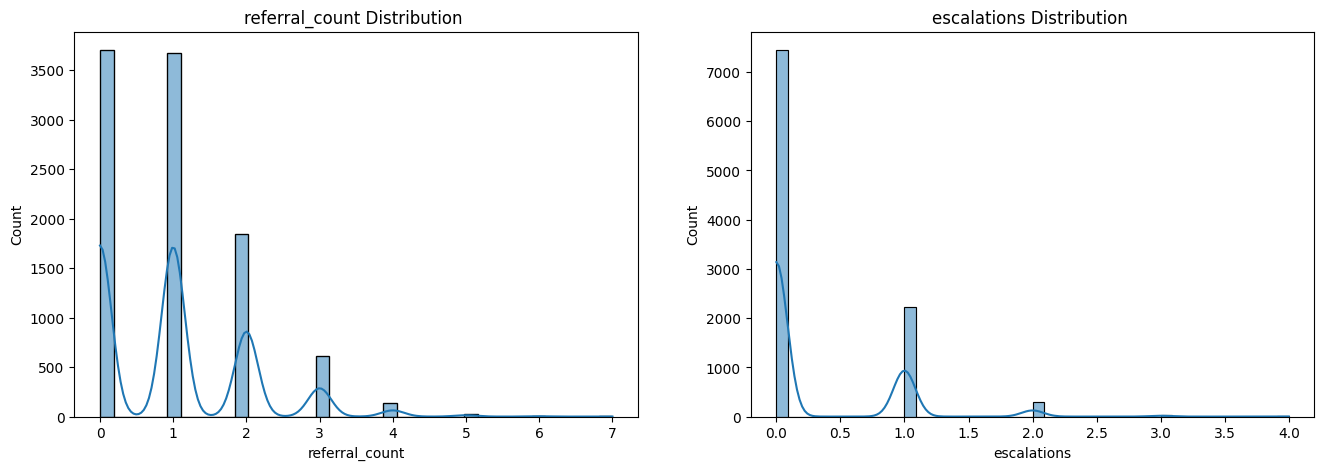

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colName='referral_count'
counts = df[colName].value_counts()
print(f'\n 12. Distribution:', counts)

sns.histplot(df[colName], kde=True, ax=axes[0])
axes[0].set_title(f"{colName} Distribution ")

colName='escalations'
counts = df[colName].value_counts()
print(f'\n 13 Distribution:', counts)

sns.histplot(df[colName], kde=True, ax=axes[1])
axes[1].set_title(f"{colName} Distribution ")

# Save the figure to an image file before displaying it
plt.savefig('referral_escalations_distribution.png', bbox_inches='tight', dpi=300)
print("Chart saved as 'referral_escalations_distribution.png'")
move_file_to_folder('referral_escalations_distribution.png', folder_visualization_output)

plt.show()



In [ ]:
#Create Tenure Bands

bins_tenure = [0, 12, 25, 37,df['tenure_months'].max() + 2]
labels_tenure = ['tenure_LT12M', 'tenure_13_24M', 'tenure_25_36M', 'tenure_37+']
df['tenure_band'] = pd.cut(df['tenure_months'], bins=bins_tenure, labels=labels_tenure, right=False)

print("Tenure Bands created successfully.")
print(df[['tenure_months', 'tenure_band']].head())
print(df['tenure_band'].value_counts())

Tenure Bands created successfully.
   tenure_months    tenure_band
0             22  tenure_13_24M
1              9   tenure_LT12M
2             58     tenure_37+
3             19  tenure_13_24M
4             52     tenure_37+
tenure_band
tenure_37+       3914
tenure_13_24M    2153
tenure_25_36M    2049
tenure_LT12M     1884
Name: count, dtype: int64


In [ ]:
#Create Age Bands
bins = [0, 18, 26, 36, 51, df['age'].max() + 1]
labels = ['genZalpha', 'genZ', 'Millennials', 'genX', 'boomers+']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print("Age Bands created successfully.")
print(df[['age', 'age_band']].head())


Age Bands created successfully.
   age  age_band
0   68  boomers+
1   57  boomers+
2   24      genZ
3   49      genX
4   65  boomers+



 14. Distribution:       age_band  count
0     boomers+   4157
1         genX   2636
2  Millennials   1838
3         genZ   1369
4    genZalpha      0
Table with Title age_band Distribution  saved as agebandDistribution.png
Moved 'agebandDistribution.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/agebandDistribution.png' in your Google Drive.


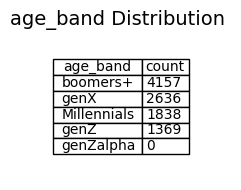


 15 Distribution:      tenure_band  count
0     tenure_37+   3914
1  tenure_13_24M   2153
2  tenure_25_36M   2049
3   tenure_LT12M   1884
Table with Title tenure_band Distribution  saved as tenurebandDistribution.png
Moved 'tenurebandDistribution.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/tenurebandDistribution.png' in your Google Drive.


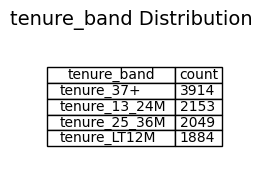

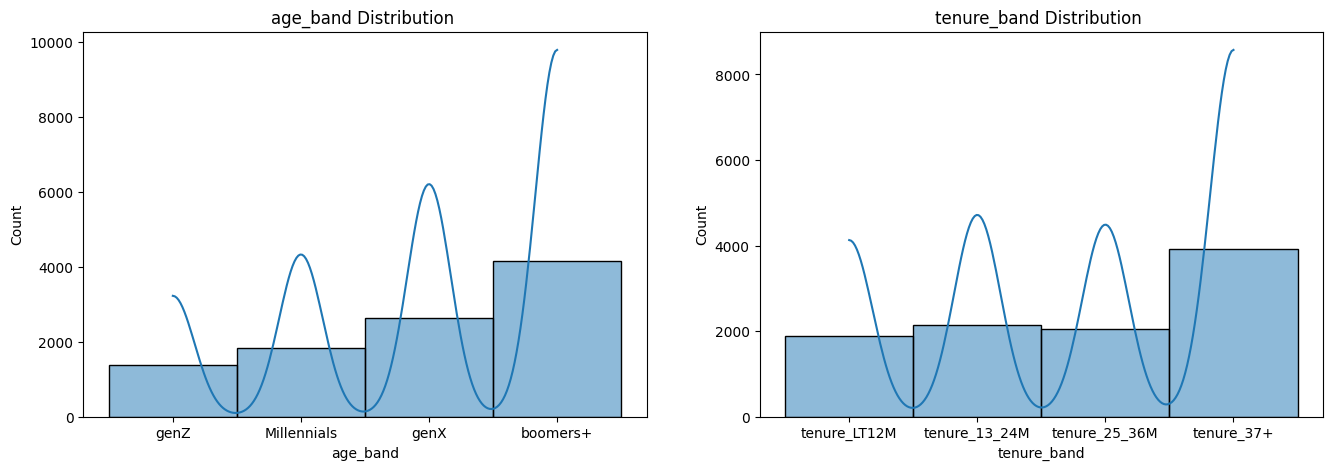

In [ ]:
# Show the Tabular Information as Image Files

colName='age_band'
age_counts = df[colName].value_counts().reset_index()
print(f'\n 14. Distribution:', age_counts)
tableToImage(age_counts,f"{colName} Distribution ",2,2, destination_folder=folder_visualization_output )

colName='tenure_band'
tenure_counts = df[colName].value_counts().reset_index()
print(f'\n 15 Distribution:', tenure_counts)
tableToImage(tenure_counts,f"{colName} Distribution ",2,2, destination_folder=folder_visualization_output )
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colName='age_band'
sns.histplot(df[colName], kde=True, ax=axes[0])
axes[0].set_title(f"{colName} Distribution ")

colName='tenure_band'
sns.histplot(df[colName], kde=True, ax=axes[1])
axes[1].set_title(f"{colName} Distribution ")

plt.show()

### Other Non-Churn Features Statistics

In [ ]:
df.isna().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
# Finding Outliers

Q1 = df["avg_session_time"].quantile(0.25)
Q3 = df["avg_session_time"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["avg_session_time"] < Q1 - 1.5*IQR) | (df["avg_session_time"] > Q3 + 1.5*IQR)]
print("No of outliers: ", len(outliers))
outliers

No of outliers:  27


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn,tenure_band,age_band
498,CUST_00499,Male,61,USA,Delhi,SME,58,Web,Monthly,21,...,2,0,0.48,0.43,71,Satisfied,1,1,tenure_37+,boomers+
632,CUST_00633,Male,71,USA,Toronto,Individual,29,Mobile,Monthly,21,...,3,0,0.61,0.19,66,Satisfied,1,0,tenure_25_36M,boomers+
733,CUST_00734,Female,40,Bangladesh,Toronto,Enterprise,56,Referral,Monthly,44,...,3,1,0.23,0.36,8,Satisfied,1,0,tenure_37+,genX
1020,CUST_01021,Male,19,Bangladesh,Sydney,Individual,59,Mobile,Monthly,0,...,3,0,0.47,0.07,-1,Satisfied,0,0,tenure_37+,genZ
1029,CUST_01030,Male,48,Germany,Dhaka,Individual,5,Referral,Monthly,34,...,5,2,0.78,0.20,49,Satisfied,3,0,tenure_LT12M,genX
1735,CUST_01736,Female,39,Germany,London,Individual,1,Web,Monthly,10,...,5,1,0.57,0.24,-19,Satisfied,2,0,tenure_LT12M,genX
1803,CUST_01804,Female,39,India,Toronto,Individual,33,Web,Monthly,1,...,3,0,0.77,0.01,40,Neutral,0,0,tenure_25_36M,genX
2019,CUST_02020,Female,32,USA,Toronto,SME,52,Web,Monthly,28,...,1,0,0.40,0.47,23,Satisfied,1,0,tenure_37+,Millennials
2585,CUST_02586,Female,68,USA,Toronto,Individual,19,Web,Quarterly,14,...,5,0,0.23,0.32,24,Neutral,0,0,tenure_13_24M,boomers+
2890,CUST_02891,Female,18,Australia,Delhi,Individual,35,Web,Monthly,19,...,3,0,0.42,0.15,44,Satisfied,0,0,tenure_25_36M,genZ


<Axes: xlabel='last_login_days_ago', ylabel='Count'>

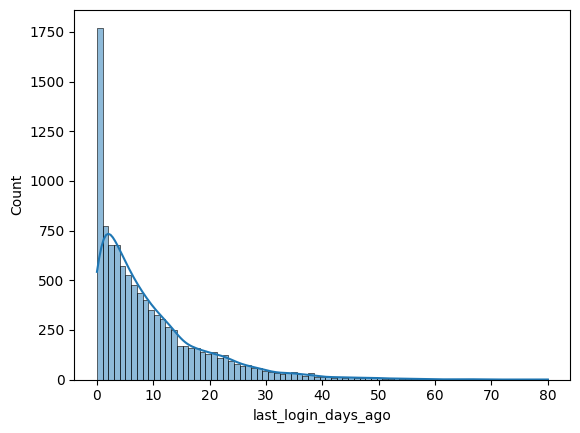

In [ ]:
# Histogram
sns.histplot(df["last_login_days_ago"], kde=True)

<Axes: xlabel='last_login_days_ago'>

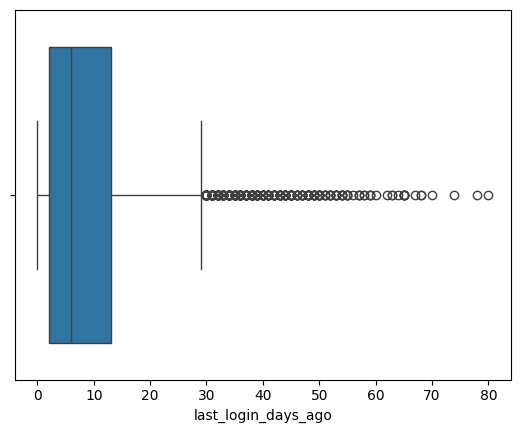

In [ ]:
#BoxPlot
sns.boxplot(x=df["last_login_days_ago"])


### Exploratory Data Analysis


			   --- 3. CORRELATION ANALYSIS ---  


			   Multivariate Analysis: Correlation Heatmap   



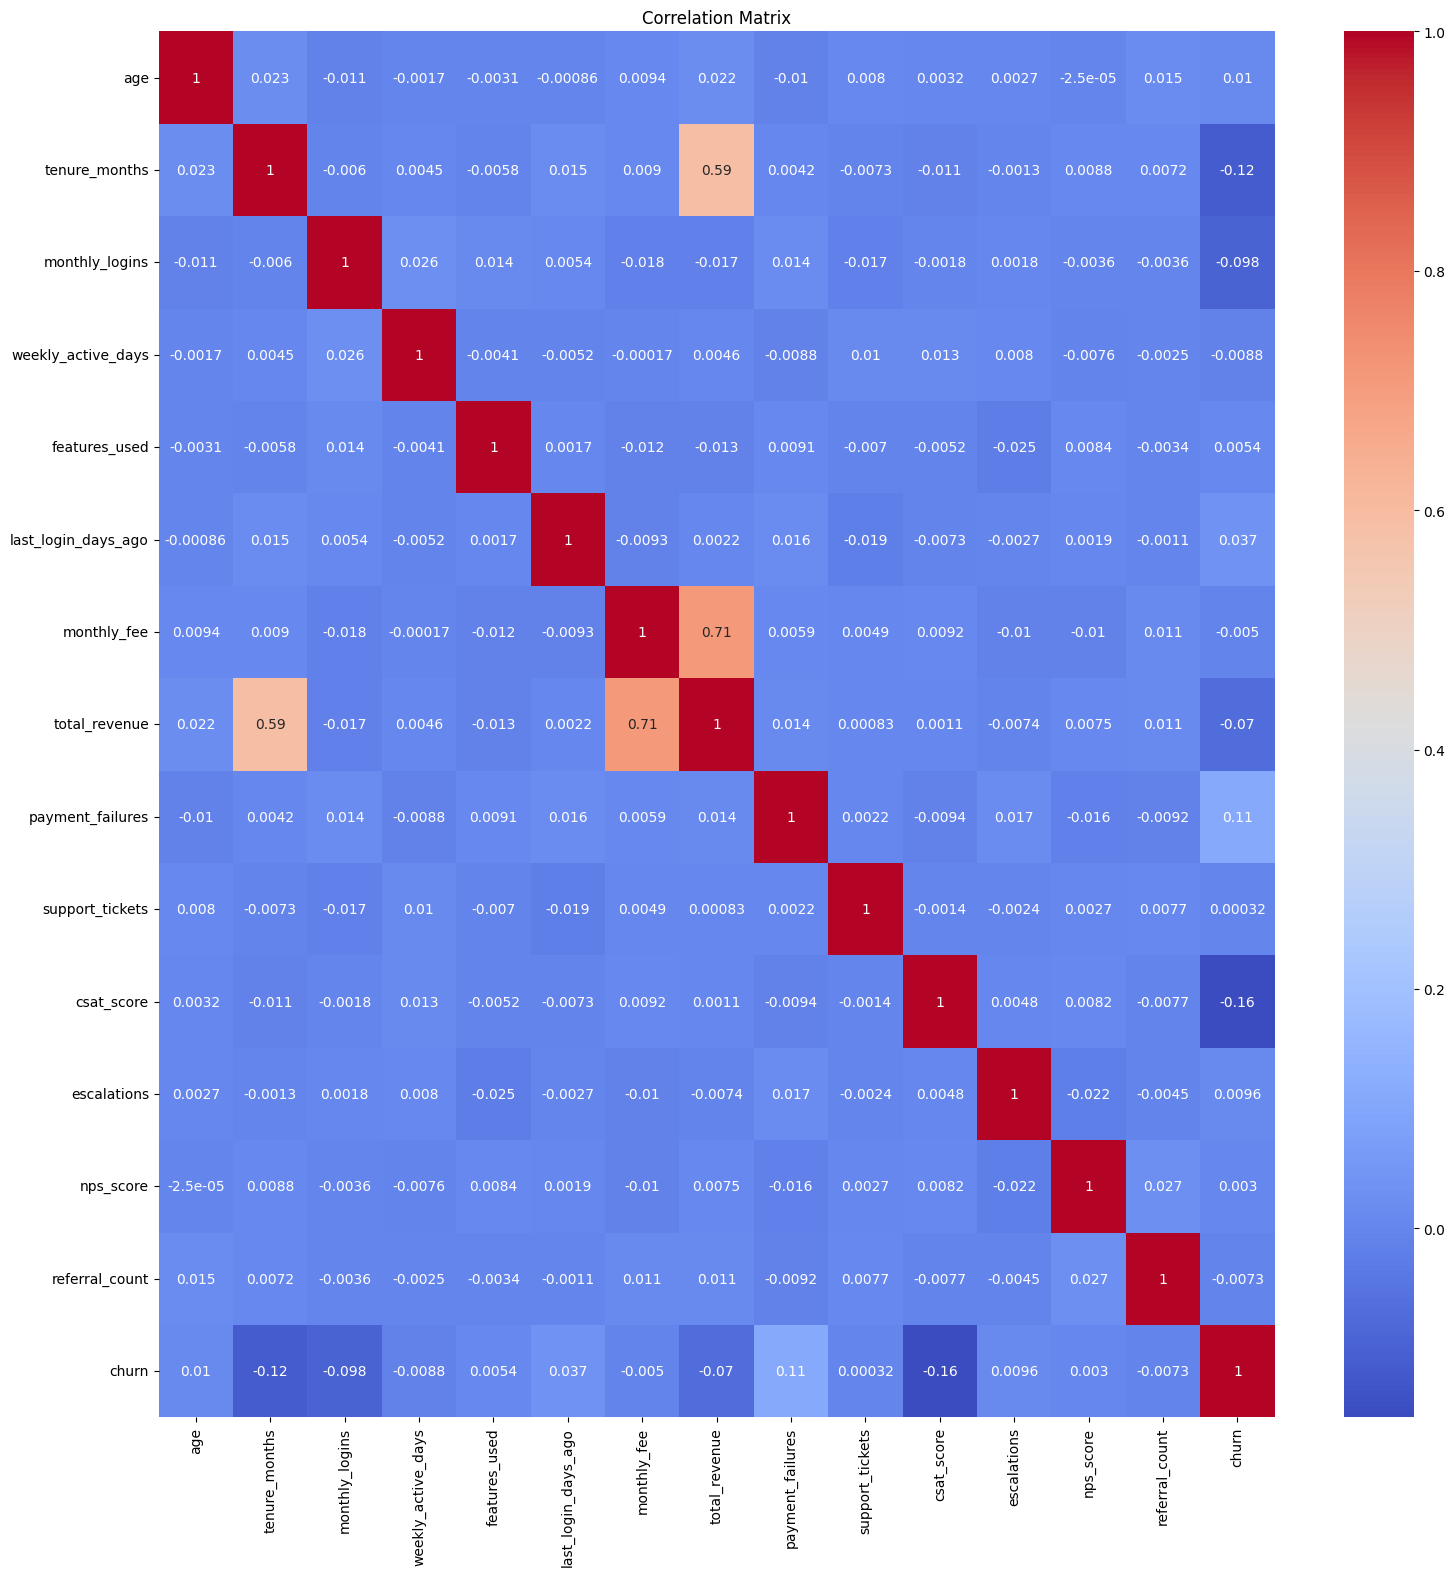

In [ ]:
print("\n\t\t\t  \033[1m --- 3. CORRELATION ANALYSIS --- \033[0m \n")

print("\n\t\t\t \033[4m \033[1m Multivariate Analysis: Correlation Heatmap \033[4m \033[0m \n")

# Multivariate: Correlation Heatmap
plt.figure(figsize=(18, 18))
dfV = df.drop(['avg_session_time', 'usage_growth_rate', 'avg_resolution_time', 'email_open_rate','marketing_click_rate'], axis=1)
sns.heatmap(dfV.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Correlation of numeric variables with the target (e.g., 'churn' in this case)
numeric_df = df.select_dtypes(include=['number', 'bool'])
correlations = numeric_df.corr()['churn'].sort_values(ascending=False)
print(correlations)

churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64


In [ ]:
# Identify features with correlation between -0.1 and 0.1
threshold = 0.1
weak_features = correlations[abs(correlations) < threshold].index.tolist()
print(correlations[weak_features])

print(f"Features to consider dropping: ({len(weak_features)}) {weak_features}")

last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.070120
monthly_logins         -0.098339
Name: churn, dtype: float64
Features to consider dropping: (16) ['last_login_days_ago', 'email_open_rate', 'age', 'escalations', 'features_used', 'usage_growth_rate', 'nps_score', 'support_tickets', 'marketing_click_rate', 'avg_session_time', 'monthly_fee', 'referral_count', 'weekly_active_days', 'avg_resolution_time', 'total_revenue', 'monthly_logins']


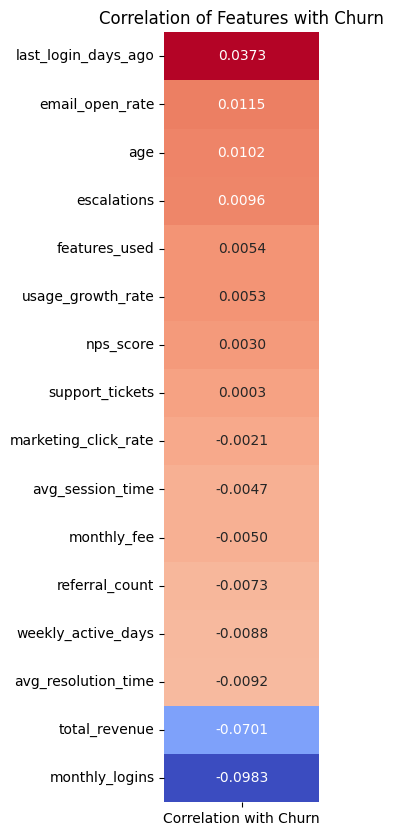

In [ ]:
#Visualize the Weak correlations with churn using a heatmap

correlations_df = correlations[weak_features].to_frame(name='Correlation with Churn')

plt.figure(figsize=(2, 10)) # Adjust size for a single column
sns.heatmap(correlations_df, annot=True, cmap='coolwarm', fmt=".4f", cbar=False)
plt.title('Correlation of Features with Churn')
plt.yticks(rotation=0)
plt.show()

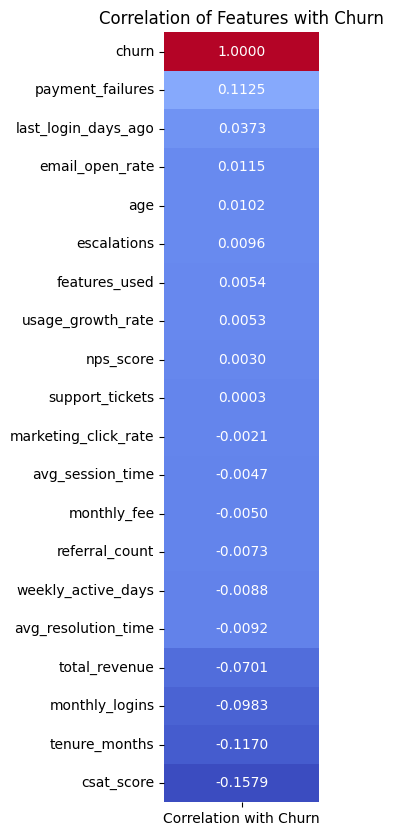

In [ ]:
#Visualize the correlations with churn using a heatmap

correlations_df = correlations.to_frame(name='Correlation with Churn')

plt.figure(figsize=(2, 10)) # Adjust size for a single column
sns.heatmap(correlations_df, annot=True, cmap='coolwarm', fmt=".4f", cbar=False)
plt.title('Correlation of Features with Churn')
plt.yticks(rotation=0)
plt.show()

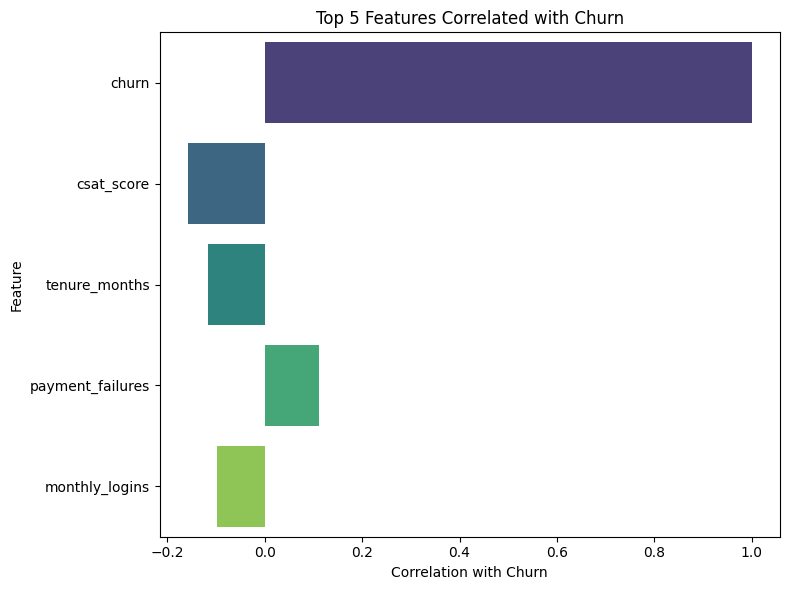

In [ ]:
# Get the top 5 features with the highest absolute correlation to 'churn'
top_5_correlated_features = correlations.abs().nlargest(5).index

# Filter the original correlations series for these top features
top_5_correlations = correlations[top_5_correlated_features]

plt.figure(figsize=(8, 6))
sns.barplot(x=top_5_correlations.values, y=top_5_correlations.index, hue=top_5_correlations.index, palette='viridis', legend=False)
plt.title('Top 5 Features Correlated with Churn')
plt.xlabel('Correlation with Churn')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


 Univariate Analysis



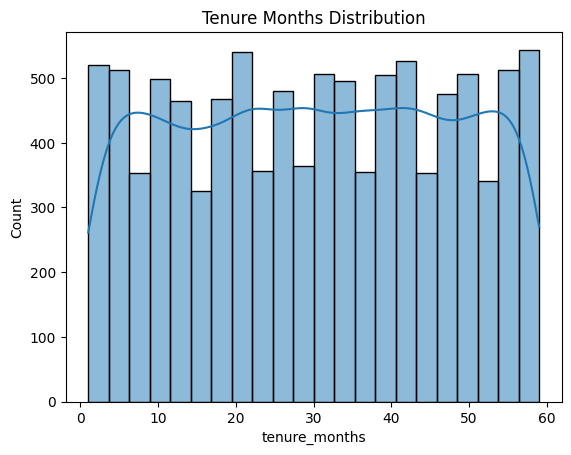

In [ ]:
#3. Univariate Analysis
print("\n Univariate Analysis\n")

# Visualize the distribution of Seats
sns.histplot(df['tenure_months'], kde=True)
plt.title('Tenure Months Distribution')
plt.show()


		  Bivariate Analysis: Customer segment vs Features Used  



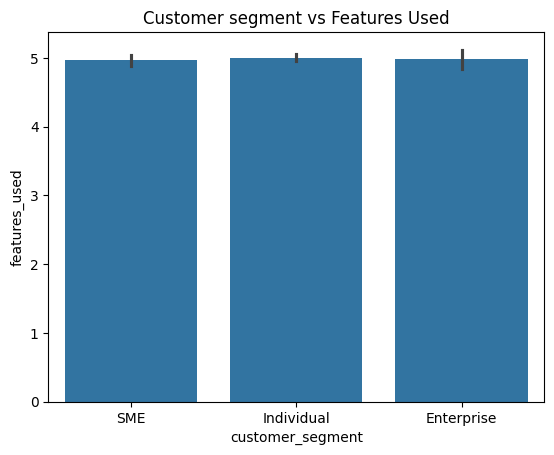

In [ ]:
#4. Bivariate & Multivariate Analysis

# Bivariate: Industry vs Seats
print("\n\t\t \033[1m Bivariate Analysis: Customer segment vs Features Used \033[0m \n")

sns.barplot(x='customer_segment', y='features_used', data=df)
plt.title('Customer segment vs Features Used')
plt.show()

In [ ]:
# #5. Outlier Detection

# # Detect outliers in 'fare'
# sns.boxplot(x=df['seats'])
# plt.title('Seats Outlier Detection')
# plt.show()

# numeric_df = df.select_dtypes(include=['number'])


# # 4. Outlier Detection (Boxplots for all numeric columns)
# print("\n--- 4. OUTLIER DETECTION ---")
# num_cols = numeric_df.columns
# print(num_cols)

# if len(num_cols) > 0:
#     fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 5))
#     # If there's only one numeric column, axes will be a single AxesSubplot object, not an array.
#     # Convert it to a list containing that single AxesSubplot to make it iterable for the loop.
#     if len(num_cols) == 1:
#         axes = [axes]

#     for i, col in enumerate(num_cols):
#         sns.boxplot(y=df[col], ax=axes[i])
#         axes[i].set_title(col)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No numeric columns found for outlier detection.")

# # 5. Target Variable Analysis (if provided)
# target_col = "churn_flag"
# if target_col and target_col in df.columns:
#     print(f"\n--- 5. TARGET ANALYSIS: {target_col} ---")
#     if df[target_col].nunique() <= 10: # Categorical Target
#         sns.countplot(x=target_col, data=df)
#     else: # Numerical Target
#         sns.histplot(df[target_col], kde=True)
#     plt.title(f"Distribution of {target_col}")
#     plt.show()

In [ ]:
#1. Outlier Treatment: The IQR Method

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['tenure_months'].quantile(0.25)
Q3 = df['tenure_months'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data to remove outliers
dfAccounts_cleaned = df[(df['tenure_months'] >= lower_bound) & (df['tenure_months'] <= upper_bound)]
print(lower_bound, upper_bound)
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df.shape}")



-27.5 88.5
Original shape: (10000, 34)
Cleaned shape: (10000, 34)


In [ ]:
# #2. Pair Plots: Finding Hidden Patterns

# # Select a subset of features for clarity
# features = ['csat_score', 'weekly_active_days', 'monthly_fee']

# # Create a pair plot colored by 'customer_segment'
# sns.pairplot(df, vars=features, hue='customer_segment', palette='viridis', diag_kind='kde')
# plt.show()


# Finalizing Data For Split

### Outliers

#### Finding Outliers

num_cols 20:
 Index(['age', 'tenure_months', 'monthly_logins', 'weekly_active_days',
       'avg_session_time', 'features_used', 'usage_growth_rate',
       'last_login_days_ago', 'monthly_fee', 'total_revenue',
       'payment_failures', 'support_tickets', 'avg_resolution_time',
       'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate',
       'nps_score', 'referral_count', 'churn'],
      dtype='object')

Outliers are < Q1 - 1.5*IQR or > Q3 + 1.5*IQR 


For monthly_logins : Q1 = 13.0, Q3 = 26.0, IQR = 13.0
Distinct Outliers in monthly_logins (7): [46, 50, 47, 51, 49, 48, 54]
(4) No of outliers in monthly_logins:  49
Table with Title monthly_logins Outliers saved as monthlyloginsOutliers.png
Moved 'monthlyloginsOutliers.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/monthlyloginsOutliers.png' in your Google Drive.


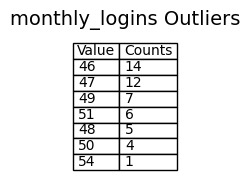



For monthly_fee : Q1 = 20.0, Q3 = 50.0, IQR = 30.0
Distinct Outliers in monthly_fee (1): [100]
(15) No of outliers in monthly_fee:  513
Table with Title monthly_fee Outliers saved as monthlyfeeOutliers.png
Moved 'monthlyfeeOutliers.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/monthlyfeeOutliers.png' in your Google Drive.


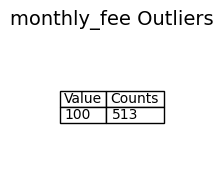



For referral_count : Q1 = 0.0, Q3 = 2.0, IQR = 2.0
Distinct Outliers in referral_count (2): [6, 7]
(33) No of outliers in referral_count:  8
Table with Title referral_count Outliers saved as referralcountOutliers.png
Moved 'referralcountOutliers.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/referralcountOutliers.png' in your Google Drive.


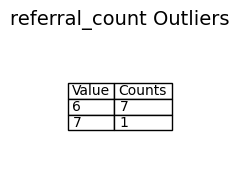

In [ ]:
import pandas as pd
dfOutliers = pd.DataFrame(columns=['Features', 'Outlier Count'])

# Finding Outliers
num_cols = df.select_dtypes(include=['number']).columns
print(f"num_cols {len(num_cols)}:\n" , num_cols)
i=0
no_outliers=[]
prev_outliers=False
print("\nOutliers are < Q1 - 1.5*IQR or > Q3 + 1.5*IQR ")
for col in num_cols:
  # print(col)
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
  i+=1
  if i >= 1:
      exit
  # print(type(outliers),outliers)
  if len(outliers) > 0:
    i+=1
    # print(outliers)
    prev_outliers=False
    # Adding a row at the next available index
    dfOutliers.loc[len(dfOutliers)] = [col, len(outliers)]
    # if i >= 1:
    #   exit
    if col in ['monthly_fee', 'referral_count', 'monthly_logins'] : #
      print(f"\n\nFor {col} : Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
      print(f"Distinct Outliers in {col} ({len(outliers[col].unique())}):", outliers[col].unique().tolist())
      print(f"({i}) No of outliers in {col}: ", len(outliers))

      counts = df[col].value_counts()
      # print(type(counts), counts.shape)
      # print(f'Summary of Counts in {col} : \n', counts)
      df_tmp = counts.reset_index()
      df_tmp.columns = ["Value", 'Counts']
      tableToImage(df_tmp.tail(len(outliers[col].unique())),f"{col} Outliers",1,2, destination_folder=folder_visualization_output )
      # # outliers.value_counts().plot(kind='bar')
      # plt.title(f"Outliers in {col}")
      # plt.show()
      # outliers[col].count().plot(kind='bar')
      # plt.title(f"Outliers in {col}")
      # plt.show()
        # exit

  else:
      no_outliers.append(col)
      # if prev_outliers:
    #   print(f" , {col}", end ="")
    # else:
    #   print(f"\nNo outliers in {col}", end ="")
    #   prev_outliers=True


# print(f"Features with no outlier: {len(no_outliers)} : {no_outliers}")
# leftOut=leftoverAminusB(num_cols,no_outliers)
# print(f"Features with outliers: {len(leftOut)} : {leftOut}")


               Features  Outlier Count
14                churn           1021
5           monthly_fee            513
6         total_revenue            513
4   last_login_days_ago            471
10           csat_score            221
7      payment_failures            147
2         features_used            121
3     usage_growth_rate             78
0        monthly_logins             49
11          escalations             43
9   avg_resolution_time             38
12            nps_score             36
1      avg_session_time             27
8       support_tickets             18
13       referral_count              8


,Features,Outlier Count
14,churn,1021
5,monthly_fee,513
6,total_revenue,513
4,last_login_days_ago,471
10,csat_score,221
7,payment_failures,147
2,features_used,121
3,usage_growth_rate,78
0,monthly_logins,49
11,escalations,43


Table with Title Features Outliers Count saved as FeaturesOutliersCount.png
Moved 'FeaturesOutliersCount.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/FeaturesOutliersCount.png' in your Google Drive.


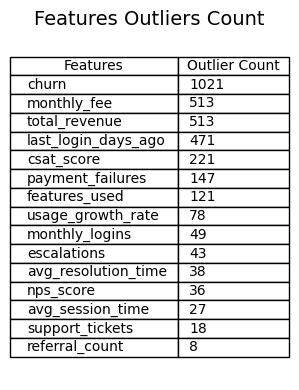

['churn', 'monthly_fee', 'total_revenue', 'last_login_days_ago', 'csat_score']

In [ ]:
dfOutliers = dfOutliers.sort_values(by='Outlier Count', ascending=False)
type(dfOutliers)
print(dfOutliers)
display(dfOutliers)
tableToImage(dfOutliers,"Features Outliers Count",2,4)
dfOutliers.head(6)['Features'].to_list()

In [ ]:
dfOutliers

In [ ]:
# Visualize, using boxplot, the top, bottom-ranked features
top_feature = dfOutliers.iloc[1]['Features']
bottom_feature = dfOutliers.iloc[len(dfOutliers)-1]['Features']
print(top_feature)
print(bottom_feature)
list_tmp=[top_feature, bottom_feature,'monthly_logins']
# for l in list_tmp:
#   plt.figure(figsize=(8, 5))
#   sns.boxplot(data=df, x=df[l])
#   plt.title(f"Boxplot of {l}")
# plt.show()

# BoxPlot of All DEsignated Columns

for i in range(0, len(list_tmp), 3):
  if i < len(list_tmp) -3:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
  else:
    fig, axes = plt.subplots(1, len(list_tmp) -i, figsize=(16, 5))

  for j in range(0, 3):
    if i+j >= len(list_tmp):
      break
    colName=list_tmp[i+j]
    counts = df[colName].value_counts()
    print(f'\n{i+j+1} Distribution:', counts)

    # # Original Data
    if (i>= int(len(list_tmp) / 3)*3 and len(list_tmp) %3 == 1):
      axV=axes
    else:
      axV=axes[0+j]

   #   sns.countplot(x=colName, data=df, ax=axes[j])
    sns.boxplot(data=df, x=df[colName], ax=axV)
    plt.title(f"Boxplot of {colName}")
    # sns.histplot(df[colName], kde=True, ax=axV)
    axV.set_title(f"Boxplot of {colName}") #(Skew: {df[colName].skew():.2f})

  plt.show()

#### Treating Outliers

1. Trimming (Deletion)
The simplest approach: remove the rows containing outliers. Use this only if you are certain the outliers are errors (e.g., a "Height" of 12 feet) or if you have a massive dataset where losing 1% won't matter.


In [ ]:
# Removing values outside the 1st and 99th percentile
list_outlier= []  #['monthly_fee', 'total_revenue', 'last_login_days_ago', 'csat_score']
for l in list_outlier:
  q_low = df[l].quantile(0.01)
  q_hi  = df[l].quantile(0.99)

  df_outlier_deleted = df[(df[l] < q_hi) & (df[l] > q_low)]

2. Capping / Winsorization

Instead of deleting data, you "squash" the outliers. Any value above the 95th percentile is set to the 95th percentile value. This keeps the data point but limits its "pull" on the model.

In [ ]:
# # Using pandas to cap (clip) values
list_outlier= []  #['monthly_fee', 'total_revenue', 'last_login_days_ago', 'csat_score']
for l in list_outlier:
  upper_limit = df[l].quantile(0.95)
  lower_limit = df[l].quantile(0.05)

  df[l] = df[l].clip(lower=lower_limit, upper=upper_limit)

3. Transformation (Log Scaling)

If your data is "heavy-tailed" (lots of small values, a few massive ones like Income), a Log Transformation can pull the outliers closer to the center by changing the scale of the data.

In [ ]:
list_outlier=[] #['monthly_fee', 'total_revenue', 'last_login_days_ago', 'csat_score']
for l in list_outlier:
  # # Log transform handles exponential growth/outliers well
  df[l+'_log'] = np.log1p(df[l]) # log1p handles zeros safely

4. Imputation

Treat the outlier like a missing value (NaN). Delete the extreme value and replace it with the Median (more robust than the Mean).

In [ ]:
# Fill missing 'monthly_fee' values with the most frequent
list_outlier= []  #['monthly_fee', 'total_revenue', 'last_login_days_ago', 'csat_score']
for l in list_outlier:

  imputer_referral = SimpleImputer(strategy='most_frequent')
  df[l+'_frequent'] = imputer_referral.fit_transform(df[[l]]).ravel()

  # Cannot substitute non-numeric with median
  # Fill missing 'column' values with the median

  imputer_seats = SimpleImputer(strategy='median')
  df[l+'_median'] = imputer_seats.fit_transform(df[[l]])
  # OR use the following
  df[l+'_median'] = df[l].fillna(df[l].median())


# Drop columns with too many missing values or irrelevant info or with high-cardinality or redundant columns
#df.drop(columns=['col1', 'col2'], inplace=True)

### Skewness

#### Identifying Skewness

In [ ]:
# Check numerical skewness
skew_values = df.skew(numeric_only=True)
print(skew_values)

In [ ]:
filtered_skew_values_M = skew_values[
    ((skew_values >= 0.5) & (skew_values <= 1.0)) |
    ((skew_values >= -1.0) & (skew_values <= -0.5))
]

print("Columns with Moderate Skewness\n",round(filtered_skew_values_M,2))

filtered_skew_values_H = skew_values[
    ((skew_values > 1.0) | (skew_values < -1.0) )
]

print("\nColumns with High Skewness\n",round(filtered_skew_values_H,2))

Columns with Moderate Skewness
 support_tickets    0.92
dtype: float64

Columns with High Skewness
 last_login_days_ago    1.85
monthly_fee            1.12
total_revenue          1.72
payment_failures       1.42
escalations            1.89
referral_count         1.00
churn                  2.63
dtype: float64


DataFrame for High Skewness:


,Features,Skewness
0,last_login_days_ago,1.850082
1,monthly_fee,1.118918
2,total_revenue,1.723005
3,payment_failures,1.423564
4,escalations,1.894925
5,referral_count,1.002237
6,churn,2.628707


Summary of Datafrme df_high_skewness : Shape:  (7, 2)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['Features', 'Skewness']


In [ ]:
# Code to create the DataFrame for High Skewness
df_high_skewness = filtered_skew_values_H.reset_index()
df_high_skewness.columns = ['Features', 'Skewness']

print("DataFrame for High Skewness:")
display(df_high_skewness)
displayDFsummary(df_high_skewness, 'df_high_skewness')

DataFrame for High Skewness:


,Features,Skewness
0,last_login_days_ago,1.850082
1,monthly_fee,1.118918
2,total_revenue,1.723005
3,payment_failures,1.423564
4,escalations,1.894925
5,referral_count,1.002237
6,churn,2.628707


Summary of Datafrme df_high_skewness : Shape:  (7, 2)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['Features', 'Skewness']


In [ ]:
print(df_high_skewness['Features']) # Correct way to access the 'Features' column

0    last_login_days_ago
1            monthly_fee
2          total_revenue
3       payment_failures
4            escalations
5         referral_count
6                  churn
Name: Features, dtype: object


####  Removing Skewness

In [ ]:
df_skew_tmp = pd.DataFrame()
feature_skewness_considered = df_high_skewness['Features'].to_list()
feature_skewness_considered


In [ ]:
list_skew_log=[]
list_skew_boxcox=[]
for l in feature_skewness_considered:
  print(l)
  df_skew_tmp[l+'_log'] = np.log1p(df[l]) # log1p handles log(0) by adding 1 automatically
  df_skew_tmp[l+'_boxcox'], _ = stats.boxcox(df[l] + 1) ## Box-Cox: Requires data to be strictly positive (\(>0\)).

  print(f"Skewness of Original            {l} : {df[l].skew():.2f}")
  print(f"Skewness of Log Transformed     {l}: {df_skew_tmp[l+'_log'].skew():.2f})")
  print(f"Skewness of Boxcox Transformed  {l}: {df_skew_tmp[l+'_boxcox'].skew():.2f})\n")

  list_skew_log.append(df_skew_tmp[l+'_log'].skew())
  list_skew_boxcox.append(df_skew_tmp[l+'_boxcox'].skew())


last_login_days_ago
Skewness of Original            last_login_days_ago : 1.85
Skewness of Log Transformed     last_login_days_ago: -0.29)
Skewness of Boxcox Transformed  last_login_days_ago: -0.03)

monthly_fee
Skewness of Original            monthly_fee : 1.12
Skewness of Log Transformed     monthly_fee: 0.05)
Skewness of Boxcox Transformed  monthly_fee: 0.01)

total_revenue
Skewness of Original            total_revenue : 1.72
Skewness of Log Transformed     total_revenue: -0.72)
Skewness of Boxcox Transformed  total_revenue: -0.03)

payment_failures
Skewness of Original            payment_failures : 1.42
Skewness of Log Transformed     payment_failures: 0.80)
Skewness of Boxcox Transformed  payment_failures: 0.49)

escalations
Skewness of Original            escalations : 1.89
Skewness of Log Transformed     escalations: 1.37)
Skewness of Boxcox Transformed  escalations: 1.12)

referral_count
Skewness of Original            referral_count : 1.00
Skewness of Log Transformed     refer

In [ ]:
df_skew.head()

,last_login_days_ago_log,last_login_days_ago_boxcox,monthly_fee_log,monthly_fee_boxcox,total_revenue_log,total_revenue_boxcox,payment_failures_log,payment_failures_boxcox,escalations_log,escalations_boxcox,referral_count_log,referral_count_boxcox,churn_log,churn_boxcox
0,2.079442,2.393246,3.433987,3.214892,6.493754,14.556866,0.693147,0.393608,0.000000,0.000000,0.693147,0.654911,0.000000,0.000000
1,1.098612,1.182370,3.433987,3.214892,5.602119,11.130483,0.693147,0.393608,0.000000,0.000000,1.098612,1.004629,0.693147,0.070805
2,3.178054,3.949581,3.044522,2.871454,7.057037,17.098926,1.098612,0.474678,0.000000,0.000000,0.693147,0.654911,0.000000,0.000000
3,3.218876,4.011879,3.433987,3.214892,6.347389,13.946807,0.000000,0.000000,0.693147,0.210189,0.000000,0.000000,0.000000,0.000000
4,1.098612,1.182370,3.931826,3.646401,7.863651,21.340781,0.000000,0.000000,0.000000,0.000000,0.693147,0.654911,0.000000,0.000000


/content/my_utils.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  if image_file is None:


Table with Title Skewness After Transformation saved as SkewnessAfterTransformation.png
Moved 'SkewnessAfterTransformation.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/SkewnessAfterTransformation.png' in your Google Drive.


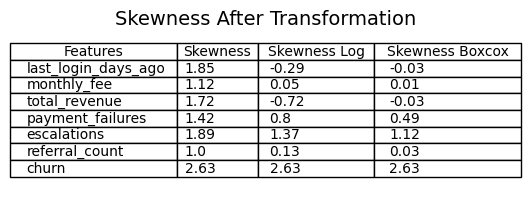

In [ ]:
df_high_skewness['Skewness Log']= list_skew_log
df_high_skewness['Skewness Boxcox']= list_skew_boxcox
tableToImage(df_high_skewness,"Skewness After Transformation",2,2,2)

In [ ]:
# @2. Common Transformation Techniques
# For removing Skewness

# @A. Log Transformation (For Right Skew)
# This is the most popular method for handling positive skew.


# It shrinks the right tail significantly. Formula: \(y=\ln (x)\) or \(y=\ln (x+1)\) (if the data contains zeros)
# Apply Log Transformation
df['escalations_log'] = np.log1p(df['escalations']) # log1p handles log(0) by adding 1 automatically

In [ ]:
# B. Square Root Transformation (Moderate Right Skew) Slightly weaker than Log, useful for data with counts or smaller ranges.
# Formula: \(y=\sqrt{x}\)

# C. Box-Cox & Yeo-Johnson (The "Pro" Way) These are power transformations that automatically find the best "lambda" (\(\lambda \)) to make the data as normal as possible.
# Box-Cox: Requires data to be strictly positive (\(>0\)).
# Yeo-Johnson: Works for both positive and negative data.


# Apply Box-Cox (data must be > 0)
df['escalations_boxcox'], _ = stats.boxcox(df['escalations'] + 1)


In [ ]:
# 3. Comparing Before and After
# It is vital to visualize the results to ensure the transformation actually worked.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# # Original Data
sns.histplot(df['escalations'], kde=True, ax=axes[0])
axes[0].set_title(f"Original escalations (Skew: {df['escalations'].skew():.2f})")

# # Transformed Data
sns.histplot(df['escalations_log'], kde=True, ax=axes[1], color='green')
axes[1].set_title(f"Log Transformed escalations (Skew: {df['escalations_log'].skew():.2f})")

# # Transformed Data
sns.histplot(df['escalations_boxcox'], kde=True, ax=axes[2], color='red')
axes[2].set_title(f"Boxcox Transformed escalations (Skew: {df['escalations_boxcox'].skew():.2f})")

plt.show()

### Scaler : Standard, Min-Max and Robust

#### Identify Columns for Scaling

In [ ]:
# Identification using range as threshhold
# 1. Identify numerical columns
num_cols = df.select_dtypes(include=['number']).columns

# 2. Calculate the range (Max - Min) for each column
ranges = df[num_cols].max() - df[num_cols].min()
# print(type(ranges), ranges.shape)
# print(ranges )

# 3. Filter columns where the range is significantly large (e.g., > 10)
# or where the ratio between the largest and smallest range is high
needs_scaling = ranges[ranges > 10].index.tolist()


print(f"Columns that likely need scaling i.e. with range > 10: {len(needs_scaling)}", needs_scaling)
# print("\nSummary Statistics:\n", df[num_cols].describe().T[['min', 'max', 'mean']])

Columns that likely need scaling i.e. with range > 10: 10 ['age', 'tenure_months', 'monthly_logins', 'avg_session_time', 'features_used', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'avg_resolution_time', 'nps_score']


Using the Ratio of Ranges is a more sophisticated way to identify scaling needs because it doesn't rely on an arbitrary number like "10." Instead, it looks at how much larger one feature's spread is compared to the "tightest" feature in your dataset.

In [ ]:
df


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn,tenure_band,age_band
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,4,0,0.71,0.40,27,Satisfied,1,0,tenure_13_24M,boomers+
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,2,0,0.78,0.33,-19,Neutral,2,1,tenure_LT12M,boomers+
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,3,0,0.35,0.49,80,Neutral,1,0,tenure_37+,genZ
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,5,1,0.83,0.15,100,Neutral,0,0,tenure_13_24M,genX
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,4,0,0.65,0.44,21,Unsatisfied,1,0,tenure_37+,boomers+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST_09996,Female,67,Germany,Sydney,SME,37,Web,Yearly,15,...,4,1,0.36,0.28,20,Satisfied,2,0,tenure_37+,boomers+
9996,CUST_09997,Male,26,USA,Toronto,Individual,42,Mobile,Yearly,13,...,4,0,0.48,0.06,28,Unsatisfied,2,0,tenure_37+,Millennials
9997,CUST_09998,Female,18,Canada,Sydney,Individual,39,Mobile,Yearly,15,...,1,0,0.11,0.07,-30,Satisfied,1,0,tenure_37+,genZ
9998,CUST_09999,Female,30,USA,Delhi,Individual,52,Web,Monthly,14,...,2,0,0.25,0.31,58,Neutral,1,1,tenure_37+,Millennials


In [ ]:
# Using the Ratio of Ranges

# 1. Get only numerical columns
num_cols = df.select_dtypes(include=['number'])

# 2. Calculate the range (Max - Min) for every column
col_ranges = num_cols.max() - num_cols.min()
# print(type(col_ranges), col_ranges.shape)
# print(col_ranges)

# 3. Find the smallest non-zero range to use as a baseline
# (We avoid zero to prevent division by zero errors)
baseline_range = col_ranges[col_ranges > 0].min()

# 4. Calculate the ratio of each column's range to the baseline
ratios = col_ranges / baseline_range

# 5. Flag columns where the ratio is > 5 (meaning it's 5x wider than the baseline)
needs_scaling = ratios[ratios > 5].index.tolist()

print(f"Baseline Range (Smallest): {baseline_range:.4f}")
print(f"\nColumns recommended for scaling, Based on  Ratio of Ranges Criterion i.e. max_range / min_range > 5 ({len(needs_scaling)} Columns): \n {needs_scaling}")

print("\nTop 5 Column Ratios:")
print(ratios.sort_values(ascending=False).head())


Baseline Range (Smallest): 0.4900

Columns recommended for scaling, Based on  Ratio of Ranges Criterion i.e. max_range / min_range > 5 (16 Columns): 
 ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'nps_score', 'referral_count']

Top 5 Column Ratios:
total_revenue          12020.408163
nps_score                408.163265
monthly_fee              183.673469
last_login_days_ago      163.265306
avg_resolution_time      124.126283
dtype: float64


In [ ]:
ratios

,0
age,114.285714
tenure_months,118.367347
monthly_logins,110.204082
weekly_active_days,14.285714
avg_session_time,83.666145
features_used,28.571429
usage_growth_rate,2.285714
last_login_days_ago,163.265306
monthly_fee,183.673469
total_revenue,12020.408163


In [ ]:
df_needs_scaling = ratios[needs_scaling].sort_values(ascending=False).reset_index()
df_needs_scaling.columns = ['Features', 'Ratio']

print("Features Recommended for Scaling (Sorted by Ratio):")
display(df_needs_scaling)
displayDFsummary(df_needs_scaling, 'df_needs_scaling')

Features Recommended for Scaling (Sorted by Ratio):


,Features,Ratio
0,total_revenue,12020.408163
1,nps_score,408.163265
2,monthly_fee,183.673469
3,last_login_days_ago,163.265306
4,avg_resolution_time,124.126283
5,tenure_months,118.367347
6,age,114.285714
7,monthly_logins,110.204082
8,avg_session_time,83.666145
9,features_used,28.571429


Summary of Datafrme df_needs_scaling : Shape:  (16, 2)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['Features', 'Ratio']


In [ ]:
df_needs_scaling.head()


,Features,Ratio
0,total_revenue,12020.408163
1,nps_score,408.163265
2,monthly_fee,183.673469
3,last_login_days_ago,163.265306
4,avg_resolution_time,124.126283


In [ ]:
num_cols

,total_revenue_standard,total_revenue_minmax,total_revenue_robust,nps_score_standard,nps_score_minmax,nps_score_robust,monthly_fee_standard,monthly_fee_minmax,monthly_fee_robust,last_login_days_ago_standard,last_login_days_ago_minmax,last_login_days_ago_robust,avg_resolution_time_standard,avg_resolution_time_minmax,avg_resolution_time_robust
0,-0.389196,0.110357,-0.054545,0.202634,0.635,0.150943,-0.207283,0.222222,0.000000,-0.255661,0.0875,0.090909,-1.064516,0.203124,-0.774769
1,-0.771513,0.044143,-0.409091,-0.978832,0.405,-0.716981,-0.207283,0.222222,0.000000,-0.765921,0.0250,-0.363636,0.119206,0.396898,0.086985
2,0.100953,0.195246,0.400000,1.563889,0.900,1.150943,-0.627735,0.111111,-0.333333,1.377171,0.2875,1.545455,0.363553,0.436898,0.264870
3,-0.477423,0.095076,-0.136364,2.077570,1.000,1.528302,-0.207283,0.222222,0.000000,1.479223,0.3000,1.636364,0.247839,0.417955,0.180630
4,1.512583,0.439728,1.709091,0.048530,0.605,0.037736,0.633621,0.444444,0.666667,-0.765921,0.0250,-0.363636,0.273326,0.422127,0.199185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.310772,0.123939,0.018182,0.022846,0.600,0.018868,-0.627735,0.111111,-0.333333,-0.663869,0.0375,-0.272727,1.033191,0.546517,0.752369
9996,1.022434,0.354839,1.254545,0.228318,0.640,0.169811,0.633621,0.444444,0.666667,-0.561817,0.0500,-0.181818,1.620939,0.642731,1.180252
9997,-0.271560,0.130730,0.054545,-1.261356,0.350,-0.924528,-0.627735,0.111111,-0.333333,-0.255661,0.0875,0.090909,0.126812,0.398143,0.092522
9998,0.493073,0.263158,0.763636,0.998840,0.790,0.735849,-0.207283,0.222222,0.000000,0.050495,0.1250,0.363636,-0.342318,0.321347,-0.249007


In [ ]:
# Identify columns for scaling where the standard deviation is 5x the average standard deviation of the dataset
num_cols = df.select_dtypes(include=['number'])
threshold = num_cols.std().mean() * 5

# Corrected: Get the names of the columns that satisfy the condition
needs_scaling = num_cols.columns[num_cols.std() > threshold].tolist()

print(f"Columns that likely need scaling i.e. standard deviation is 5x the average standard deviation of the dataset: ({len(needs_scaling)})\n", needs_scaling)

Columns that likely need scaling i.e. standard deviation is 5x the average standard deviation of the dataset: (1)
 ['total_revenue']


#### Apply Various Scalings

In [ ]:
df_scaling_tmp = pd.DataFrame()
feature_scaling_considered = df_needs_scaling.head()['Features'].to_list()
feature_scaling_considered


['total_revenue',
 'nps_score',
 'monthly_fee',
 'last_login_days_ago',
 'avg_resolution_time']

In [ ]:
df_scaling_tmp.head()

""


In [ ]:
new_scaled_col_names = []
for l in feature_scaling_considered:
  new_scaled_col_names.append(f'{l}_standard')
  new_scaled_col_names.append(f'{l}_minmax')
  new_scaled_col_names.append(f'{l}_robust')
new_scaled_col_names


NameError: name 'feature_scaling_considered' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

scaler = StandardScaler()
min_max = MinMaxScaler()
robust = RobustScaler()

list_StandardScaler=[]
list_MinMaxScaler=[]
list_RobustScaler=[]

df_scaling_tmp = pd.DataFrame(index=df.index)   #new_scaled_col_names
# df_scaling_tmp = df_scaling_tmp.T

for l in feature_scaling_considered:
  print(l)
  df_scaling_tmp[l+'_standard'] = scaler.fit_transform(df[[l]])
  df_scaling_tmp[l+'_minmax'] = min_max.fit_transform(df[[l]])
  df_scaling_tmp[l+'_robust'] = robust.fit_transform(df[[l]])

  # print(f"Skewness of Original            {l} : {df[l].skew():.2f}")
  # print(f"Skewness of Log Transformed     {l}: {df_skew_tmp[l+'_log'].skew():.2f})")
  # print(f"Skewness of Boxcox Transformed  {l}: {df_skew_tmp[l+'_boxcox'].skew():.2f})\n")

  # list_skew_log.append(df_skew_tmp[l+'_log'].skew())
  # list_skew_boxcox.append(df_skew_tmp[l+'_boxcox'].skew())

print(df_scaling_tmp.shape)
df_scaling_tmp.head()

In [ ]:
# Using the Ratio of Ranges

# 1. Get only numerical columns
num_cols = df_scaling_tmp.select_dtypes(include=['number'])

# 2. Calculate the range (Max - Min) for every column
col_ranges = num_cols.max() - num_cols.min()
# print(type(col_ranges), col_ranges.shape)
# print(col_ranges)

# 3. Find the smallest non-zero range to use as a baseline
# (We avoid zero to prevent division by zero errors)
baseline_range = col_ranges[col_ranges > 0].min()

# 4. Calculate the ratio of each column's range to the baseline
ratios = col_ranges / baseline_range
ratios

In [ ]:
df_ratios = ratios.reset_index()
df_ratios.columns = ['Features', 'Ratio']
display(df_ratios)
displayDFsummary(df_ratios, 'df_ratios')

In [ ]:
df_standard_ratios = df_ratios[df_ratios['Features'].str.contains('_standard')]
display(df_standard_ratios)
df_minmax_ratios = df_ratios[df_ratios['Features'].str.contains('_minmax')]
display(df_minmax_ratios)
df_robust_ratios = df_ratios[df_ratios['Features'].str.contains('_robust')]
display(df_robust_ratios)

In [ ]:
df_standard_ratios = df_ratios[df_ratios['Features'].str.contains('_standard')].copy()
df_standard_ratios['Features'] = df_standard_ratios['Features'].str.replace('_standard', '')
display(df_standard_ratios)
df_minmax_ratios = df_ratios[df_ratios['Features'].str.contains('_minmax')].copy()
df_minmax_ratios['Features'] = df_minmax_ratios['Features'].str.replace('_minmax', '')
display(df_minmax_ratios)
df_robust_ratios = df_ratios[df_ratios['Features'].str.contains('_robust')].copy()
df_robust_ratios['Features'] = df_robust_ratios['Features'].str.replace('_robust', '')
display(df_robust_ratios)

In [ ]:
# Rename 'Ratio' columns for clarity before merging
df_original = df_needs_scaling.head().rename(columns={'Ratio': 'Original Ratio'})
df_standard_ratios_renamed = df_standard_ratios.rename(columns={'Ratio': 'Standard Ratio'})
df_minmax_ratios_renamed = df_minmax_ratios.rename(columns={'Ratio': 'MinMax Ratio'})
df_robust_ratios_renamed = df_robust_ratios.rename(columns={'Ratio': 'Robust Ratio'})

# Merge the DataFrames side by side on 'Features' column
combined_df_side_by_side = df_original.merge(df_standard_ratios_renamed, on='Features', how='left') \
                                        .merge(df_minmax_ratios_renamed, on='Features', how='left') \
                                        .merge(df_robust_ratios_renamed, on='Features', how='left')

print("Combined Ratios (Side-by-Side):")
display(combined_df_side_by_side)
displayDFsummary(combined_df_side_by_side, 'combined_df_side_by_side')

In [ ]:
tableToImage(combined_df_side_by_side,"Ratios After Scaling",2,2,1)

In [ ]:
# ratio_value = df_ratios.loc[df_ratios['Features'] == 'last_login_days_ago_standard', 'Ratio'].iloc[0]
# print(f"The ratio of last_login_days_ago_standard is: {ratio_value:.4f}")

In [ ]:
tableToImage(df_ratios,"Ratios After Scaling",2,4,1)

In [ ]:
# 1. Standardization (Z-Score Scaling)
# This centers the data around a mean of 0 with a standard deviation of 1.
# It is the gold standard for algorithms like Linear Regression, Logistic Regression, and SVMs.
# When to use: When your data follows a Gaussian (normal) distribution or after you've handled skewness.
# Library: StandardScaler from Scikit-Learn.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Access 'escalations_boxcox' from df_skew_tmp for standardization
df['escalations_standardized'] = scaler.fit_transform(df_skew_tmp[['escalations_boxcox']])

#OR
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test) # Use TRAIN mean/std to transform TEST

In [ ]:
# 2. Normalization (Min-Max Scaling)
# This shrinks the data into a fixed range, usually 0 to 1.
# When to use: When you need a bounded range, such as for Neural Networks, K-Nearest Neighbors (KNN), or Image Processing.
# Warning: It is very sensitive to outliers. If you have one massive value, all other values will get squashed near zero.
# Library: MinMaxScaler from Scikit-Learn.

from sklearn.preprocessing import MinMaxScaler

min_max = MinMaxScaler()
df['escalations_normalized'] = min_max.fit_transform(df[['escalations']])

In [ ]:
# 3. Robust Scaling
# If your data still has outliers that you cannot remove, use the RobustScaler.
#It scales data according to the Interquartile Range (IQR), making it immune to extreme values.

from sklearn.preprocessing import RobustScaler

robust = RobustScaler()
df['escalations_robust'] = robust.fit_transform(df[['escalations']])

# Critical Note: Always split your data into Train/Test sets before scaling.
# You should fit the scaler only on the Training data and then transform the Test data to prevent Data Leakage

In [ ]:
df=df.drop(['escalations_log', 'escalations_boxcox','escalations_standardized','escalations_normalized', 'escalations_robust'], axis=1)


# Obtaining Training and Test Data

### Encoding

In [ ]:
# Identifying Categorical cols

displayDFsummary(df,"df")
print(f"categorical_cols ({len(categorical_cols)} Columns) :", categorical_cols)

Summary of Datafrme df : Shape:  (10000, 34)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn', 'tenure_band', 'age_band']
categorical_cols (11 Columns) : ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


In [ ]:
#get_dummies for One-Hot Encoding

# To prepare categorical data for machine learning, you must convert text labels into numerical formats. Using Scikit-Learn's preprocessing tools, you can choose the method that best fits your data's structure.
# 1. One-Hot Encoding (Nominal Data)
# Use this for categories with no inherent order (e.g., "Gender," "City," "Color"). it creates a new binary column for each category.
# Pro Tip: Use drop_first=True to avoid the "dummy variable trap" (multicollinearity).
# Tool: Pandas get_dummies or OneHotEncoder.


df_encoded = pd.get_dummies(df, columns=categorical_cols + ['tenure_band', 'age_band'], drop_first=True, dtype=int)

numeric_col_encoded = df_encoded.select_dtypes(include=['number'])
print(f"\nNumeric Columns after encoding: (Count={len(numeric_col_encoded.columns)}) \n",numeric_col_encoded.columns)

categorical_col_encoded = df_encoded.select_dtypes(include=['object','category'])
print(f"\nCategorical Columns after encoding: (Count= {len(categorical_col_encoded.columns)}) \n", categorical_col_encoded.columns)

bool_col_encoded = df_encoded.select_dtypes(include=['bool'])
print(f"\nBoolean Columns after encoding: (Count= {len(bool_col_encoded.columns)}) \n", bool_col_encoded.columns)

# Ordinal Encoding (Ordinal Data)
# Use this when the categories have a natural rank or scale (e.g., "Low," "Medium," "High" or "Education Level").
# Tool: OrdinalEncoder.


Numeric Columns after encoding: (Count=54) 
 Index(['age', 'tenure_months', 'monthly_logins', 'weekly_active_days',
       'avg_session_time', 'features_used', 'usage_growth_rate',
       'last_login_days_ago', 'monthly_fee', 'total_revenue',
       'payment_failures', 'support_tickets', 'avg_resolution_time',
       'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate',
       'nps_score', 'referral_count', 'churn', 'gender_Male',
       'country_Bangladesh', 'country_Canada', 'country_Germany',
       'country_India', 'country_UK', 'country_USA', 'city_Delhi',
       'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney',
       'city_Toronto', 'customer_segment_Individual', 'customer_segment_SME',
       'signup_channel_Referral', 'signup_channel_Web',
       'contract_type_Quarterly', 'contract_type_Yearly',
       'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes',
       'price_increase_last_3m_Yes', 'complaint_type_Service',
       'com

In [ ]:
df_encoded=df_encoded.drop(['tenure_months', 'age'], axis=1)



In [ ]:
print(f"({len(df_encoded.columns)})",df_encoded.columns)

(53) Index(['customer_id', 'monthly_logins', 'weekly_active_days',
       'avg_session_time', 'features_used', 'usage_growth_rate',
       'last_login_days_ago', 'monthly_fee', 'total_revenue',
       'payment_failures', 'support_tickets', 'avg_resolution_time',
       'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate',
       'nps_score', 'referral_count', 'churn', 'gender_Male',
       'country_Bangladesh', 'country_Canada', 'country_Germany',
       'country_India', 'country_UK', 'country_USA', 'city_Delhi',
       'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney',
       'city_Toronto', 'customer_segment_Individual', 'customer_segment_SME',
       'signup_channel_Referral', 'signup_channel_Web',
       'contract_type_Quarterly', 'contract_type_Yearly',
       'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes',
       'price_increase_last_3m_Yes', 'complaint_type_Service',
       'complaint_type_Technical', 'survey_response_Satisfied

In [ ]:
#print(df_encoded.head())

### Split features and target

In [ ]:
# Original Columns
print(f'df Columns before encoding ({len(df.columns)} No) : \n{df.columns}')
# print(df.head())

#Now Columns after encoding
print(f'\ndf_encoded Columns ({len(df_encoded.columns)} No) : \n{df_encoded.columns}')

y=df_encoded['churn']


df Columns before encoding (34 No) : 
Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn', 'tenure_band',
       'age_band'],
      dtype='object')

df_encoded Columns (53 No) : 
Index(['customer_id', 'monthly_logins', 'weekly_active_days',
       'avg_session_time', 'features_used', 'usage_growth_rate',
       'last_login_days_ago', 'monthly_fee', 'total_revenue',
       'payment_failures', 'support_tickets', 'avg_resolution_time',
  

In [ ]:
#Dropping Unnecessary Columns and creating X

X=df_encoded.drop(['customer_id', 'churn'], axis=1)
# X = X.drop(['seats_log', 'seats_boxcox', 'seats_standardized', 'seats_normalized','churned_YN'], axis=1)
print(len(X.columns),X.columns)
# print(X.head())


51 Index(['monthly_logins', 'weekly_active_days', 'avg_session_time',
       'features_used', 'usage_growth_rate', 'last_login_days_ago',
       'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets',
       'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate',
       'marketing_click_rate', 'nps_score', 'referral_count', 'gender_Male',
       'country_Bangladesh', 'country_Canada', 'country_Germany',
       'country_India', 'country_UK', 'country_USA', 'city_Delhi',
       'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney',
       'city_Toronto', 'customer_segment_Individual', 'customer_segment_SME',
       'signup_channel_Referral', 'signup_channel_Web',
       'contract_type_Quarterly', 'contract_type_Yearly',
       'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes',
       'price_increase_last_3m_Yes', 'complaint_type_Service',
       'complaint_type_Technical', 'survey_response_Satisfied',
       'survey_response_Unsati

In [ ]:
# X=X.drop(['escalations_log', 'escalations_boxcox','escalations_standardized','escalations_normalized', 'escalations_robust'], axis=1)


In [ ]:
#3. Feature Engineering: Creating New Insights
# Combine sibling/spouse and parent/child columns to get total family size
#df['family_size'] = df['sibsp'] + df['parch'] + 1

# Check the survival rate by family size
#sns.lineplot(x='family_size', y='survived', data=df)
#plt.title('Survival Rate vs Family Size')
#plt.show()



__Feature Selection__ is the process of reducing the number of input variables when developing a predictive model. It helps by reducing overfitting, improving accuracy, and speeding up training.
Here are the three primary ways to identify your most important variables:
1. Filter Method: Statistical Correlation
This is the fastest method. You look for features that have a high correlation with the target variable and low correlation with each other (to avoid redundancy).

__Rule of thumb__: If two features are highly correlated with each other (e.g., __>0.9__), you can usually drop one of them.

###  Train and Test Split

In [ ]:
# Identify column types to identify remaining Categorical Columns, if any.

print(f"Total No of Numeric Columns in X    : {len(X.columns)}")

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"No of Numeric Columns    : {len(numeric_cols)}")
print(f"Names of Numeric Columns :  {numeric_cols}")
print()
print(f"No of Categorical Columns    : {len(categorical_cols)}")
print(f"Names of Categorical Columns :  {categorical_cols}")


Total No of Numeric Columns in X    : 51
No of Numeric Columns    : 51
Names of Numeric Columns :  ['monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'gender_Male', 'country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Referral', 'signup_channel_Web', 'contract_type_Quarterly', 'contract_type_Yearly', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'survey_response_Satisfied', 'survey_response_Unsatisfied', 

In [ ]:
# Doing Train/Test Split (CRITICAL: Do this before scaling)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train and Test Data Splitted')


Train and Test Data Splitted


In [ ]:
# Standardization before applying ML Model (Z-Score Scaling)
# This centers the data around a mean of 0 with a standard deviation of 1.
# It is the gold standard for algorithms like Linear Regression, Logistic Regression, and SVMs.
# When to use: When your data follows a Gaussian (normal) distribution or after you've handled skewness.
# Library: StandardScaler from Scikit-Learn.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use TRAIN mean/std to transform TEST

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head(3)

,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,...,complaint_type_Technical,survey_response_Satisfied,survey_response_Unsatisfied,tenure_band_tenure_13_24M,tenure_band_tenure_25_36M,tenure_band_tenure_37+,age_band_genZ,age_band_Millennials,age_band_genX,age_band_boomers+
0,0.134686,1.533631,1.156911,1.353452,0.807245,-0.664899,1.487248,0.072446,-0.701996,-0.191012,...,-1.113110,0.99975,-0.506437,1.912927,-0.507217,-0.796443,-0.399275,-0.470504,-0.59506,1.175743
1,-0.068921,-1.070065,-0.260273,0.000226,-0.403446,5.434277,0.641861,0.644126,-0.701996,-0.191012,...,0.898383,-1.00025,-0.506437,-0.522759,1.971545,-0.796443,-0.399275,2.125380,-0.59506,-0.850526
2,0.236489,-0.202166,-0.328236,-0.450850,-0.605228,2.587995,1.487248,-0.755505,-0.701996,0.714260,...,-1.113110,0.99975,-0.506437,-0.522759,-0.507217,-0.796443,-0.399275,-0.470504,-0.59506,1.175743


### Feature Selection

#### Creating All Features DataFrame

In [ ]:
# Creating Features Dataframe for analysing various feature selection methods

all_features_list = X_train.columns.tolist()
df_features_total = pd.DataFrame(all_features_list, columns=['Features'])
displayDFsummary(df_features_total,'df_features_total')
# display(df_features_total)

Summary of Datafrme df_features_total : Shape:  (51, 1)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['Features']


In [ ]:
#Initialize List , which will contain all tests pertaining to feature selection, to blank

allFeaturesTest = []


In [ ]:
# This dictionary will contain each test and corresponding selected features
dict_selected_features={}

#### Variance Threshold Filter Method

Note: If data is scaled (variance = 1), Variance Threshold Filter Method becomes ineffective ☹. Selection should happen before normalization or standardization.


In [ ]:
# threshold_percent = 95
# print(f"threshold_value = {threshold_percent/100} * (1 - {threshold_percent/100})")
# print("fnSelectFeaturesVariance(df_for_variance, threshold_value=0): \n\t", fnSelectFeaturesVariance.__doc__)


In [ ]:

from sklearn.feature_selection import VarianceThreshold

def fnSelectFeaturesVariance(df_for_variance, threshold_value=0):

    """
    This Function Returns features_for_variance_test, features_selected_by_variance, leftOut, features_to_keep
    """

    from sklearn.feature_selection import VarianceThreshold

    # 1. Initialize (Threshold=0 is the default)
    selector = VarianceThreshold(threshold=threshold_value)

    # 2. Fit to data
    selector.fit(df_for_variance)
    features_for_variance_test = df_for_variance.columns.to_list()

    # 3. Get the mask of columns to keep
    # get_support() returns a boolean array [True, True, False]
    features_to_keep = df_for_variance.columns[selector.get_support()]
    # print('\ntype(features_to_keep) : ', type(features_to_keep), '\n')
    # print(features_to_keep)
    # print(len(features_to_keep))
    features_selected_by_variance = features_to_keep.tolist()

    # 4. Filter the DataFrame
    df_trained_filtered = df_for_variance[features_to_keep]
    # displayDFsummary(df_trained_filtered,'df_trained_filtered')

    # Elements in A but not in B (Difference of Two lists)
    #result = list(set(list_a) - set(list_b))
    leftOut = leftoverAminusB(features_for_variance_test, features_selected_by_variance)

    # # Convert to sets and find non-intersecting elements
    # result = list(set(df_splitted.columns.tolist()) ^ set(features_to_keep.tolist()))
    # print(result)

    # print(f"\nOriginal Columns ({len(features_for_variance_test)}): {features_for_variance_test}")
    # print(f"Kept Columns {len(features_selected_by_variance)}: {features_selected_by_variance}")
    # print(f"Leftout Columns ({len(leftOut)}): {leftOut}")
    return features_for_variance_test, features_selected_by_variance, leftOut, features_to_keep

print("fnSelectFeaturesVariance(df_for_variance, threshold_value=0): \n\t", fnSelectFeaturesVariance.__doc__)
# Or Use help(fnFeaturesVarianceRank)

fnSelectFeaturesVariance(df_for_variance, threshold_value=0): 
	 
    This Function Returns features_for_variance_test, features_selected_by_variance, leftOut, features_to_keep
    


In [ ]:
def fnFeaturesVarianceRank(features_to_keep, test_name):
  """
    This function Returns a Dataframe containing Ranks of Features selected by Variance Threshold Filter
  """
  #1. Create Dataframe for selected features
  df_variance = features_to_keep.to_frame(index=False)
  #print("df_variance : ",df_variance.shape, type(df_variance))
  df_variance.columns = ['Features'] #
  display(df_variance)

  #2 Give Rank to columns in above Dataframe
  df_variance = give_rank__to_columns(df_variance, test_name,True)
  #display(df_variance)
  #displayDFsummary(df_variance,'df_variance')
  return df_variance

print("fnFeaturesVarianceRank(features_to_keep, test_name): \n\t", fnFeaturesVarianceRank.__doc__)
# Or Use help(fnFeaturesVarianceRank)


fnFeaturesVarianceRank(features_to_keep, test_name): 
	 
    This function Returns a Dataframe containing Ranks of Features selected by Variance Threshold Filter
  


#### DataFrame of Variance Selected Features for all designated Variance's Thresholds

In [ ]:
# Warning: Data Should not be scaled before using Variance Threshold
df_splitted = X
#displayDFsummary(df_splitted,'df_splitted')

In [ ]:
# # Remove features where more than 95% of values are the same.

# # p = 0.95, so threshold = 0.95 * (1 - 0.95) = 0.0475
threshold_percent_list = [80] # [0,95,90,80,75,50] is the total list

# for threshold_percent in threshold_percent_list:
#   threshold_value = threshold_percent/100 * (1 - threshold_percent/100)
#   print(f"threshold_value = {threshold_percent/100} * (1 - {threshold_percent/100}) = {threshold_value:.4f}")

In [ ]:
for threshold_percent in threshold_percent_list:
  threshold_value = threshold_percent/100 * (1 - threshold_percent/100)
  features_for_variance_test, features_selected_by_variance, leftOut, features_to_keep=fnSelectFeaturesVariance(df_splitted, threshold_value)

  if threshold_percent == 0:
    test_name = 'Variance ThreshHold'
  else:
    test_name = 'Variance ThreshHold '+str(threshold_percent).strip()

  appendToList(allFeaturesTest,test_name)
  dict_selected_features[test_name] = features_selected_by_variance

  df_variance = fnFeaturesVarianceRank(features_to_keep,test_name)

  # Adding  respective 'Variance ThreshHold' column to features_performance table
  # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):

  df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_variance_test,features_selected_by_variance,df_variance)



,Features
0,monthly_logins
1,weekly_active_days
2,avg_session_time
3,features_used
4,last_login_days_ago
5,monthly_fee
6,total_revenue
7,payment_failures
8,support_tickets
9,avg_resolution_time



leftOut1 : Leftover Unimportant Columns: (19) 
 ['city_Delhi', 'country_India', 'city_Sydney', 'country_Canada', 'email_open_rate', 'country_UK', 'age_band_Millennials', 'city_Dhaka', 'country_USA', 'city_London', 'country_Bangladesh', 'marketing_click_rate', 'usage_growth_rate', 'price_increase_last_3m_Yes', 'country_Germany', 'age_band_genZ', 'city_New York', 'city_Toronto', 'contract_type_Yearly']
Summary of Datafrme df_features_for_test1 : Shape:  (51, 2)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['Features', 'Variance ThreshHold 80']
features_for_test (51) : ['monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'gender_Male', 'country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'co

In [ ]:
#dict_selected_features

In [ ]:
display(df_features_total)
displayDFsummary(df_features_total, 'df_features_total')

In [ ]:
# min_count=1 ensures that if a row is ALL NaNs, it stays NaN (or 0)
# skipna=True (default) ignores the NaN values during the addition
# clip(lower=0): It replaces every negative number with 0 for the calculation without
#actually changing your original data in the other columns.

# exclude = ['Features']
# df_features_total['No of Times Feature Selected'] = df_features_total.drop(columns=exclude).clip(lower=0).sum(axis=1, skipna=True, min_count=1)

In [ ]:
display(df_features_total)
displayDFsummary(df_features_total, 'df_features_total')
print(dict_selected_features)

In [ ]:
len(['monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'nps_score', 'referral_count', 'gender_Male', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Referral', 'signup_channel_Web', 'contract_type_Quarterly', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'survey_response_Satisfied', 'survey_response_Unsatisfied', 'tenure_band_tenure_13_24M', 'tenure_band_tenure_25_36M', 'tenure_band_tenure_37+', 'age_band_genX', 'age_band_boomers+'])

32

In [ ]:
# After manual inspection
cols_to_be_dropped = ['country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'email_open_rate', 'usage_growth_rate', 'marketing_click_rate']
print(len(cols_to_be_dropped))
X = X.drop(cols_to_be_dropped, axis=1)
# display(X)
displayDFsummary(X, 'X')


Summary of Datafrme X : Shape:  (10000, 36)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'nps_score', 'referral_count', 'gender_Male', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Referral', 'signup_channel_Web', 'contract_type_Quarterly', 'contract_type_Yearly', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'survey_response_Satisfied', 'survey_response_Unsatisfied', 'tenure_band_tenure_13_24M', 'tenure_band_tenure_25_36M', 'tenure_band_tenure_37+', 'age_band_genZ', 'age_band_Millennials', 'age_band_genX', 'age_band_boomers+']


In [ ]:
# writeDFtoXlsx(df_features_total,"df_features_total", "features_performances_v")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):

#### Pearson Correlation Filter Method

In [ ]:
# Identifying columns for correlation
displayDFsummary(df_encoded,'df_encoded')


In [ ]:
# 1. Calculate the correlation matrix
# Assuming 'churn' is your dependent variable

df_for_corr = df_encoded.drop(['customer_id'], axis=1)
features_for_corr = df_for_corr.columns.tolist()

df_corr_matrix = df_for_corr.corr()
print(type(df_corr_matrix), df_corr_matrix.shape)
cor_target = abs(df_corr_matrix["churn"])

# 2. Select highly correlated features
# Threshold is usually between 0.1 and 0.3 depending on the data
relevant_features = cor_target[cor_target > 0.05]

# 3. Get the names of the features to keep
keep_columns = relevant_features.index.tolist()
features_selected_by_corr = keep_columns

df_corr_filtered = df_for_corr[keep_columns]

leftOut = leftoverAminusB(df_for_corr.columns.tolist(), keep_columns)

print(f"Original Columns ({len(df_for_corr.columns.tolist())}): {df_for_corr.columns.tolist()}")
print(f"Kept Columns {len(keep_columns)}: {keep_columns}")
print(f"Leftout Columns ({len(leftOut)}): {leftOut}")

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_for_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

If two variables, except target variable, have a correlation coefficient (Pearson's r) higher than 0.7 or 0.8, they are likely causing multicollinearity.

In [ ]:
# Identify non-target features who have strong correlation between themselves and
# are therefore candidaates for one of them being dropped

# Calculate the correlation matrix for df_for_corr
correlation_matrix = df_for_corr.corr().abs()

# Set the correlation thresholds for non-target
threshold_7 = 0.7
threshold_8 = 0.8
target_feature = 'churn'

print(f"\n--- Highly Correlated non-target Feature Pairs (Absolute Correlation > {threshold_8}) ---")

# Select the upper triangle of the correlation matrix to avoid duplicates and self-correlation
upp_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

highly_correlated_pairs_8 = []
for col in upp_tri.columns:
    high_corr_series = upp_tri[col][upp_tri[col] > threshold_8]
    if not high_corr_series.empty:
        for index, value in high_corr_series.items():
            high_corr_pair = (col, index, value)
            highly_correlated_pairs_8.append(high_corr_pair)

if highly_correlated_pairs_8:
    for col1, col2, corr_val in highly_correlated_pairs_8:
      if (col1 != target_feature and col2 != target_feature) :
        print(f"Features: '{col1}' and '{col2}', Correlation: {corr_val:.2f}")
else:
    print(f"No feature pairs found with absolute correlation greater than {threshold_8}.")


print(f"\n--- Highly Correlated non-target Feature Pairs (Absolute Correlation > {threshold_7}) ---")
# Select the upper triangle of the correlation matrix to avoid duplicates and self-correlation
upp_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

highly_correlated_pairs_7 = []
for col in upp_tri.columns:
    high_corr_series = upp_tri[col][upp_tri[col] > threshold_7]
    if not high_corr_series.empty:
        for index, value in high_corr_series.items():
            high_corr_pair = (col, index, value)
            highly_correlated_pairs_7.append(high_corr_pair)

if highly_correlated_pairs_7:
    for col1, col2, corr_val in highly_correlated_pairs_7:
      if (col1 != target_feature and col2 != target_feature) :
        print(f"Features: '{col1}' and '{col2}', Correlation: {corr_val:.2f}")
else:
    print(f"No feature pairs found with absolute correlation greater than {threshold_7}.")

In [ ]:
#Identify features with low correlation with target variable

test_name = 'Correlation Score'
appendToList(allFeaturesTest,test_name)

#print(type(cor_matrix), cor_matrix.shape)

series_corr_target = df_corr_matrix["churn"]
df_corr_target = series_corr_target.reset_index()
df_corr_target.columns = ['Features', test_name]
df_corr_target = df_corr_target.drop(17)  # Drop row pertaining to Churn which is at index 17

display(df_corr_target)
displayDFsummary(df_corr_target,'df_corr_target')

In [ ]:
df_low_corr_target = df_corr_target[(df_corr_target['Correlation Score'] >= -0.1) & (df_corr_target['Correlation Score'] <= 0.1)]
print("Rows with Correlation Score between -0.1 and 0.1:")
display(df_low_corr_target.style.format({'Correlation Score': '{:.3f}'}))
displayDFsummary(df_low_corr_target,'df_low_corr_target')

In [ ]:
#We will take all features into consideration and their correlation value for display purpose
features_selected_by_corr = df_corr_target['Features'].tolist()
displayString('features_selected_by_corr',features_selected_by_corr)

In [ ]:
# # Adding the correlation scores of all features  to features_performance table
# # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):

df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_corr, features_selected_by_corr, df_corr_target)
display(df_features_total)
displayDFsummary(df_features_total,'df_features_total')


#### Chi-Square Filter Method



In [ ]:
# Chi-Square Filter Method applies to Categorical Columns ONLY
# Retaining only Categorical Columns

non_categorical_cols= ['age','tenure_months', 'monthly_logins', 'weekly_active_days',
       'avg_session_time', 'features_used', 'usage_growth_rate',
       'last_login_days_ago', 'monthly_fee', 'total_revenue',
       'payment_failures', 'support_tickets', 'avg_resolution_time',
       'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate',
       'nps_score', 'referral_count']

df_chi = df.drop(non_categorical_cols, axis=1)
df_chi=df_chi.drop(['customer_id','churn'], axis=1)
print("No of non categorical Columns Dropped:", len(non_categorical_cols)+2)
list_chi_columns = df_chi.columns.tolist()
print(f"Remaining Selected Categorical Columns ({len(list_chi_columns)}): {list_chi_columns}")


No of Columns Dropped: 21
Remaining Selected Columns (13): ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response', 'tenure_band', 'age_band']


In [ ]:
#As we are using SelectKBest with chi2 for feature selection, yes, you must convert above categorical columns to numeric values.
#before applyingCHi-square test.
#We would use Label Encoding or Ordinal Encoding before running the test

from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
encoder.fit(df_chi)

# Let us see which value has been converted to which numeric value
for i, col in enumerate(df_chi.columns):
    print(f"\nColumn {col}", end=":")
    for val, label in enumerate(encoder.categories_[i]):
        print(f"  {label} -> {val}", end=",")
# print(encoder)


In [ ]:
# Creating Dataframe with encoded values from above step
df_chi_encoded = pd.DataFrame(encoder.transform(df_chi), columns=df_chi.columns, index=df_chi.index)
print("Ordinally Encoded DataFrame (df_chi_encoded):")
display(df_chi_encoded.head())
print(df_chi_encoded.shape)


In [ ]:
# OR Second Method
# # 2. Ordinal Encoding (Ordinal Data)
# # Use this when the categories have a natural rank or scale (e.g., 'Low,' 'Medium,' 'High' or 'Education Level').
# # Tool: OrdinalEncoder.
# # python
# from sklearn.preprocessing import OrdinalEncoder
# # Initialize df_ordinal with the same index as df_chi to prevent alignment issues
# df_ordinal = pd.DataFrame(index=df_chi.index)
# for col in df_chi.columns:
#   # Pass the column as a DataFrame (2D) instead of a Series (1D)
#   unique_val = df[col].unique().tolist()
#   # print(unique_val)
#   encoder = OrdinalEncoder(categories=[unique_val])
#   df_ordinal[col+'_encoded'] = encoder.fit_transform(df_chi[[col]])
#   # print(df_ordinal[col+'_encoded'].unique())

# df_ordinal.head()

In [ ]:
# Note: Chi-Square requires non-negative features.
# You must LabelEncode or One-Hot Encode categories first.

from sklearn.feature_selection import SelectKBest, chi2

# 1. Initialize SelectKBest to pick top 8 features
top_k = 8
selector = SelectKBest(score_func=chi2, k=top_k)

# 2. Fit and Transform
X_new = selector.fit_transform(df_chi_encoded, y)

# 3. Get Chi-Square Scores and p-valuess
feature_scores = pd.DataFrame({
    'Features': df_chi.columns, # Use original feature names for readability
    'Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='Score', ascending=False)

print("Chi-Square Scores and p-values:")
display(feature_scores.style.format({
    'Score': "{:,.2f}",
    'p-value': "{:.4f}"
}))
displayDFsummary(feature_scores,'feature_scores')


Chi-Square Scores and p-values:


,Features,Score,p-value
11,tenure_band,57.25,0.0000
10,survey_response,1.39,0.2376
2,city,1.33,0.2481
7,discount_applied,1.21,0.2710
3,customer_segment,0.79,0.3744
12,age_band,0.50,0.4783
1,country,0.10,0.7485
8,price_increase_last_3m,0.07,0.7981
0,gender,0.06,0.8093
4,signup_channel,0.04,0.8343


Summary of Datafrme feature_scores : Shape:  (13, 3)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['Features', 'Score', 'p-value']


In [ ]:
# Create a summary of scores including p-values
chi_square_results = pd.DataFrame({
    'Features': df_chi.columns,
    'Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='Score', ascending=False)

print("Chi-Square Scores and p-values:")
display(chi_square_results.style.format({
    'Score': "{:,.2f}",
    'p-value': "{:.4f}"
}))

In [ ]:
#Features with Chi-Square Score > 1

test_name = 'Chi Square'
appendToList(allFeaturesTest,test_name)
print("Features with Chi-Square Score > 1:")
df_score1=feature_scores[feature_scores['Score'] > 1]

# df_score1 = df_score1.reset_index().rename(columns={'index': 'ID'})
# df_score1[test_name] = df_score1.index+1

display(df_score1)
score1 = df_score1['Features'].tolist()
cnt_score_1 = len(score1)
print(cnt_score_1, score1)

In [ ]:
df_top_k_features = feature_scores.head(top_k)
print(f"DataFrame with top {top_k} features from Chi-Square scores:")
display(df_top_k_features)
# displayDFsummary(df_top_k_features, 'df_top_k_features')

cnt_top_k = df_top_k_features.shape[0]
print(f"Count of top features from Chi-Square scores:", cnt_top_k)
# cnt_top_k_features = df_top_k_features['Features'].tolist()

In [ ]:
# #Extracting the Top k Features

# # 1. Transform the original X to a new array with only selected features
# df_chi_selected1 = selector.transform(df_chi_encoded)

# # 2. Get the boolean mask of selected columns
# # [True, False, True...] where True means the feature was kept
# cols_mask = selector.get_support()

# # 3. Create a new DataFrame with the original column names
# df_best_features = df_chi.iloc[:, cols_mask]

# print(f"Original shape: {df_chi.shape}")
# print(f"Selected shape: {df_best_features.shape}")



In [ ]:
# Selecting by Percentile

from sklearn.feature_selection import SelectPercentile, chi2

# Select the top 60% of features
perc_selector = SelectPercentile(score_func=chi2, percentile=60)
arr_chi_perc = perc_selector.fit_transform(df_chi_encoded, y)
# print(type(arr_chi_perc),"\n")
arr_chi_perc
# # Get names of the top 60%
best_perc_cols = df_chi_encoded.columns[perc_selector.get_support()]
cnt_top_percentile = len(best_perc_cols)
# print(len(best_perc_cols), best_perc_cols.to_list(),"\n")
# Get names of the top features selected by percentile
print(f"Number of features selected by SelectPercentile: {cnt_top_percentile}")
print(f"Selected features: {best_perc_cols.tolist()}")

# Filter the feature_scores DataFrame to show only the selected features
df_chi_perc = feature_scores[feature_scores['Features'].isin(best_perc_cols)].sort_values(by='Score', ascending=False)
print("\nChi-Square Scores for features selected by SelectPercentile:")
display(df_chi_perc)
displayDFsummary(df_chi_perc, 'df_chi_perc')

In [ ]:
best_perc_cols.to_list()

In [ ]:
# Visualizing the Scores
cnt_chi_max = max(cnt_score_1, cnt_top_k, cnt_top_percentile)
if cnt_chi_max == cnt_score_1:
  features_selected_by_chi = df_score1['Features'].to_list()
  df_selected_chi = df_score1
elif cnt_chi_max == cnt_top_k:
  features_selected_by_chi = df_top_k_features['Features'].tolist()
  df_selected_chi = df_top_k_features
else:
  features_selected_by_chi = best_perc_cols.tolist()
  df_selected_chi = df_chi_perc

dict_selected_features[test_name] = features_selected_by_chi

# Using the feature_scores DataFrame we created in the last step
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_scores['Features'][:cnt_chi_max], feature_scores['Score'][:cnt_chi_max], color='teal')
plt.xlabel('Chi-Square Score')
plt.title(f'Top {cnt_chi_max} Most Important Categorical Features')
plt.gca().invert_yaxis() # Highest scores on top

# Add the scores on top of the bars
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f' {bar.get_width():.2f}',
             va='center', ha='left', color='black', fontsize=10)

plt.show()

#### DataFrame of Chi-Square Selected Features

In [ ]:
df_selected_chi

In [ ]:
df_selected_chi = give_rank__to_columns(df_selected_chi, test_name)
display(df_selected_chi)
displayDFsummary(df_selected_chi,'df_selected_chi')

In [ ]:
len(list_chi_columns)

In [ ]:
features_selected_by_chi


In [ ]:
len(all_features_list)

In [ ]:
#Add this feature rank to existing all features list
# Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
dict_selected_features[test_name] = features_selected_by_chi

df_features_total = joinLists(df_features_total, all_features_list,test_name,list_chi_columns, features_selected_by_chi, df_selected_chi )
display(df_features_total)
displayDFsummary(df_features_total,'df_features_total')

In [ ]:
len(['country_USA', 'city_Sydney', 'contract_type_Yearly', 'tenure_band_tenure_25_36M', 'avg_session_time', 'city_Dhaka', 'country_India', 'support_tickets', 'city_Toronto', 'complaint_type_Service', 'age_band_Millennials', 'city_Delhi', 'discount_applied_Yes', 'survey_response_Satisfied', 'age_band_genZ', 'csat_score', 'monthly_logins', 'usage_growth_rate', 'marketing_click_rate', 'country_Germany', 'payment_method_PayPal', 'payment_failures', 'price_increase_last_3m_Yes', 'complaint_type_Technical', 'features_used', 'avg_resolution_time', 'weekly_active_days', 'age_band_genX', 'monthly_fee', 'tenure_band_tenure_13_24M', 'customer_segment_SME', 'email_open_rate', 'country_Canada', 'customer_segment_Individual', 'signup_channel_Referral', 'country_Bangladesh', 'signup_channel_Web', 'city_New York', 'tenure_band_tenure_37+', 'nps_score', 'total_revenue', 'survey_response_Unsatisfied', 'gender_Male', 'age_band_boomers+', 'contract_type_Quarterly', 'country_UK', 'referral_count', 'city_London', 'escalations', 'last_login_days_ago', 'payment_method_Card'])


In [ ]:
# #Write these  feature ranks to an excel file
# df_features_total.to_excel('features_performances.xlsx', index=False)
# print("Dataframe df_features_total saved to features_performances.xlsx")
# destination_folder_path= '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output'
# move_file_to_folder('features_performances.xlsx', destination_folder_path)

Getting back the original values, if required, from  values encoded using OrdinalEncoder.

In [ ]:
# #The encoder stores the categories in an attribute called .categories_. When you call inverse_transform,
# # it uses this internal map to swap the numbers back to strings.

# # Step 2: Convert back to original strings
# original_data = encoder.inverse_transform(encoded_data)
# print(type(original_data), original_data.shape)

# # Convert back to a readable DataFrame
# df_restored = pd.DataFrame(original_data, columns=list_chi_columns)
# print(df_restored)

#### ANOVA F-test

In [ ]:
df_features_total

,Features
0,monthly_logins
1,weekly_active_days
2,avg_session_time
3,features_used
4,usage_growth_rate
5,last_login_days_ago
6,monthly_fee
7,total_revenue
8,payment_failures
9,support_tickets


In [ ]:
X.columns

In [ ]:
#for Anova Test Numeric Columns to be chosen
anova_columns_list = ['monthly_logins', 'weekly_active_days', 'avg_session_time',
       'features_used', 'usage_growth_rate', 'last_login_days_ago',
       'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets',
       'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate',
       'marketing_click_rate', 'nps_score', 'referral_count']
df_anova = X[anova_columns_list]

print(f"Columns Chosen for Anova Test ({len(anova_columns_list)}): {anova_columns_list}")


Columns Chosen for Anova Test (17): ['monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count']


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Example: X contains numerical features (Age, Income, Spend)
# y contains categorical target (Churn: 0 or 1)

# 1. Initialize the selector to pick the top 10 features
selector = SelectKBest(score_func=f_classif, k=10)

# 2. Fit to the data
selector.fit(df_anova, y)

# 3. Transform and get the results
df_anova_new = selector.transform(df_anova)

# Create a summary of scores
anova_results = pd.DataFrame({
    'Features': df_anova.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='F-Score', ascending=False)

print("\n Count anova_results : ", len(anova_results))
anova_results.style.format({
    'F-Score': "{:,.2f}",
    'p-value': "{:.4}"
})


 Count anova_results :  17


,Features,F-Score,p-value
11,csat_score,255.73,7.405e-57
8,payment_failures,128.15,1.577e-29
0,monthly_logins,97.63,6.423e-23
7,total_revenue,49.40,2.223e-12
5,last_login_days_ago,13.89,0.0001946
13,email_open_rate,1.32,0.2499
12,escalations,0.91,0.3391
10,avg_resolution_time,0.84,0.3591
1,weekly_active_days,0.78,0.3779
16,referral_count,0.54,0.464


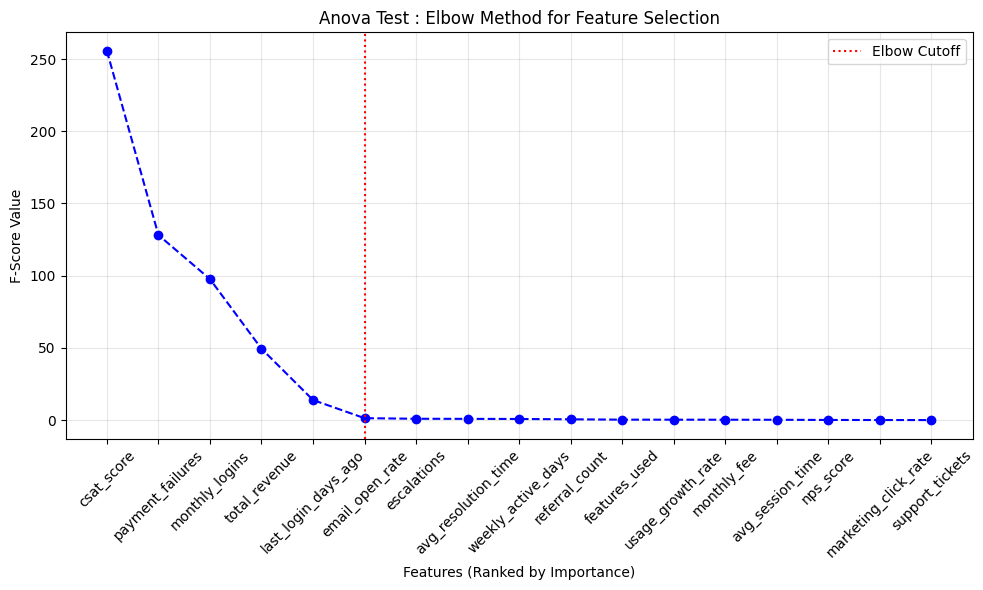

In [ ]:
# Plot the Elbow Curve

plt.figure(figsize=(10, 6))
plt.plot(range(len(anova_results)), anova_results['F-Score'], marker='o', linestyle='--', color='b')
plt.xticks(range(len(anova_results)), anova_results['Features'], rotation=45)
plt.xlabel('Features (Ranked by Importance)')
plt.ylabel('F-Score Value')
plt.title('Anova Test : Elbow Method for Feature Selection')
plt.grid(True, alpha=0.3)

# Add a vertical line at the "Elbow" (visual guess based on our 5 informative features)
plt.axvline(x=5, color='r', linestyle=':', label='Elbow Cutoff')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Define a significance level (alpha) for important features
significance_level = 0.05

# Filter features where p-value is less than the significance level
selected_features_anova = anova_results[anova_results['p-value'] < significance_level]

print(f"Features selected based on ANOVA test (p-value < {significance_level}):")

# display(selected_features_anova)
selected_features_anova.style.format({
    'F-Score': "{:,.2f}",
    'p-value': "{:.4}"
})

df_anova1 = selected_features_anova.reset_index().rename(columns={'index': 'ID'})
df_anova1['ANOVA F-test'] = df_anova1.index+1
display(df_anova1)
anova1_list = df_anova1['Features'].tolist()
print(f"Selected Features of Anova Test: ({len(anova1_list)})", anova1_list)


Features selected based on ANOVA test (p-value < 0.05):


,ID,Features,F-Score,p-value,ANOVA F-test
0,11,csat_score,255.727816,7.405406e-57,1
1,8,payment_failures,128.145382,1.577321e-29,2
2,0,monthly_logins,97.629534,6.423397e-23,3
3,7,total_revenue,49.400921,2.222745e-12,4
4,5,last_login_days_ago,13.892485,1.946385e-04,5


Selected Features of Anova Test: (5) ['csat_score', 'payment_failures', 'monthly_logins', 'total_revenue', 'last_login_days_ago']


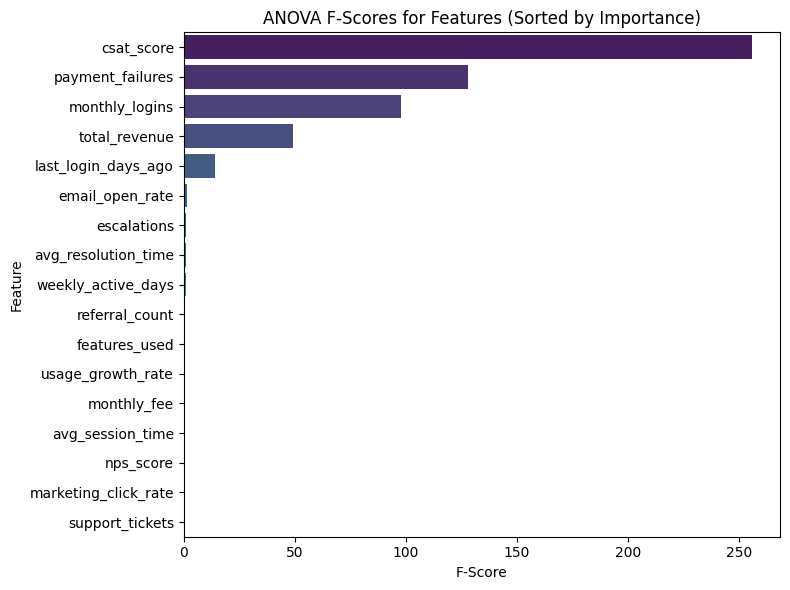

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the anova_results by F-Score in descending order
anova_results_sorted = anova_results.sort_values(by='F-Score', ascending=False)

# Visualize the F-Scores
plt.figure(figsize=(8, 6))
sns.barplot(x='F-Score', y='Features', data=anova_results_sorted, hue='Features', palette='viridis', legend=False)
plt.title('ANOVA F-Scores for Features (Sorted by Importance)')
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Testing Tmp Anova

In [ ]:
#print(df_features_total)
#print(len(all_features_list), all_features_list)
#print(df_anova1.columns)

In [ ]:
# # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
dict_selected_features[test_name] = anova1_list

df_features_total = joinLists(df_features_total, all_features_list,'ANOVA F-test',anova_columns_list, anova1_list, df_anova1 )
display(len(df_features_total), df_features_total)

In [ ]:
display(len(df_features_total), df_features_total)

In [ ]:
# print(f"Columns given to Anova Test ({ len(anova_columns_list)})",anova_columns_list)
# #print(selected_features_anova)
# print(f"Selected Features of Anova Test: ({len(anova1_list)})", anova1_list)

# #Leftover Unimportant Columns from Columns given to Anova Test
# leftOut1 = leftoverAminusB(anova_columns_list, anova1_list)
# print(f"Leftover Unimportant Columns: ({len(leftOut1)}) " , leftOut1)


# df_leftOut1 = pd.DataFrame(leftOut1, columns=['Features'])
# df_leftOut1['ANOVA F-test'] = 0   #Unimportant Columns
# print(df_leftOut1)

# df_anova2 = pd.concat([df_anova1[['Features', 'ANOVA F-test']], df_leftOut1], ignore_index=True)
# display(df_anova2)

# #Columns which were not considered for Anova Test
# leftOut2 = leftoverAminusB(X.columns.tolist(), anova_cols)
# print(f"Columns not considered for Anova Test : ({len(leftOut2)})" , leftOut2)

# df_leftOut2 = pd.DataFrame(leftOut2, columns=['Features'])
# df_leftOut2['ANOVA F-test'] = -1  #These Columns were not considered for Anova Test
# print(df_leftOut2)

# df_anova3 = pd.concat([df_anova2, df_leftOut2], ignore_index=True)

# # df_anova3 = pd.concat([df_anova2[['Features', 'ANOVA F-test']], df_leftOut2], ignore_index=True)
# display(df_anova3)

# # # Merging df_features_total with df_anova3
# left_df = df_features_total.merge(df_anova3, on='Features', how='left')
# print("After Merging\n", left_df.columns)
# display(left_df)
# # # #Filling features which are not in features_to_keep with ZERO i.e. they are not categoried important by this test
# df_features_total=left_df #left_df.fillna(0)

# # print(f"\n {len(df_features_total)}", df_features_total)

In [ ]:
# #Write these  feature ranks to an excel file
# df_features_total.to_excel('features_performances.xlsx', index=False)
# print("Dataframe df_features_total saved to features_performances.xlsx")
# destination_folder_path= '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output'
# move_file_to_folder('features_performances.xlsx', destination_folder_path)

Visualizing the Result (Boxplots)

The best way to verify why ANOVA gave a high score to a feature is to use a Boxplot. If the boxes for each category don't overlap much, the ANOVA score will be high.

Unique values pf csat_score: [4 2 3 5 1]


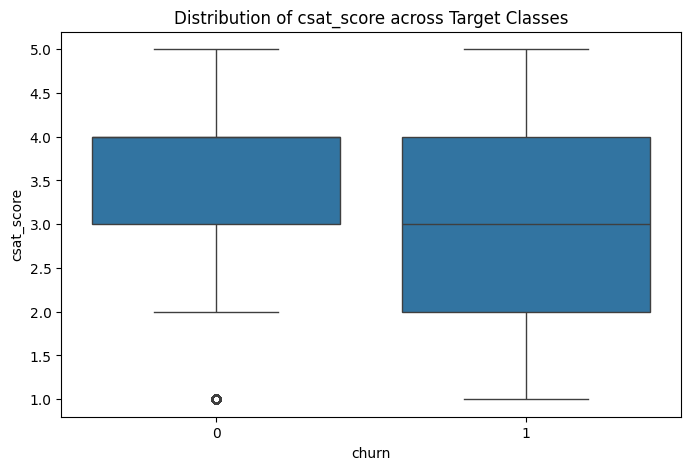

In [ ]:
# Visualize the top-ranked feature
top_feature = anova_results.iloc[0]['Features']
print(f"Unique values {top_feature}: {df_anova[top_feature].unique()}")
plt.figure(figsize=(8, 5))
sns.boxplot(x=y, y=df_anova[top_feature])
plt.title(f"Distribution of {top_feature} across Target Classes")
plt.show()

In [ ]:
df_anova[top_feature].unique()

array([4, 2, 3, 5, 1])

#### Mutual Information (MI) Filter Method

In [ ]:
print( len(X.columns)) #, X.columns)
# Removed hardcoded discreteFeatures list as it causes IndexError.

51


In [ ]:
# print( len(X.columns), X.columns)
# discreteFeatures= [17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51]
# len(discreteFeatures)

35

In [ ]:
# Temp
# Dynamically determine discrete features based on current X DataFrame
# Assuming the first 14 columns are numerical/continuous, and the rest are discrete (e.g., one-hot encoded)
# based on the column list of X after previous operations.
# The actual column list of X after dropping is 36 columns.
# The continuous-like columns are typically: monthly_logins, weekly_active_days, avg_session_time, features_used, last_login_days_ago, monthly_fee, total_revenue, payment_failures, support_tickets, avg_resolution_time, csat_score, escalations, nps_score, referral_count (14 columns)
# num_continuous_features = 14
# discreteFeatures = list(range(num_continuous_features, X.shape[1]))



In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd


# Dynamically determine discrete features based on current X DataFrame
# Assuming the first 17 columns are numerical/continuous, and the rest are discrete (e.g., one-hot encoded)
# based on the column list of X after previous operations.
# The current number of columns in X is 51.
# The continuous-like columns are typically: monthly_logins, weekly_active_days, avg_session_time, features_used, last_login_days_ago, monthly_fee, total_revenue, payment_failures, support_tickets, avg_resolution_time, csat_score, escalations, email_open_rate, marketing_click_rate, nps_score, referral_count (17 columns)
num_continuous_features = 17
discreteFeatures = list(range(num_continuous_features, X.shape[1]))

# Calculate mutual information scores directly using the features from X
# The mutual_info_classif function itself accepts the discrete_features argument
mi_scores_raw = mutual_info_classif(X, y, discrete_features=discreteFeatures)

# Create a pandas Series for easier sorting and viewing
mi_scores = pd.Series(mi_scores_raw, index=X.columns).sort_values(ascending=False)

print(f"Mutual Information Scores ({len(mi_scores)}) : ")
print(mi_scores)

Mutual Information Scores (51) : 
csat_score                     2.248086e-02
total_revenue                  1.511834e-02
monthly_logins                 9.923505e-03
payment_failures               9.590642e-03
escalations                    2.348613e-03
tenure_band_tenure_37+         2.070500e-03
support_tickets                1.942470e-03
usage_growth_rate              1.425775e-03
email_open_rate                1.404232e-03
avg_session_time               1.123448e-03
referral_count                 1.022406e-03
tenure_band_tenure_25_36M      8.229660e-04
features_used                  8.030803e-04
tenure_band_tenure_13_24M      3.379356e-04
country_Germany                1.362987e-04
city_London                    1.256929e-04
signup_channel_Referral        1.254363e-04
customer_segment_SME           1.207012e-04
survey_response_Unsatisfied    1.186603e-04
age_band_Millennials           1.030596e-04
country_India                  9.882057e-05
discount_applied_Yes           8.804670e-0

Mutual Information Scores (51)   (Formatted to 4 decimal places): 


,Feature,MI_Score
0,csat_score,0.0225
1,total_revenue,0.0151
2,monthly_logins,0.0099
3,payment_failures,0.0096
4,escalations,0.0023
5,tenure_band_tenure_37+,0.0021
6,support_tickets,0.0019
7,usage_growth_rate,0.0014
8,email_open_rate,0.0014
9,avg_session_time,0.0011


Table with Title MI Scores > 0.0001 saved as MIScores00001.png
Moved 'MIScores00001.png' to '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Visualization/output/MIScores00001.png' in your Google Drive.


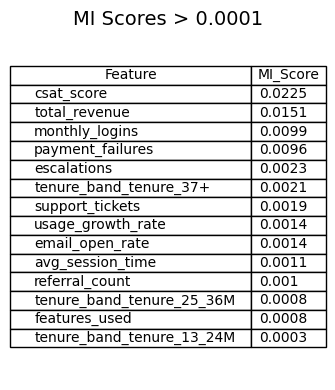

In [ ]:
# Convert the mi_scores Series to a DataFrame for formatting

df_mi_scores = mi_scores.reset_index()
df_mi_scores.columns = ['Feature', 'MI_Score']

print(f"Mutual Information Scores ({len(mi_scores)})   (Formatted to 4 decimal places): ")
display(df_mi_scores.style.format({'MI_Score': "{:.4f}"}))
tableToImage(df_mi_scores.head(14), 'MI Scores > 0.0001', 2,4,4)

In [ ]:
selected_mi_scores = mi_scores[mi_scores > 0.0001]
print(type(selected_mi_scores))
print(f"Mutual Information Scores (mi_scores > .05) ({len(selected_mi_scores)} No):")
print(len(selected_mi_scores), selected_mi_scores)

<class 'pandas.core.series.Series'>
Mutual Information Scores (mi_scores > .05) (20 No):
20 csat_score                     0.022481
total_revenue                  0.015118
monthly_logins                 0.009924
payment_failures               0.009591
escalations                    0.002349
tenure_band_tenure_37+         0.002070
support_tickets                0.001942
usage_growth_rate              0.001426
email_open_rate                0.001404
avg_session_time               0.001123
referral_count                 0.001022
tenure_band_tenure_25_36M      0.000823
features_used                  0.000803
tenure_band_tenure_13_24M      0.000338
country_Germany                0.000136
city_London                    0.000126
signup_channel_Referral        0.000125
customer_segment_SME           0.000121
survey_response_Unsatisfied    0.000119
age_band_Millennials           0.000103
dtype: float64


In [ ]:
# Convert selected_mi_scores into a dataframe
print(type(selected_mi_scores))
df_selected_mi_scores = selected_mi_scores.reset_index()
print(type(df_selected_mi_scores))
df_selected_mi_scores.columns = ['Features', 'MI_Score']

display(len(df_selected_mi_scores), df_selected_mi_scores)

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


20

,Features,MI_Score
0,csat_score,0.022481
1,total_revenue,0.015118
2,monthly_logins,0.009924
3,payment_failures,0.009591
4,escalations,0.002349
5,tenure_band_tenure_37+,0.002070
6,support_tickets,0.001942
7,usage_growth_rate,0.001426
8,email_open_rate,0.001404
9,avg_session_time,0.001123


In [ ]:
df_mi1 = df_selected_mi_scores.reset_index().rename(columns={'index': 'ID'})
df_mi1['MI Rank'] = df_mi1.index+1
print(f"df_mi1 ({len(df_mi1)})")
display(df_mi1)

mi1_list = df_mi1['Features'].tolist()
print(f"mi1_list: Selected Features of MI Test: ({len(mi1_list)})", mi1_list)


df_mi1 (20)


,ID,Features,MI_Score,MI Rank
0,0,csat_score,0.022481,1
1,1,total_revenue,0.015118,2
2,2,monthly_logins,0.009924,3
3,3,payment_failures,0.009591,4
4,4,escalations,0.002349,5
5,5,tenure_band_tenure_37+,0.002070,6
6,6,support_tickets,0.001942,7
7,7,usage_growth_rate,0.001426,8
8,8,email_open_rate,0.001404,9
9,9,avg_session_time,0.001123,10


mi1_list: Selected Features of MI Test: (20) ['csat_score', 'total_revenue', 'monthly_logins', 'payment_failures', 'escalations', 'tenure_band_tenure_37+', 'support_tickets', 'usage_growth_rate', 'email_open_rate', 'avg_session_time', 'referral_count', 'tenure_band_tenure_25_36M', 'features_used', 'tenure_band_tenure_13_24M', 'country_Germany', 'city_London', 'signup_channel_Referral', 'customer_segment_SME', 'survey_response_Unsatisfied', 'age_band_Millennials']


#### Testing Tmp MI

In [ ]:
df_features_total

In [ ]:
# # Format: joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list,'MI Rank',all_features_list, mi1_list, df_mi1 )
display(len(df_features_total), df_features_total)

In [ ]:
# leftOut= leftoverAminusB(X.columns.to_list(), mi1_list)
# print(len(leftOut), leftOut)

# df_leftOut = pd.DataFrame(leftOut, columns=['Features'])
# df_leftOut['MI Rank'] = 0
# # print(df_leftOut)

# df_mi2 = pd.concat([df_mi1[['Features', 'MI Rank']], df_leftOut], ignore_index=True)
# # display(df_mi2)

# # Merging df_features_total with df_mi2
# left_df = df_features_total.merge(df_mi2, on='Features', how='left')
# print("After Merging\n", left_df.columns)
# display(left_df)
# # #Filling features which are not in features_to_keep with ZERO i.e. they are not categoried important by this test
# df_features_total=left_df #.fillna(0)

In [ ]:
# #Write these  feature ranks to an excel file
# df_features_total.to_excel('features_performances.xlsx', index=False)
# print("Dataframe df_features_total saved to features_performances.xlsx")
# destination_folder_path= '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output'
# move_file_to_folder('features_performances.xlsx', destination_folder_path)

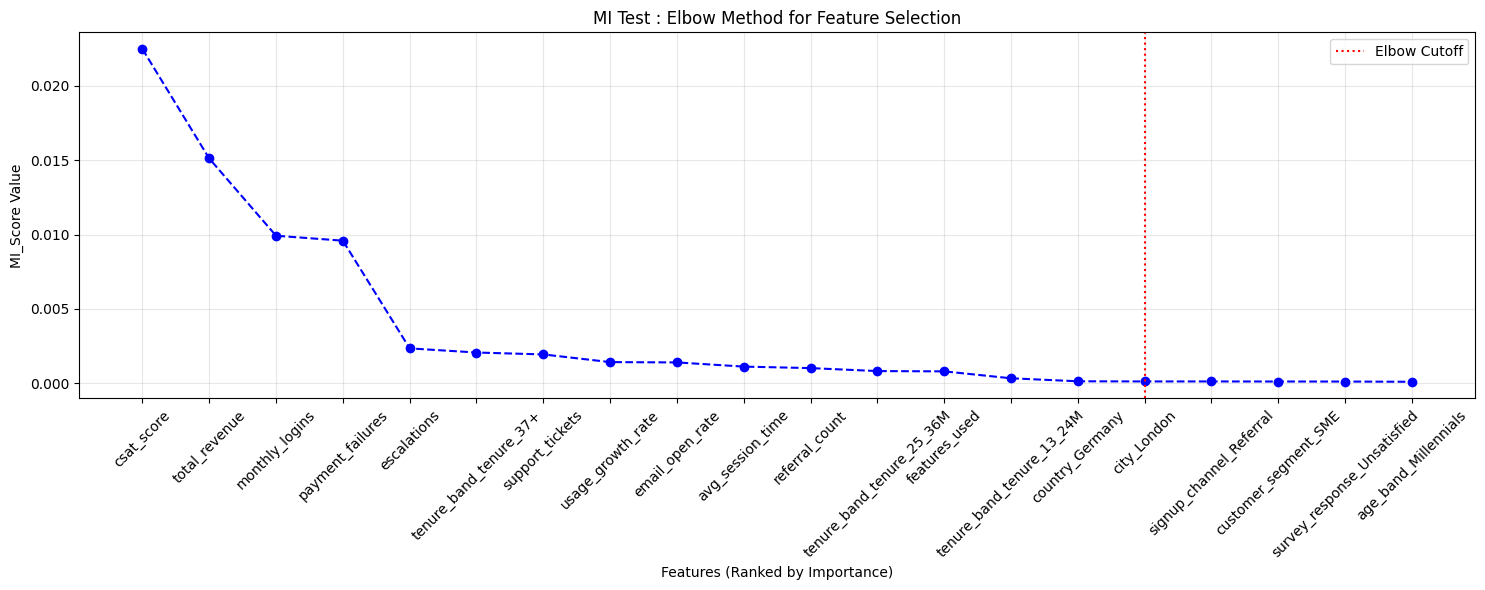

In [ ]:
# Plot the Elbow Curve

plt.figure(figsize=(15, 6))
plt.plot(range(len(df_selected_mi_scores)), df_selected_mi_scores['MI_Score'], marker='o', linestyle='--', color='b')
plt.xticks(range(len(df_selected_mi_scores)), df_selected_mi_scores['Features'], rotation=45)
plt.xlabel('Features (Ranked by Importance)')
plt.ylabel('MI_Score Value')
plt.title('MI Test : Elbow Method for Feature Selection')
plt.grid(True, alpha=0.3)

# Add a vertical line at the "Elbow" (visual guess based on our 5 informative features)
plt.axvline(x=15, color='r', linestyle=':', label='Elbow Cutoff')
plt.legend()
plt.tight_layout()
plt.show()

#### Multicolinearity

###### 1. VIF - Variance Inflation Factor  - The Gold Standard


In [ ]:
X

,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,...,complaint_type_Technical,survey_response_Satisfied,survey_response_Unsatisfied,tenure_band_tenure_13_24M,tenure_band_tenure_25_36M,tenure_band_tenure_37+,age_band_genZ,age_band_Millennials,age_band_genX,age_band_boomers+
0,26,7,11.762372,5,0.06,7,30,660,1,4,...,0,1,0,1,0,0,0,0,0,1
1,7,5,26.846390,1,-0.28,2,30,270,1,1,...,0,0,0,0,0,0,0,0,0,1
2,19,5,23.380065,6,0.13,23,20,1160,2,1,...,0,0,0,0,0,1,1,0,0,0
3,34,7,24.243136,2,-0.17,24,30,570,0,3,...,1,0,0,1,0,0,0,0,1,0
4,20,6,18.872323,2,-0.16,2,50,2600,0,0,...,1,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15,2,16.902793,3,0.31,3,20,740,1,1,...,0,1,0,0,0,1,0,0,0,1
9996,13,2,36.333412,5,0.38,4,50,2100,1,1,...,1,0,1,0,0,1,0,1,0,0
9997,15,6,22.089879,5,0.21,7,20,780,3,1,...,1,1,0,0,0,1,1,0,0,0
9998,14,0,23.549487,5,-0.05,10,30,1560,2,1,...,1,0,0,0,0,1,0,1,0,0


In [ ]:
numeric_cols_X = X.select_dtypes(include=['number']).columns.tolist()
print(X.shape, len(numeric_cols_X))

(10000, 51) 51


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming X is your dataframe of independent variables
vif_data = pd.DataFrame()
vif_data["Features"] = X.columns

# Calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data.head(6))

                  Features        VIF
50       age_band_boomers+  41.274620
49           age_band_genX  26.501737
48    age_band_Millennials  18.781281
47           age_band_genZ  14.218706
7            total_revenue   5.385094
46  tenure_band_tenure_37+   4.537774


In [ ]:
print(vif_data.head(5)['Features'].to_list())

['age_band_boomers+', 'age_band_genX', 'age_band_Millennials', 'age_band_genZ', 'total_revenue']


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def reduce_vif(df, threshold=5.0):
    # Ensure we only work with numerical data
    curr_df = df.select_dtypes(include=['number']).copy()

    dropped_cols = []
    while True:
        # 1. Calculate VIF for each column
        vif_data = pd.DataFrame()
        vif_data["feature"] = curr_df.columns
        vif_data["VIF"] = [variance_inflation_factor(curr_df.values, i)
                          for i in range(len(curr_df.columns))]

        # 2. Find the feature with the highest VIF
        max_vif = vif_data["VIF"].max()

        if max_vif > threshold:
            # 3. Identify and drop it
            max_feature = vif_data.sort_values("VIF", ascending=False).iloc[0]["feature"]
            curr_df.drop(columns=[max_feature], inplace=True)
            dropped_cols.append(max_feature)
            print(f"Dropped '{max_feature}' with VIF: {max_vif:.2f}")
        else:
            # 4. Stop if all features are below threshold
            break

    return curr_df, dropped_cols

# Usage:
VIF_X_cleaned, VIF_dropped_cols = reduce_vif(X)
print(f"\nDropped Columns: {VIF_dropped_cols}")
displayDFsummary(VIF_X_cleaned, 'VIF_X_cleaned')

Dropped 'age_band_boomers+' with VIF: 41.27
Dropped 'csat_score' with VIF: 11.86
Dropped 'monthly_fee' with VIF: 10.78
Dropped 'customer_segment_Individual' with VIF: 6.31
Dropped 'avg_resolution_time' with VIF: 6.19
Dropped 'features_used' with VIF: 5.62
Dropped 'avg_session_time' with VIF: 5.51
Dropped 'email_open_rate' with VIF: 5.21

Dropped Columns: ['age_band_boomers+', 'csat_score', 'monthly_fee', 'customer_segment_Individual', 'avg_resolution_time', 'features_used', 'avg_session_time', 'email_open_rate']
Summary of Datafrme VIF_X_cleaned : Shape:  (10000, 43)  Type:  <class 'pandas.core.frame.DataFrame'> 
 Columns:  ['monthly_logins', 'weekly_active_days', 'usage_growth_rate', 'last_login_days_ago', 'total_revenue', 'payment_failures', 'support_tickets', 'escalations', 'marketing_click_rate', 'nps_score', 'referral_count', 'gender_Male', 'country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Delhi', 'city_Dhaka', 'city_Lon

###### Condition Index
Looks at the "spread" of eigenvalues in your data.
Interpretation Rules :
Condition Index < 10: Good (no serious multicollinearity).
Condition Index 10–30: Moderate multicollinearity.
Condition Index > 30: Severe multicollinearity; the model is likely unstable.


The ci_results DataFrame shows the eigenvalues and condition indices for your feature set, but it doesn't list individual feature names in its rows directly. Each row corresponds to a component derived from the entire set of features.

However, the multicol_analysis_results (from below mentioned code, the identify_multicollinearity_sources function) is specifically designed to link high condition indices to the contributing features. This is where you will find the actual feature names that are causing severe multicollinearity.

In [ ]:
# Filter out columns from X that have zero standard deviation
# This addresses issues where columns might be all zeros (e.g., from one-hot encoding with no occurrences)
# and would cause LinAlgError due to division by zero in the scaling step of calculate_condition_index.
X_filtered = X.loc[:, X.std() != 0]

ci_results = calculate_condition_index(X_filtered)
print(ci_results)

In [ ]:
# To link high condition indices to the contributing features, where you will find the actual feature names that are causing severe multicollinearity.
import numpy as np
import pandas as pd

def identify_multicollinearity_sources(X_data, condition_index_threshold=30):

    # 1. Filter out columns with zero standard deviation to prevent errors
    X_filtered = X_data.loc[:, X_data.std() != 0]

    # If no features remain after filtering, return an empty result
    if X_filtered.empty:
        print("No varying features to analyze for multicollinearity.")
        return pd.DataFrame()

    # 2. Standardize the data (Scale to unit length) for Condition Index calculation
    X_scaled = X_filtered / np.linalg.norm(X_filtered, axis=0)

    # 3. Compute eigenvalues and eigenvectors of (X'X)
    xtx = np.dot(X_scaled.T, X_scaled)
    eigenvalues, eigenvectors = np.linalg.eig(xtx)

    # 4. Sort eigenvalues in ascending order and get the corresponding indices
    sorted_indices = np.argsort(eigenvalues)
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    # 5. Calculate Condition Indices
    max_ev = sorted_eigenvalues[-1] # Largest eigenvalue
    condition_indices = np.sqrt(max_ev / sorted_eigenvalues)

    print(f"\n--- Multicollinearity Analysis for Condition Index > {condition_index_threshold} ---")

    multicollinearity_sources = []
    for i in range(len(condition_indices)):
        ci = condition_indices[i]
        if ci > condition_index_threshold:
            eigenvector = sorted_eigenvectors[:, i]
            feature_loadings = pd.Series(eigenvector, index=X_filtered.columns)

            # Identify features with significant loadings in this eigenvector
            # A common heuristic is to consider loadings > 0.3 or 0.5 as significant
            significant_loadings = feature_loadings[feature_loadings.abs() > 0.3].sort_values(ascending=False, key=abs)

            if not significant_loadings.empty:
                multicollinearity_sources.append({
                    'Condition_Index': ci,
                    'Eigenvalue': sorted_eigenvalues[i],
                    'Contributing_Features': significant_loadings.to_dict()
                })

    if not multicollinearity_sources:
        print("No severe multicollinearity found above the specified threshold.")
        return pd.DataFrame()

    return pd.DataFrame(multicollinearity_sources)

# Run the analysis using the 'X' DataFrame
multicol_analysis_results = identify_multicollinearity_sources(X, condition_index_threshold=30)

if not multicol_analysis_results.empty:
    print("\nFeatures contributing to severe multicollinearity (Condition Index > 30):")
    for _, row in multicol_analysis_results.iterrows():
        print(f"  - Condition Index: {row['Condition_Index']:.2f}")
        print(f"    Eigenvalue: {row['Eigenvalue']:.4f}")
        print(f"    Contributing Features (Loading): {row['Contributing_Features']}")
else:
    print("No severe multicollinearity identified based on the threshold.")

2.__Embedded Method: Feature Importance__
Some models, like Random Forest or XGBoost, automatically calculate which features contribute most to reducing error during training.
This is often the most reliable method for non-linear data

3. __Wrapper Method__: Recursive Feature Elimination (RFE)
This method works by building a model multiple times. In each iteration, it removes the weakest feature until only the specified number of features remain.

__Final Thought: Data Leakage__
One of the most common mistakes in exploratory analysis is Data Leakage. This happens if you calculate the mean or max of your entire dataset and use it to scale. Always fit your scalers and imputers on the Training set only and then apply that logic to the Test set. This simulates a "real world" scenario where the model encounters data it has never seen before.
Would you like me to explain how to save this processed data and the scaler objects so you can use them later in a real-time application?

To use your processed data and scaling logic in a production app or a future session, you need to save two things: the Cleaned Data (usually as a CSV or Parquet) and the Fitted Objects (Scalers, Imputers, and Encoders).
If you don't save the exact scaler used during training, your model will fail when it tries to predict new data because the numbers won't "match" the original scale.

__1. Saving the Data__
For data, Parquet is often preferred over CSV because it preserves data types (like integers vs. floats) and is much faster for large datasets.


In [ ]:
# Save to CSV
dfAccounts.to_csv('cleaned_accounts_data.csv', index=False)

# Save to Parquet (requires 'pyarrow' or 'fastparquet' library)
#df.to_parquet('cleaned_accounts_data.parquet')


### __Optional: Saving the Scalers and Models__ (Serialization)

We use the joblib library (or pickle) to "freeze" the state of your scaler and imputer. This ensures that if you get a new passenger today, you can scale their fare using the same mean and standard deviation from your training set.


In [ ]:

import joblib

# Save the Scaler
joblib.dump(scaler, 'standard_scaler.joblib')

# Save the Imputer (if you used one)
joblib.dump(imputer_seats, 'seats_imputer.joblib')

# Save your final trained Model
joblib.dump(model, 'accounts_model.joblib')


3. __Loading and Using in a New Script__
When you are ready to deploy your model, your "Prediction Script" would look like this:

In [ ]:
import joblib
import numpy as np

# 1. Load the saved objects
loaded_scaler = joblib.load('standard_scaler.joblib')
loaded_model = joblib.load('accounts_model.joblib')

# # 2. New incoming data (raw features)
# new_data = np.array([[22, 7.25, 1, 0, 0, 1]]) # Example raw features

# # 3. Apply the SAME scaling
# new_data_scaled = loaded_scaler.transform(new_data)

# # 4. Predict!
# prediction = loaded_model.predict(new_data_scaled)
# print(f"Survival Prediction: {prediction}")


#  Building the ML Model
This part of script completes the workflow by training a Random Forest Classifier—one of the best-performing models for this dataset—and evaluating it with a Confusion Matrix

### Finding Accuracies of Various Models

In [ ]:
metric_precision_parameters=['Metric', 'Feature Selection Method', 'Accuracy', 'AUC Score', 'Gini Coefficient', 'F1 Score', 'Precision', 'Recall']
df_metrics_performance = pd.DataFrame(columns=metric_precision_parameters)
display(df_metrics_performance)

,Metric,Feature Selection Method,Accuracy,AUC Score,Gini Coefficient,F1 Score,Precision,Recall


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
# Save the Scaler
# joblib.dump(scaler, 'standard_scaler.joblib')

In [ ]:
X_test_scaled = scaler.transform(X_test)


#### LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)


In [ ]:
# log_model.predict([[0,454,11,2,3,2,3,1]])[0]

y_pred = log_model.predict(X_test_scaled)
modelPerformance(y_test, y_pred)
# log_model.score(X_train_scaled, y_train)

In [ ]:
# Laogistic Model Basic Evaluation
accuracy_score_lr = getClassificationMetrics1("LogisticRegression Basic", y_test, y_pred)
print(f"Accuracy: {accuracy_score_lr:.2%}")

In [ ]:
auc_score_lr, gini_coefficient_lr, f1_lr, precision_lr, recall_lr = getClassificationMetrics2(log_model, X_test_scaled, y_test, y_pred)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['LogisticRegression', 'General Filter Methods', accuracy_score_lr, auc_score_lr, gini_coefficient_lr, f1_lr, precision_lr, recall_lr]

display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

##### Hyperparameter Tuning

To squeeze that extra performance out of your model, we use Hyperparameter Tuning. Think of hyperparameters as the "knobs and dials" of your algorithm. For a Random Forest, this includes things like the number of trees or the depth of those trees. The industry standard for this is GridSearchCV.

__1. How GridSearchCV Works__
   It systematically works through a "grid" of parameter combinations, cross-validating each one to ensure the results are consistent.
   
__K-Fold Cross-Validation__:
   Instead of one split, it divides the data into K parts (folds), training on (K-1) and testing on the remaining one, rotating until every fold has been the test set.

### 2. Implementation: Tuning the Logistic Regression

In [ ]:
df_metrics_performance

###### L1 (Lasso) Regularization

In [ ]:
#Execution Time Earlier: 12s

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for L1 regularization
param_grid_l1 = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['liblinear', 'saga'],      # Solvers that support L1 penalty
    'max_iter': [1000]                    # Increase max_iter for convergence
}

# Initialize Logistic Regression model with L1 penalty
logreg_l1 = LogisticRegression(penalty='l1', random_state=42)

# Initialize GridSearchCV
grid_search_l1 = GridSearchCV(estimator=logreg_l1,
                              param_grid=param_grid_l1,
                              cv=5,
                              scoring='accuracy',
                              n_jobs=-1,
                              verbose=1)

# Fit GridSearchCV to the scaled training data
grid_search_l1.fit(X_train_scaled, y_train)
features_for_l1_test=X_train_scaled.columns.tolist()

# Print best parameters and score
print(f"\nBest Parameters for L1 Logistic Regression: {grid_search_l1.best_params_}")
print(f"Best Cross-Validation Score for L1 Logistic Regression: {grid_search_l1.best_score_:.2%}")

# Evaluate the best model on the test set
best_logreg_l1_model = grid_search_l1.best_estimator_
y_pred_l1 = best_logreg_l1_model.predict(X_test_scaled)

print("\nFinal Test Accuracy for L1 Logistic Regression:", end=" ")
modelPerformance(y_test, y_pred_l1)

print("\nCoefficients (features selected by L1 regularization):")
# Display non-zero coefficients to show feature selection
lasso_coefficients = pd.Series(best_logreg_l1_model.coef_[0], index=X.columns)
print(lasso_coefficients)
selected_lasso_features = lasso_coefficients[lasso_coefficients != 0].sort_values(ascending=False)
print(selected_lasso_features)


In [ ]:
# Because Each of lasso_coefficients is zero, The Penalty is perhaps Too High
# You can use LassoCV to automatically find the "sweet spot" for alpha so you don't end up with all zeros.

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Always scale data for Lasso
# 2. LassoCV tries multiple alphas and picks the best one via cross-validation
model = make_pipeline(StandardScaler(), LassoCV(cv=5))
model.fit(X_train, y_train)

# Access the Lasso part of the pipeline
lasso_model = model.named_steps['lassocv']
print(f"Best Alpha: {lasso_model.alpha_}")
print(f"Non-zero coefficients: {sum(lasso_model.coef_ != 0)}")

In [ ]:
print("Non-zero coefficients and their feature names:")
for i, coef in enumerate(lasso_model.coef_):
    if coef != 0:
        print(f"  {X_train.columns[i]}: {coef:.4f}")

In [ ]:
test_name = 'Logistic Lasso L1'
df_lasso_coefficients = pd.DataFrame({
    'Features': X.columns,
    test_name: lasso_model.coef_
})

df_lasso_coefficients = df_lasso_coefficients.sort_values(by=test_name, ascending=False)
print("Lasso Model Coefficients (Sorted Descending):")
display(df_lasso_coefficients)
df_lasso_coefficients = df_lasso_coefficients[df_lasso_coefficients[test_name] != 0]
print("df_lasso_coefficients : ",df_lasso_coefficients.shape, type(df_lasso_coefficients), "\n", df_lasso_coefficients.columns)
features_selected_by_l1 = df_lasso_coefficients['Features'].tolist()


###### Testing Tmp L1

In [ ]:
df_lasso_coefficients = give_rank__to_columns(df_lasso_coefficients, test_name)
print("df_lasso_coefficients : ",df_lasso_coefficients.shape, type(df_lasso_coefficients), "\n", df_lasso_coefficients.columns)
display(df_lasso_coefficients)

In [ ]:
# Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
dict_selected_features[test_name] = features_selected_by_l1

df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_l1_test, features_selected_by_l1, df_lasso_coefficients)
print("df_features_total : ", df_features_total.shape,  )
display(df_features_total)


In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):


In [ ]:
# Lasso L1 Model Basic Evaluation
accuracy_score_l1 = getClassificationMetrics1("LogisticRegression Lasso L1", y_test, y_pred_l1)
print(f"Accuracy: {accuracy_score_l1:.2%}")

In [ ]:
# Getting Metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_l1, gini_coefficient_l1, f1_l1, precision_l1, recall_l1 = getClassificationMetrics2(best_logreg_l1_model, X_test_scaled, y_test, y_pred_l1)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['LogisticRegression', 'Lasso L1 Selected', accuracy_score_l1, auc_score_l1, gini_coefficient_l1, f1_l1, precision_l1, recall_l1]

display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

In [ ]:
# Write the above df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

###### RFE (based on coef_)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression as the estimator
model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Initialize RFE to select the top 30 features
# We use `X.columns` to get the feature names from the original (non-scaled) DataFrame
# and then use them with the scaled data for RFE.
rfe = RFE(estimator=model, n_features_to_select=30) #for all feaures use X_train_scaled.shape[1]

# Fit RFE on the scaled training data
rfe.fit(X_train_scaled, y_train)
features_for_logistic_rfe=X_train_scaled.columns.tolist()

# Get the selected features
selected_features_rfe = X.columns[rfe.support_]

print("--- RFE Feature Selection Results ---")
print(f"Selected Features by RFE ({len(selected_features_rfe)}):\n{selected_features_rfe.tolist()}")

In [ ]:
test_name= 'Logistic RFE Rank'
print("\nFeature Ranking (1=selected, higher=less important):\n")
# Create a DataFrame to display feature rankings

df_logistic_rfe  = pd.DataFrame({
    'Features': X.columns,
    test_name: rfe.ranking_
}).sort_values(by=test_name, ascending=True)

display(df_logistic_rfe)
print("df_logistic_rfe : ",df_logistic_rfe.shape, type(df_logistic_rfe), "\n", df_logistic_rfe.columns)

features_selected_by_logistic_rfe=df_logistic_rfe['Features'].tolist() #??????

###### Testing Tmp RFE Logistic

In [ ]:
df_logistic_rfe = give_rank__to_columns(df_logistic_rfe, test_name)
display(df_logistic_rfe)
displayDFsummary(df_logistic_rfe, "df_logistic_rfe")


In [ ]:
dict_selected_features[test_name] = features_selected_by_logistic_rfe

# Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_logistic_rfe, features_selected_by_logistic_rfe, df_logistic_rfe)
display(df_features_total)
displayDFsummary(df_features_total, "df_features_total")


In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):


In [ ]:
from sklearn.linear_model import LogisticRegression

# Get the list of selected features from RFE
selected_features_rfe_list = selected_features_rfe.tolist()

# Prepare training and testing data with only RFE selected features
X_train_rfe = X_train_scaled[selected_features_rfe_list]
X_test_rfe = X_test_scaled[selected_features_rfe_list]

# Train a Logistic Regression model using RFE selected features
log_model_rfe = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
log_model_rfe.fit(X_train_rfe, y_train)

# Make predictions with the RFE-selected model
y_pred_rfe = log_model_rfe.predict(X_test_rfe)

In [ ]:
# Logistic Regression RFE Model Basic Evaluation
accuracy_score_rfe = getClassificationMetrics1("LogisticRegression RFE", y_test, y_pred_rfe)

In [ ]:
# Getting additional metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_rfe, gini_coefficient_rfe, f1_rfe, precision_rfe, recall_rfe = getClassificationMetrics2(log_model_rfe, X_test_rfe, y_test, y_pred_rfe)

# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['LogisticRegression', 'RFE Selected', accuracy_score_rfe, auc_score_rfe, gini_coefficient_rfe, f1_rfe, precision_rfe, recall_rfe]

display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

In [ ]:
# Write the updated df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

In [ ]:
#Correlation of RFE-Selected Features with Churn

# Get the list of selected features from RFE
selected_features = selected_features_rfe.tolist()

# Add the target variable 'churn' to the list of features
features_for_correlation = selected_features + ['churn']

# Create a DataFrame with only the selected features and the target variable
df_selected_for_corr = df_encoded[features_for_correlation]

# Calculate the correlation matrix
correlations_with_churn = df_selected_for_corr.corr()['churn'].sort_values(ascending=False)

# Drop the 'churn' row itself from the correlations
correlations_with_churn = correlations_with_churn.drop('churn')

print("Correlation of RFE-Selected Features with Churn:")
display(correlations_with_churn.to_frame())

#### KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],

}
# 'metric': ['euclidean', 'manhattan', 'minkowski']
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

In [ ]:
knn_y_pred = knn_model.predict(X_test_scaled)
modelPerformance(y_test, knn_y_pred)

In [ ]:
# Execution Time Earlier: 10sec

# Apply GridSearchCV to find best parameters

# 1. Initialize the Grid Search
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all your computer's CPU cores to speed it up

#start_time=currentTimeIST()

gridkn = GridSearchCV(estimator=knn_model,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# 2. Fit the grid search to the data
gridkn.fit(X_train_scaled, y_train)

# end_time=currentTimeIST()
# print(f"Execution Time: {end_time - start_time} seconds")

# 3. Results
print(f"Best Parameters: {gridkn.best_params_}")
print(f"Best Cross-Validation Score: {gridkn.best_score_:.2%}")

# 4. Use the best model to predict on the test set
best_knn_model = gridkn.best_estimator_
y_final_pred_knn = best_knn_model.predict(X_test_scaled)
print(f"Final Test Accuracy with Tuned KNN: ", end="")
modelPerformance(y_test, y_final_pred_knn)

In [ ]:
# Laogistic Model Basic Evaluation
accuracy_score_knn = getClassificationMetrics1("KNeighbors Basic", y_test, y_pred)
# print(f"Accuracy: {accuracy_score_lr:.2%}")

In [ ]:
auc_score_knn, gini_coefficient_knn, f1_knn, precision_knn, recall_knn = getClassificationMetrics2(best_knn_model, X_test_scaled, y_test, y_pred)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['KNeighbors', 'General Filter Methods', accuracy_score_knn, auc_score_knn, gini_coefficient_knn, f1_knn, precision_knn, recall_knn]

display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

##### Wrapper Method SFS (Sequential Forward Selection)

In [ ]:
try:
    from mlxtend.feature_selection import SequentialFeatureSelector
except ImportError:
    print("mlxtend not found. Installing...")
    !pip install mlxtend
    from mlxtend.feature_selection import SequentialFeatureSelector

from sklearn.neighbors import KNeighborsClassifier

print("SequentialFeatureSelector and KNeighborsClassifier have been imported.")

In [ ]:
# Execution time Earlier: 10 minutes

start_time=currentTimeIST()

# Ensure X_train_scaled is a DataFrame with column names
if not isinstance(X_train_scaled, pd.DataFrame):
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)

# Initialize a KNeighborsClassifier instance
knn = KNeighborsClassifier(n_neighbors=5)

# Initialize SequentialFeatureSelector
sfs = SequentialFeatureSelector(knn,
                                k_features=(1, X_train_scaled.shape[1]),
                                forward=True,
                                floating=False,
                                scoring='accuracy',
                                cv=5,
                                n_jobs=-1) # Use all available cores

# Fit SFS to the scaled training data
sfs.fit(X_train_scaled, y_train)
features_for_sfs=X_train_scaled.columns.tolist()

end_time=currentTimeIST()
print(f"Execution Time: {end_time - start_time} seconds")

# Get the selected features
selected_features_sfs = list(X_train_scaled.columns[list(sfs.k_feature_idx_)])
features_selected_by_sfs=selected_features_sfs

print("\n--- Sequential Feature Selector Results ---")
print(f"Selected Features by SFS ({len(selected_features_sfs)}): {selected_features_sfs}")
print(f"Best Score achieved by SFS: {sfs.k_score_:.2%}")

# Plot the feature importances (optional - can be adapted for SFS if feature scores are extracted)
# This specific plot is not directly from SFS k_scores, but shows how one might visualize results.
# For SFS, usually one would plot k_score_ for different k values.

# To visualize the performance across different k_features values
fig = plt.figure(figsize=(10, 6))
plt.plot(list(sfs.subsets_.keys()), [sfs.subsets_[k]['avg_score'] for k in sfs.subsets_], marker='o')
plt.xlabel('Number of features')
plt.ylabel('Accuracy Score')
plt.title('Sequential Forward Selection (SFS) Performance')
plt.grid()
plt.show()

In [ ]:
features_for_sfs=X_train_scaled.columns.tolist()
features_selected_by_sfs=selected_features_sfs


In [ ]:
test_name = 'KNeighborsClassifier SFS Rank'
# Create a DataFrame from the list of selected features
df_sfs = pd.DataFrame(features_selected_by_sfs, columns=['Features'])

#(SFS)—as implemented in sklearn—does not provide a traditional numerical ranking (like 1st, 2nd, 3rd) in its final output. Instead, it provides a boolean mask of the "best" subset of features.
df_sfs[test_name] = 1
display(df_sfs)
displayDFsummary(df_sfs, "df_sfs")

###### Testing Tmp SFS

In [ ]:
# Use the helper function to add a rank to the selected features
df_sfs = give_rank__to_columns(df_sfs, test_name)

print(f"DataFrame for SFS Selected Features ({len(df_sfs)})")
display(df_sfs)
displayDFsummary(df_sfs, "df_sfs")

In [ ]:
dict_selected_features[test_name] = features_selected_by_sfs

# # # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):

# Update the main features_total DataFrame
df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_sfs, features_selected_by_sfs, df_sfs)
display(df_features_total)
displayDFsummary(df_features_total, "df_features_total")



In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):


Creating Classification Metrics for SFS



In [ ]:
# Prepare training and testing data with only SFS selected features
X_train_sfs = X_train_scaled[selected_features_sfs]
X_test_sfs = X_test_scaled[selected_features_sfs]

# Train a KNeighborsClassifier model using SFS selected features
# Using the best parameters found during GridSearchCV for KNN
knn_model_sfs = KNeighborsClassifier(n_neighbors=gridkn.best_params_['n_neighbors'], weights=gridkn.best_params_['weights'])
knn_model_sfs.fit(X_train_sfs, y_train)

# Make predictions with the SFS-selected model
y_pred_sfs = knn_model_sfs.predict(X_test_sfs)

In [ ]:
# SFS Model Basic Evaluation
accuracy_score_sfs = getClassificationMetrics1("KNN SFS", y_test, y_pred_sfs)

In [ ]:
# Getting additional metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_sfs, gini_coefficient_sfs, f1_sfs, precision_sfs, recall_sfs = getClassificationMetrics2(knn_model_sfs, X_test_sfs, y_test, y_pred_sfs)

# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['KNeighborsClassifier', 'SFS', accuracy_score_sfs, auc_score_sfs, gini_coefficient_sfs, f1_sfs, precision_sfs, recall_sfs]
display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

In [ ]:
# Write the updated df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

#### SVM

In [ ]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'], # , 'sigmoid', Kernel type
    'gamma': ['scale', 'auto'] # Kernel coefficient
}

svm = SVC()
svm.fit(X_train_scaled, y_train)

SVC()

In [ ]:
# svm.predict([[0,454,11,2,3,2,3,1]])[0]

y_pred = svm.predict(X_test_scaled)
modelPerformance(y_test, y_pred)
# log_model.score(X_train_scaled, y_train)

In [ ]:
# Logistic Model Basic Evaluation
accuracy_score_svm = getClassificationMetrics1("SVM Basic", y_test, y_pred)
print(f"Accuracy: {accuracy_score_svm:.2%}")

In [ ]:
auc_score_svm, gini_coefficient_svm, f1_svm, precision_svm, recall_svm = getClassificationMetrics2(svm, X_test_scaled, y_test, y_pred)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['SVM', 'General Filter Methods', accuracy_score_svm, auc_score_svm, gini_coefficient_svm, f1_svm, precision_svm, recall_svm]
no_decimal="{:.4f}"
display(df_metrics_performance.style.format({
    'Accuracy': no_decimal,
    'AUC Score': no_decimal,
    'Gini Coefficient': no_decimal,
    'F1 Score': no_decimal,
    'Precision': no_decimal,
    'Recall': no_decimal
}))

##### Finding Best Parameters

In [ ]:
# Execution time more than 3 hour and 30 minutes and continuing
start_time=currentTimeIST()

gridSvm = GridSearchCV(estimator=svm,
                           param_grid=param_grid,
                           cv=3,   # 5
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# 2. Fit the grid search to the data
gridSvm.fit(X_train_scaled, y_train)

end_time=currentTimeIST()
print(f"Execution Time: {end_time - start_time} seconds")

# 3. Results
print(f"Best Parameters: {gridSvm.best_params_}")
print(f"Best Cross-Validation Score: {gridSvm.best_score_:.2%}")

# 4. Use the best model to predict on the test set
best_Svm_model = gridSvm.best_estimator_
y_final_pred_svm = best_Svm_model.predict(X_test_scaled)
print(f"Final Test Accuracy with Tuned SVM: ", end="")
modelPerformance(y_test, y_final_pred_svm)


In [ ]:
'''
Explanation for long execution time of GridSearchCV for SVC:

The cell above (cell_id: 5EmHxKGd9NSv) was running GridSearchCV with an SVC model, which is a very computationally intensive task for several reasons:

1.  **Algorithm Complexity**: Support Vector Machines (SVMs), especially with non-linear kernels ('rbf', 'poly'), have a high computational complexity, often O(n^2 * features) to O(n^3 * features), where 'n' is the number of samples (8000 in your training set).

2.  **GridSearchCV Exhaustiveness**: GridSearchCV performs an exhaustive search over all specified hyperparameter combinations. In this case, your `param_grid` included:
    *   `C`: 4 values
    *   `kernel`: 3 values
    *   `gamma`: 2 values
    This results in `4 * 3 * 2 = 24` unique hyperparameter combinations.

3.  **Cross-Validation (`cv=5`)**: For each of these 24 combinations, the model is trained and evaluated 5 times (due to 5-fold cross-validation). This means the SVC model was trained a total of `24 combinations * 5 folds = 120 times`.

4.  **Combined Impact**: Training 120 complex SVM models on a dataset of 8000 samples, even with `n_jobs=-1` to utilize multiple CPU cores, demands significant computational resources and time. This is why it took over an hour and had to be interrupted.

To mitigate this, one might consider:
*   **Reducing the `param_grid` size**: Fewer values for C, fewer kernel types.
*   **Reducing `cv` folds**: e.g., `cv=3` instead of `cv=5`.
*   **Using RandomizedSearchCV**: Instead of an exhaustive search, this samples a fixed number of combinations, often finding good parameters much faster.
*   **Using simpler models for initial tuning**: Start with a faster model or a linear kernel SVM, then progressively move to more complex ones.
*   **Reducing dataset size**: For initial exploration, sampling a smaller subset of your data can speed up tuning.
'''

##### Embedded Method L1-LinearSVC


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
import pandas as pd

# Initialize LinearSVC with L1 regularization
# dual=False is required for L1 penalty when n_samples > n_features
lsvc = LinearSVC(penalty='l1', dual=False, max_iter=2000, random_state=42)

# Fit the LinearSVC model to the scaled training data
lsvc.fit(X_train_scaled, y_train)
features_for_l1SVC =X_train_scaled.columns.tolist()



# Use SelectFromModel to select features based on coefficients
# threshold='median' selects features whose coefficients are above the median
model_lsvc = SelectFromModel(lsvc, prefit=True, threshold='median')

# Transform the training data to keep only selected features
X_train_lsvc_selected = model_lsvc.transform(X_train_scaled)

# Get the names of the selected features
selected_features_lsvc = X.columns[model_lsvc.get_support()]

print("--- L1-LinearSVC Feature Selection Results ---")
print(f"Number of features originally: {X_train_scaled.shape[1]}")
print(f"Number of features selected: {X_train_lsvc_selected.shape[1]}")
print(f"Selected Features by L1-LinearSVC:\n{selected_features_lsvc.tolist()}")

In [ ]:
test_name = "SVM L1"

# Get the coefficients from the fitted LinearSVC model
# The coefficients correspond to the original features in X_train_scaled
lsvc_coefficients = lsvc.coef_[0]

# Create a DataFrame to map coefficients to feature names
df_lsvc = pd.DataFrame({
    'Features': X.columns,
    test_name: lsvc_coefficients
})

# Filter to include only the features that were selected by SelectFromModel
df_lsvc = df_lsvc[df_lsvc['Features'].isin(selected_features_lsvc)]

# Sort by the absolute value of the coefficients to show importance
df_lsvc = df_lsvc.reindex(df_lsvc[test_name].abs().sort_values(ascending=False).index)

print(f"Feature Ranking for L1-LinearSVC selected features ({len(df_lsvc)}):")
display(df_lsvc)

features_selected_by_l1SVC = df_lsvc['Features'].tolist()



###### Testing Tmp L1 SVM

In [ ]:
df_lsvc = give_rank__to_columns(df_lsvc, test_name)
display(df_lsvc)
print("df_lsvc : ",df_lsvc.shape, type(df_lsvc), "\n", df_lsvc.columns)

In [ ]:
dict_selected_features[test_name] = features_selected_by_l1SVC

# Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_l1SVC, features_selected_by_l1SVC, df_lsvc)
print("df_features_total : ", df_features_total.shape)
display(df_features_total)

In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):


Creating Classification Metrics for L1 SVM

In [ ]:
# Prepare training data with only L1-LinearSVC selected features
X_train_lsvc_filtered = X_train_scaled[selected_features_lsvc]

# Prepare testing data with only L1-LinearSVC selected features
X_test_lsvc_filtered = X_test_scaled[selected_features_lsvc]

# Re-initialize and re-train the LinearSVC model on the filtered features
lsvc_filtered = LinearSVC(penalty='l1', dual=False, max_iter=2000, random_state=42)
lsvc_filtered.fit(X_train_lsvc_filtered, y_train)

# Make predictions with the re-trained L1-LinearSVC model
y_pred_lsvc = lsvc_filtered.predict(X_test_lsvc_filtered)

# L1-LinearSVC Model Basic Evaluation
accuracy_score_lsvc = getClassificationMetrics1("L1-LinearSVC", y_test, y_pred_lsvc)

In [ ]:
# Getting additional metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_lsvc, gini_coefficient_lsvc, f1_lsvc, precision_lsvc, recall_lsvc = getClassificationMetrics2(lsvc_filtered, X_test_lsvc_filtered, y_test, y_pred_lsvc)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['LinearSVC', 'L1 Selected', accuracy_score_lsvc, auc_score_lsvc, gini_coefficient_lsvc, f1_lsvc, precision_lsvc, recall_lsvc]

display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

In [ ]:
# Write the above df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

##### Wrapper Method SVM-RFE

In [ ]:
#Execution Time above 2 minutes
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
import pandas as pd

# Initialize the SVC estimator
# Using a linear kernel is often preferred for RFE with SVMs for feature importance based on coefficients
svc_estimator = SVC(kernel='linear', random_state=42)

# Initialize RFE with the SVC estimator
# Select, for example, 20 features
rfe_svc = RFE(estimator=svc_estimator, n_features_to_select=20, step=1)

# Fit RFE on the scaled training data
rfe_svc.fit(X_train_scaled, y_train)
features_for_svmRFE=X_train_scaled.columns.tolist()
print(len(features_for_svmRFE),features_for_svmRFE)


In [ ]:
# Get the selected features
selected_features_svc_rfe = X.columns[rfe_svc.support_]
test_name = "SVM RFE"
print("--- SVM-RFE Feature Selection Results ---")
print(f"Selected Features by SVM-RFE ({len(selected_features_svc_rfe)}):\n{selected_features_svc_rfe.tolist()}")

print("\nFeature Ranking (1=selected, higher=less important):\n")
# Create a DataFrame to display feature rankings
df_svcRFE= pd.DataFrame({
    'Features': X.columns,
    test_name: rfe_svc.ranking_
}).sort_values(by=test_name, ascending=True)

display(df_svcRFE)
print("df_svcRFE : Shape:",df_svcRFE.shape, "Type:", type(df_svcRFE), "\n", "Columns:", df_svcRFE.columns)
features_selected_by_svmRFE=df_svcRFE['Features'].tolist()
# print("features_selected_by_svmRFE :", len(features_selected_by_svmRFE),features_selected_by_svmRFE)
displayString("features_selected_by_svmRFE", features_selected_by_svmRFE)
#

###### Testing Tmp SVM RFE

In [ ]:
df_svcRFE = give_rank__to_columns(df_svcRFE, test_name)
display(df_svcRFE)
print("df_svcRFE : Shape:",df_svcRFE.shape, "Type:", type(df_svcRFE), "\n", "Columns:", df_svcRFE.columns)


In [ ]:
dict_selected_features[test_name] = features_selected_by_svmRFE

# # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_svmRFE, features_selected_by_svmRFE, df_svcRFE)
# print("df_features_total : ", df_features_total.shape)
display(df_features_total)
displayDFsummary(df_features_total, "df_features_total")


In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")

In [ ]:
# Prepare training and testing data with only SVM-RFE selected features
X_train_svc_rfe = X_train_scaled[selected_features_svc_rfe]
X_test_svc_rfe = X_test_scaled[selected_features_svc_rfe]

# Train an SVC model using SVM-RFE selected features
# Reusing the svc_estimator used for RFE
svc_model_rfe = SVC(kernel='linear', random_state=42)
svc_model_rfe.fit(X_train_svc_rfe, y_train)

# Make predictions with the SVM-RFE selected model
y_pred_svc_rfe = svc_model_rfe.predict(X_test_svc_rfe)

In [ ]:
# SVM-RFE Model Basic Evaluation
accuracy_score_svc_rfe = getClassificationMetrics1("SVM RFE", y_test, y_pred_svc_rfe)

In [ ]:
# Getting additional metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_svc_rfe, gini_coefficient_svc_rfe, f1_svc_rfe, precision_svc_rfe, recall_svc_rfe = getClassificationMetrics2(svc_model_rfe, X_test_svc_rfe, y_test, y_pred_svc_rfe)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['SVC', 'SVM RFE Selected', accuracy_score_svc_rfe, auc_score_svc_rfe, gini_coefficient_svc_rfe, f1_svc_rfe, precision_svc_rfe, recall_svc_rfe]
display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

#### DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_model =  DecisionTreeClassifier()
tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [ ]:
# tree_model.predict([[0,454,11,2,3,2,3,1]])[0]

y_pred = tree_model.predict(X_test_scaled)
modelPerformance(y_test, y_pred)
# log_model.score(X_train_scaled, y_train)

Accuracy: 0.837


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# DecisionTree Model Basic Evaluation
accuracy_score_btree = getClassificationMetrics1("DecisionTree Basic", y_test, y_pred)
print(f"Accuracy: {accuracy_score_svm:.2%}")

--- DecisionTree Basic Model Evaluation ---
Accuracy: 83.70%

Confusion Matrix:
 [[1634  146]
 [ 180   40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91      1780
           1       0.22      0.18      0.20       220

    accuracy                           0.84      2000
   macro avg       0.56      0.55      0.55      2000
weighted avg       0.83      0.84      0.83      2000

Accuracy: 89.00%


In [ ]:
auc_score_btree, gini_coefficient_btree, f1_btree, precision_btree, recall_btree = getClassificationMetrics2(tree_model, X_test_scaled, y_test, y_pred)


--- Additional Model Metrics ---
AUC Score: 0.5499
Gini Coefficient: 0.0998
F1 Score: 0.1970
Precision: 0.2151
Recall: 0.1818


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['DecisionTree', 'General Filter Methods', accuracy_score_btree, auc_score_btree, gini_coefficient_btree, f1_svm, precision_btree, recall_btree]
no_decimal="{:.4f}"
display(df_metrics_performance.style.format({
    'Accuracy': no_decimal,
    'AUC Score': no_decimal,
    'Gini Coefficient': no_decimal,
    'F1 Score': no_decimal,
    'Precision': no_decimal,
    'Recall': no_decimal
}))

,Metric,Feature Selection Method,Accuracy,AUC Score,Gini Coefficient,F1 Score,Precision,Recall
0,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
1,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
2,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
3,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
4,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
5,DecisionTree,General Filter Methods,0.8370,0.5499,0.0998,0.0000,0.2151,0.1818


In [ ]:
# Execution Time  Earlier : 4 minutes

# Using GridSearchCV to find best DecisionTreeClassifier

start_time=currentTimeIST()

param_grid = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

gridTree = GridSearchCV(estimator=tree_model,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# 2. Fit the grid search to the data
gridTree.fit(X_train_scaled, y_train)
features_for_gini =X_train_scaled.columns.tolist()

end_time=currentTimeIST()
print(f"Execution Time: {end_time - start_time} seconds \n")

# 3. Results
print(f"Best Parameters of DecisionTree: {gridTree.best_params_}")
print(f"Best Cross-Validation Score: {gridTree.best_score_:.2%}")

# 4. Use the best model to predict on the test set
best_tree_model = gridTree.best_estimator_
y_final_pred_tree = best_tree_model.predict(X_test_scaled)
print(f"Final Test Accuracy with Tuned DecisionTree: ", end="")
modelPerformance(y_test, y_final_pred_tree)

##### Embedded Method Gini / Entropy Importance


In [ ]:
type(best_tree_model.feature_importances_)
best_tree_model.feature_importances_

In [ ]:
df_gini = pd.DataFrame({
    'Features': X.columns,
    'Importance Score': best_tree_model.feature_importances_
}).sort_values(by='Importance Score', ascending=False)

print("Feature Importances from Best Decision Tree Model:")
display(df_gini)
displayDFsummary(df_gini, "df_gini")

In [ ]:
# Get feature importances from the best Decision Tree model
importance_tree = pd.Series(best_tree_model.feature_importances_, index=X.columns)

# Sort and plot the top 10 most important features
plt.figure(figsize=(8, 6))
importance_tree.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Important Features using Gini/Entropy Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

###### Testing Tmp Gini

In [ ]:
df_gini = df_gini[df_gini['Importance Score'] > 0]
test_name = 'DecisionTree Gini Rank'
features_selected_by_gini = df_gini['Features'].tolist()
displayString("features_selected_by_gini:", features_selected_by_gini)
df_gini = give_rank__to_columns(df_gini, test_name)
display(df_gini)
displayDFsummary(df_gini, "df_gini")

In [ ]:
display(df_gini)
displayDFsummary(df_gini, "df_gini")

In [ ]:
dict_selected_features[test_name] = features_selected_by_gini

# # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_gini, features_selected_by_gini, df_gini)
display(df_features_total)
displayDFsummary(df_features_total, "df_features_total")

In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):

 Creating Classification Metrics for Gini

In [ ]:
# Make predictions with the best Decision Tree model
y_pred_gini = best_tree_model.predict(X_test_scaled)

# Gini Model Basic Evaluation
accuracy_score_gini = getClassificationMetrics1("DecisionTreeClassifier Gini", y_test, y_pred_gini)

In [ ]:
## Getting additional metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_gini, gini_coefficient_gini, f1_gini, precision_gini, recall_gini = getClassificationMetrics2(best_tree_model, X_test_scaled, y_test, y_pred_gini)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['DecisionTreeClassifier', 'Gini Importance', accuracy_score_gini, auc_score_gini, gini_coefficient_gini, f1_gini, precision_gini, recall_gini]
display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

In [ ]:
# Write the updated df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

###### Wrapper Method RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier

# Ensure best_tree_model is available from previous GridSearchCV
# best_tree_model = gridTree.best_estimator_

# Initialize RFE with the best Decision Tree estimator
# We'll select 30 features as an example. You can adjust n_features_to_select.
rfe_tree = RFE(estimator=best_tree_model, n_features_to_select=30, step=1) # step is number of features to remove at each iteration

# Fit RFE on the scaled training data
rfe_tree.fit(X_train_scaled, y_train)
features_for_dtreeRFE=X_train_scaled.columns.tolist()

# Get the selected features
selected_features_tree_rfe = X.columns[rfe_tree.support_]

print("--- Decision Tree RFE Feature Selection Results ---")
print(f"Selected Features by RFE ({len(selected_features_tree_rfe)}):\n{selected_features_tree_rfe.tolist()}")
features_selected_by_dtreeRFE=selected_features_tree_rfe.tolist()

print("\nFeature Ranking (1=selected, higher=less important):\n")
test_name="DecisionTree RFE Rank"

# Create a DataFrame to display feature rankings
df_tree_rfe = pd.DataFrame({
    'Features': X.columns,
    test_name: rfe_tree.ranking_
}).sort_values(by=test_name, ascending=True)

display(df_tree_rfe)

In [ ]:
df_tree_rfe = give_rank__to_columns(df_tree_rfe, test_name)
display(df_tree_rfe)
displayDFsummary(df_tree_rfe, "df_tree_rfe")

In [ ]:
dict_selected_features[test_name] = features_selected_by_dtreeRFE

# # # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_dtreeRFE, features_selected_by_dtreeRFE, df_tree_rfe)
display(df_features_total)
displayDFsummary(df_features_total, "df_features_total")

In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):

Creating Classification Metrics for Decision Tree RFE

In [ ]:
# Prepare training and testing data with only RFE selected features
X_train_dtree_rfe = X_train_scaled[selected_features_tree_rfe]
X_test_dtree_rfe = X_test_scaled[selected_features_tree_rfe]

# Train a Decision Tree Classifier model using RFE selected features
# Reusing the best_tree_model found during GridSearchCV for consistency
dtree_model_rfe = best_tree_model
dtree_model_rfe.fit(X_train_dtree_rfe, y_train)

# Make predictions with the RFE-selected model
y_pred_dtree_rfe = dtree_model_rfe.predict(X_test_dtree_rfe)

In [ ]:
# Decision Tree RFE Model Basic Evaluation
accuracy_score_dtree_rfe = getClassificationMetrics1("DecisionTree RFE", y_test, y_pred_dtree_rfe)

In [ ]:
# Getting additional metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_dtree_rfe, gini_coefficient_dtree_rfe, f1_dtree_rfe, precision_dtree_rfe, recall_dtree_rfe = getClassificationMetrics2(dtree_model_rfe, X_test_dtree_rfe, y_test, y_pred_dtree_rfe)

Classification Metrics for RFE DecisionTree

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['DecisionTreeClassifier', 'RFE Selected', accuracy_score_dtree_rfe, auc_score_dtree_rfe, gini_coefficient_dtree_rfe, f1_dtree_rfe, precision_dtree_rfe, recall_dtree_rfe]
display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

In [ ]:
# Write the updated df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

In [ ]:
# # # Get importance scores
# importance = pd.Series(rfc_model.feature_importances_, index=X.columns)
# importance.nlargest(10).plot(kind='barh') # , color='teal'
# plt.title("Top 10 Most Important Features using MDI")
# plt.ylabel("Mean decrease in impurity")
# plt.tight_layout()
# plt.show()
# # print("✅ Workflow Complete. Data is model-ready.")

__Hyperparameter Tuning__: Use GridSearchCV to find the absolute best settings (like n_estimators) for your model.

__Cross-Validation__: Use K-Fold Cross-Validation to ensure your accuracy isn't just due to a "lucky" train-test split.

---

#### RandomForestClassifier

In [ ]:
# Initialize the model RandomForest
# n_estimators: The number of trees in the forest
# max_depth: Limits how deep each tree grows (helps prevent overfitting)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 4. Train the model
rf_model.fit(X_train_scaled, y_train)

# 5. Predict and evaluate
y_pred = rf_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.89


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# DecisionTree Model Basic Evaluation
accuracy_score_brf = getClassificationMetrics1("DecisionTree Basic", y_test, y_pred)
print(f"Accuracy: {accuracy_score_svm:.2%}")

--- DecisionTree Basic Model Evaluation ---
Accuracy: 89.00%

Confusion Matrix:
 [[1780    0]
 [ 220    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94      1780
           1       0.00      0.00      0.00       220

    accuracy                           0.89      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.79      0.89      0.84      2000

Accuracy: 89.00%


In [ ]:
auc_score_brf, gini_coefficient_brf, f1_brf, precision_brf, recall_brf = getClassificationMetrics2(rf_model, X_test_scaled, y_test, y_pred)


--- Additional Model Metrics ---
AUC Score: 0.7779
Gini Coefficient: 0.5558
F1 Score: 0.0000
Precision: 0.0000
Recall: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['Random Forest', 'General Filter Methods', accuracy_score_brf, auc_score_brf, gini_coefficient_brf, f1_brf, precision_brf, recall_brf]
no_decimal="{:.4f}"
display(df_metrics_performance.style.format({
    'Accuracy': no_decimal,
    'AUC Score': no_decimal,
    'Gini Coefficient': no_decimal,
    'F1 Score': no_decimal,
    'Precision': no_decimal,
    'Recall': no_decimal
}))

,Metric,Feature Selection Method,Accuracy,AUC Score,Gini Coefficient,F1 Score,Precision,Recall
0,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
1,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
2,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
3,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
4,SVM,General Filter Methods,0.8900,0.6610,0.3220,0.0000,0.0000,0.0000
5,DecisionTree,General Filter Methods,0.8370,0.5499,0.0998,0.0000,0.2151,0.1818
6,Random Forest,General Filter Methods,0.8900,0.7779,0.5558,0.0000,0.0000,0.0000


In [ ]:
#Execution Time of the Cell Last Time : 16 min

start_time = currentTimeIST() # Logging Initial Time of Cell

#Find Best Parameters Of RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid (the "knobs" we want to turn)
param_grid = {
    'n_estimators': [50, 100],      # Number of trees [50, 100, 200]
    'max_depth': [None, 10, 20],     # How deep each tree goes [None, 10, 20, 30]
    'min_samples_split': [2, 5, 10],     # Minimum samples to split a node
    'criterion': ['gini', 'entropy'],     # How to measure the quality of a split
    'bootstrap': [True, False],
    'max_features' : [2,3,4]
}

# # 2. Initialize the Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# # 3. Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# # 4. Results
print(f"Best Parameters Of RandomForest: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2%}")

# # 5. Use the best model to predict on the test set
best_model = grid_search.best_estimator_
y_final_pred = best_model.predict(X_test_scaled)
print(f"Final Test Accuracy: {accuracy_score(y_test, y_final_pred):.2%}")

end_time = currentTimeIST() # Logging Initial Time of Cell

print("Time Taken to Execute:", end_time - start_time, "seconds")

Current time: 11:52:20, Date: 22-03-2026
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters Of RandomForest: {'bootstrap': True, 'criterion': 'gini', 'max_depth': None, 'max_features': 4, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation Score: 90.01%
Final Test Accuracy: 89.00%
Current time: 12:07:41, Date: 22-03-2026
Time Taken to Execute: 0:15:21.403969 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# # 1. Initialize and Train the model
# # MDI is calculated during the .fit() call
# model = RandomForestClassifier(n_estimators=100, random_state=42)
#OR model=best_model
# model.fit(X, y)



In [ ]:
# # 2. Extract the MDI scores
mdi_scores = best_model.feature_importances_

# # 3. Map scores to feature names for readability
df_feature_importance = pd.DataFrame({
    'Features': X.columns,
    'Importance': mdi_scores
}).sort_values(by='Importance', ascending=False)

display(df_feature_importance)
displayDFsummary(df_feature_importance, "df_feature_importance")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
plt.barh(df_feature_importance['Features'], df_feature_importance['Importance'])
plt.xlabel('MDI Importance Score')
plt.title('Feature Importances via Mean Decrease in Impurity')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

##### Testing Tmp MDI

In [ ]:
test_name = 'RandomForest MDI Rank'
df_rfcMDI = give_rank__to_columns(df_feature_importance, test_name)
display(df_rfcMDI)
displayDFsummary(df_rfcMDI, "df_rfcMDI")

In [ ]:
dict_selected_features[test_name] = all_features_list

# # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list, test_name,  all_features_list, all_features_list, df_rfcMDI)
display(df_features_total)
displayDFsummary(df_features_total, "df_features_total")

In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):

Creating Classification Metrics for MDI



In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# import joblib

# # # 1. Initialize and Train the Model
# # # We use Random Forest because it handles non-linear relationships well
# rfc_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
# rfc_model.fit(X_train_scaled, y_train)
# features_for_rfcMDI =X_train_scaled.columns.tolist()

# # #
# # # 2. Make Predictions
# y_pred = rfc_model.predict(X_test_scaled)



In [ ]:
selected_features_mdi = df_feature_importance['Features'].head(30).tolist()
print(f"Selected features by MDI (Top 30): {len(selected_features_mdi)}")
print(selected_features_mdi)

In [ ]:
# Prepare training and testing data with only MDI selected features
X_train_mdi = X_train_scaled[selected_features_mdi]
X_test_mdi = X_test_scaled[selected_features_mdi]

# Train a RandomForestClassifier model using MDI selected features
# Using the best parameters found during GridSearchCV for RandomForestClassifier
# rfc_model_mdi = RandomForestClassifier(n_estimators=100, random_state=42)
# OR

rfc_model_mdi = best_model
rfc_model_mdi.fit(X_train_mdi, y_train)


# Make predictions with the SFS-selected model
y_pred_mdi = rfc_model_mdi.predict(X_test_mdi)

In [ ]:
# MDI Model Basic Evaluation
accuracy_score_mdi = getClassificationMetrics1("RFC MDI", y_test, y_pred_mdi)

In [ ]:
# Getting additional metrics: roc_auc_score, f1_score, precision_score, recall_score
auc_score_mdi, gini_coefficient_mdi, f1_mdi, precision_mdi, recall_mdi = getClassificationMetrics2(rfc_model_mdi, X_test_mdi, y_test, y_pred_mdi)

# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['RandomForestClassifier', 'MDI Selected', accuracy_score_mdi, auc_score_mdi, gini_coefficient_mdi, f1_mdi, precision_mdi, recall_mdi]
display(df_metrics_performance.style.format({
    'Accuracy': "{:.4f}",
    'AUC Score': "{:.4f}",
    'Gini Coefficient': "{:.4f}",
    'F1 Score': "{:.4f}",
    'Precision': "{:.4f}",
    'Recall': "{:.4f}"
}))

In [ ]:
# Write the updated df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

##### Boruta Algorithm

In [ ]:
pip install Boruta

In [ ]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

print("BorutaPy and RandomForestClassifier have been imported.")

In [ ]:
# # Execution Time 1+ minute
# rf_estimator = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# boruta_selector = BorutaPy(rf_estimator, n_estimators='auto', verbose=2, random_state=42)

# # Fit Boruta on the scaled training data
# boruta_selector.fit(X_train_scaled.values, y_train.values)

# # Get confirmed, tentative, and rejected features
# confirmed_features = X_train_scaled.columns[boruta_selector.support_].tolist()
# tentative_features = X_train_scaled.columns[boruta_selector.support_weak_].tolist() # Corrected attribute name
# rejected_features = X_train_scaled.columns[~(boruta_selector.support_ | boruta_selector.support_weak_)].tolist() # Corrected attribute name

# print("\n--- Boruta Feature Selection Results ---")
# print(f"Confirmed Features ({len(confirmed_features)}): {confirmed_features}")
# print(f"Tentative Features ({len(tentative_features)}): {tentative_features}")
# print(f"Rejected Features ({len(rejected_features)}): {rejected_features}")

**Reasoning**:
The previous code failed because the attribute `weak_` for tentative features in BorutaPy was renamed to `tentative_`. I will update the code to use the correct attribute name.



In [ ]:
# rf_estimator = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# boruta_selector = BorutaPy(rf_estimator, n_estimators='auto', verbose=2, random_state=42)

# # Fit Boruta on the scaled training data
# boruta_selector.fit(X_train_scaled.values, y_train.values)

# # Get confirmed, tentative, and rejected features
# confirmed_features = X_train_scaled.columns[boruta_selector.support_].tolist()
# tentative_features = X_train_scaled.columns[boruta_selector.tentative_].tolist() # Corrected attribute name
# rejected_features = X_train_scaled.columns[~boruta_selector.support_ & ~boruta_selector.tentative_].tolist() # Corrected attribute name

# print("\n--- Boruta Feature Selection Results ---")
# print(f"Confirmed Features ({len(confirmed_features)}): {confirmed_features}")
# print(f"Tentative Features ({len(tentative_features)}): {tentative_features}")
# print(f"Rejected Features ({len(rejected_features)}): {rejected_features}")

**Reasoning**:
The previous code failed because the attribute for tentative features was incorrectly named. According to BorutaPy's internal attributes, `support_weak_` is used for tentative features. I will update the code to use `boruta_selector.support_weak_` for both tentative and rejected features calculations.



In [ ]:
rf_estimator = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

boruta_selector = BorutaPy(rf_estimator, n_estimators='auto', verbose=2, random_state=42)

# Fit Boruta on the scaled training data
boruta_selector.fit(X_train_scaled.values, y_train.values)

# Get confirmed, tentative, and rejected features
confirmed_features = X_train_scaled.columns[boruta_selector.support_].tolist()
tentative_features = X_train_scaled.columns[boruta_selector.support_weak_].tolist() # Corrected attribute name
rejected_features = X_train_scaled.columns[~(boruta_selector.support_ | boruta_selector.support_weak_)].tolist() # Corrected attribute name

print("\n--- Boruta Feature Selection Results ---")
print(f"Confirmed Features ({len(confirmed_features)}): {confirmed_features}")
print(f"Tentative Features ({len(tentative_features)}): {tentative_features}")
print(f"Rejected Features ({len(rejected_features)}): {rejected_features}")

##### Testing Tmp Boruta

In [ ]:
test_name = 'RandomForest Boruta Rank'
df_boruta = pd.DataFrame({'Features': confirmed_features, test_name: 1})
df_boruta = give_rank__to_columns(df_boruta, test_name)
display(df_boruta)
displayDFsummary(df_boruta, "df_boruta")

In [ ]:
dict_selected_features[test_name] = confirmed_features

# Format: joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):
df_features_total = joinLists(df_features_total, all_features_list, test_name,  all_features_list, confirmed_features, df_boruta)
display(df_features_total)
displayDFsummary(df_features_total, "df_features_total")

In [ ]:
writeDFtoXlsx(df_features_total,"df_features_total")
# Format: writeDFtoXlsx(df, df_name,  filename = "features_performances", destination_folder_path= "/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output"):


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Get the scaled training and testing data for the confirmed features
X_train_boruta = X_train_scaled[confirmed_features]
X_test_boruta = X_test_scaled[confirmed_features]

# Re-initialize and train the RandomForestClassifier with only Boruta selected features
# Using the same parameters as the rfc_model previously
rfc_model_boruta = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rfc_model_boruta.fit(X_train_boruta, y_train)

# Make predictions
y_pred_boruta = rfc_model_boruta.predict(X_test_boruta)



In [ ]:
# Boruta Model Basic Evaluation

accuracy_score_boruta= getClassificationMetrics1 ("Boruta", y_test, y_pred_boruta)
accuracy_score_boruta

In [ ]:
# # Getting Metrics: roc_auc_score, f1_score, precision_score, recall_score callectively call Classification Metrics

auc_score_boruta, gini_coefficient_boruta, f1_boruta, precision_boruta, recall_boruta = getClassificationMetrics2(rfc_model_boruta, X_test_boruta, y_test, y_pred_boruta)
# print(auc_score_boruta, gini_coefficient_boruta, f1_boruta, precision_boruta, recall_boruta)
# print(auc_score, gini_coefficient, f1_value, precision_value, recall_value)

In [ ]:
# Add a new row in df_metrics_performance
df_metrics_performance.loc[len(df_metrics_performance)] = ['RandomForestClassifier', 'Boruta Selected', accuracy_score_boruta, auc_score_boruta, gini_coefficient_boruta, f1_boruta, precision_boruta, recall_boruta]
display(df_metrics_performance)



In [ ]:
# Write the above df to excel file using writeDFtoXlsx
writeDFtoXlsx(df_metrics_performance, "df_metrics_performance", "metrics_performance")

#### Naive Bayes

It is especially popular for Natural Language Processing (NLP) and datasets where features are categorical.

In [ ]:
from sklearn.naive_bayes import GaussianNB

# 3. Initialize and Train
# Naive Bayes usually doesn't require hyperparameter tuning!
nb = GaussianNB()
nb.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = nb.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n", classification_report(y_test, y_pred, target_names=data.target_names))

#### LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Initialize and Train
model = LinearRegression()
model.fit(X, y)

# 2. Make a Prediction
prediction = model.predict([[6]])
print(f"Prediction for input 6: {prediction[0]:.2f}")

# 3. View the Equation
print(f"Slope (m): {model.coef_[0]:.2f}")
print(f"Intercept (b): {model.intercept_:.2f}")

"Residual Analysis" to check if your Linear Regression model actually fits your data well

In [ ]:
#Here is how to plot and inspect your residuals using matplotlib

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Train model (using your existing model)
model = LinearRegression().fit(X, y)
predictions = model.predict(X)

# 2. Calculate residuals
residuals = y - predictions

# 3. Plot residuals
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Check for Randomness)")
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"R-squared: {r2_score(y, predictions):.4f}")
print(f"MAE: {mean_absolute_error(y, predictions):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, predictions)):.4f}")

#### GradientBoosting

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load data
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Gradient Boosting Classifier
# learning_rate: shrinks the contribution of each tree (usually 0.01 to 0.2)
# n_estimators: number of boosting stages (trees) to perform
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# 4. Train the model
gbc.fit(X_train, y_train)

# 5. Predict and evaluate
predictions = gbc.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, predictions):.4f}")

Instead of guessing the perfect number of n_estimators, you set a high number and tell the model: "Stop training if the validation score doesn't improve for X rounds."

This saves time and perfectly balances underfitting and overfitting.

In [ ]:
# Early Stopping

from sklearn.ensemble import GradientBoostingClassifier

# 1. Initialize with Early Stopping
gbc_early = GradientBoostingClassifier(
    n_estimators=1000,       # Set a high ceiling
    learning_rate=0.05,
    validation_fraction=0.1, # Reserve 10% of data for internal validation
    n_iter_no_change=10,     # Stop if no improvement for 10 consecutive rounds
    verbose=1,               # Shows the progress as it trains
    random_state=42
)

# 2. Train
gbc_early.fit(X_train, y_train)

# 3. Check how many trees were actually built
print(f"Stopped early at {gbc_early.n_estimators_} trees.")

##### Wrapper Methods (RFE)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import RFE
from sklearn.datasets import load_breast_cancer

# 1. Load data

# 2. Initialize the Gradient Boosting model
gbc = GradientBoostingClassifier(n_estimators=50, random_state=42)

# 3. Initialize RFE (Recursive Feature Elimination)
# n_features_to_select: Number of top features you want to keep
# step: Number of features to remove at each iteration
selector = RFE(estimator=gbc, n_features_to_select=10, step=1)

# 4. Fit the wrapper to the data
selector = selector.fit(X, y)

# 5. Review results
print("Selected features (True/False):", selector.support_)
print("Feature Ranking (1 is best):", selector.ranking_)

Pro-Tip: Automated Feature Selection (RFECV)

If you don't know how many features to keep, use RFECV. It uses Cross-Validation to automatically find the number of features that gives the highest accuracy.

In [ ]:
from sklearn.feature_selection import RFECV

# Automatically finds the optimal number of features
rfecv = RFECV(estimator=gbc, step=1, cv=5, scoring='accuracy')
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")

##### Embedded Methods In Gradient Boosting,

In Gradient Boosting, Embedded Methods are built directly into the algorithm. As the model trains, it automatically calculates which features are most useful for reducing the prediction error. You don't need an external loop; you simply train the model and extract the results.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

# 1. Load data


# 2. Train the model (Selection happens during this step)
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc.fit(X, y)

# 3. Access Embedded Importance
importances = pd.Series(gbc.feature_importances_, index=data.feature_names)
top_features = importances.sort_values(ascending=False).head(10)

# 4. Visualize
top_features.plot(kind='barh')
plt.title("Top 10 Features (Embedded Selection)")
plt.show()

Advanced Embedded Selection: XGBoost

In [ ]:
from xgboost import XGBClassifier, plot_importance

xgb = XGBClassifier().fit(X, y)

# Built-in plotting for embedded importance
plot_importance(xgb, max_num_features=10, importance_type='gain')
plt.show()

#### XGBClassifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2. Initialize the XGBClassifier
# use_label_encoder=False removes a common deprecation warning
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 3. Train the model
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.4f}")

##### Wrapper Method : RFE

In [ ]:
#Wrapper Method Template (Recursive Feature Elimination)
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE

# 1. Initialize the base XGBoost model
xgb = XGBClassifier(n_estimators=100, random_state=42)

# 2. Setup RFE to select the top 5 features
# step=1 means remove 1 feature at a time
rfe = RFE(estimator=xgb, n_features_to_select=5, step=1)

# 3. Fit RFE
rfe.fit(X_train, y_train)

# 4. Results
print("Selected features:", rfe.support_)
print("Feature ranking:", rfe.ranking_)

# Transform your data to keep only the top 5 features
X_train_selected = rfe.transform(X_train)

Pro-Tip: The "RFECV" Upgrade

If you want the best performance without guessing the number of features, use RFECV:

In [ ]:
from sklearn.feature_selection import RFECV

# This will automatically find the optimal number of features using Cross-Validation
rfecv = RFECV(estimator=xgb, step=1, cv=5, scoring='accuracy')
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")

##### Embedded Importance

In [ ]:
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt

# Train model
model = XGBClassifier().fit(X_train, y_train)

# Plot the 'Weight' (number of times a feature appears in trees)
plot_importance(model)
plt.show()

### Selecting right ML model

Loop to Iterate through various ML models and finding the best

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Setup Data


# 2. Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# 3. Iterate and Compare
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name} Accuracy: {accuracy:.4f}")



Next Steps: Cross-Validation

While the template above works for a quick check, Cross-Validation is the professional standard.  Cross-Validation (cross_val_score)  it prevents your model evaluation from being biased by a "lucky" or "unlucky" train-test split. Instead of splitting your data once, it splits it into K parts (folds) and tests the model K times ,giving you a mean accuracy score that is much more reliable.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# We continue from the previous models dictionary setup
results = {}

for name, model in models.items():
    # cv=5 means the model is trained 5 times on different slices of the data
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name} | Mean Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Identify the winner
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with {results[best_model]:.4f} accuracy.")

To take your winning model to the next level, we use GridSearchCV. It acts like a "brute-force" researcher: it takes a range of possible parameters (like different max_depth or n_estimators), tries every single combination, and tells you which set performed best.

In [ ]:
#GridSearchCV

from sklearn.model_selection import GridSearchCV

# 1. Define the grid of parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# 2. Setup the Grid Search
# 'refit=True' means it will automatically retrain on the best parameters
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 3. Run the search
grid_search.fit(X_train, y_train)

# 4. View the results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.4f}")

To wrap up our machine learning workflow, let’s look at the faster alternative: RandomizedSearchCV.
While GridSearchCV tries every combination in your list, RandomizedSearchCV picks a fixed number of parameter settings from specified distributions. It is significantly faster and often finds a result just as good as a full grid search.
Randomized Search Template
This is your go-to for large datasets where training hundreds of models is impractical.


In [ ]:
#RandomizedSearchCV
# --- STEP 4: HYPERPARAMETER TUNING (FOR THE WINNER) ---
print(f"--- Tuning {best_model} ---")

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 1. Define the distribution of parameters
# Instead of fixed lists, we define ranges for the search
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': randint(2, 11)
}

# 2. Setup the Randomized Search
# n_iter=20 means it will only test 20 random combinations
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# 3. Run the search
random_search.fit(X_train, y_train)

# 4. View results
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Accuracy: {random_search.best_score_:.4f}")

In [ ]:
#Plotting Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate predictions on the test set
y_pred = final_model.predict(X_test)

# 2. Create the matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Model Errors")
plt.show()

Implementation in your Pipeline of classification_report

Simply add this to the end of your script:

In [ ]:
from sklearn.metrics import classification_report

# Generate the report
report = classification_report(y_test, y_pred, target_names=data.target_names)
print("--- Classification Report ---")
print(report)

Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Create the pipeline: Scaling followed by the Model
# This automatically scales data, then passes it to the model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 2. Train the entire pipeline
pipeline.fit(X_train, y_train)

# 3. Save the entire bundle
joblib.dump(pipeline, 'my_final_model_bundle.pkl')
print("Pipeline saved successfully!")

# --- Later, loading and using it ---
# Load the single file
model_bundle = joblib.load('my_final_model_bundle.pkl')

# You can now pass raw, unscaled data!
# The pipeline handles the scaling automatically.
predictions = model_bundle.predict(X_test)

### 3. Tuning Strategies Doc
Strategy            Best Used For...	         Pros/Cons

Grid Search	        Small parameter spaces	     Exhaustive; guaranteed to find the best in the grid, but slow.

Randomized Search	Large parameter spaces	     Faster; picks random combinations. Often reaches 99% of the best score in 10% of the time.

Bayesian Opt.	    Extremely complex models	"Smart" searching; learns from previous failures to pick better params.

To wrap up your project, here is a professional README template to document your work and a Machine Learning script to build, evaluate, and save your final classifier.

Part 1: __Project README Template__ (README.md)
Copy this into a text file named README.md in your project root. It’s designed to impress recruiters by focusing on the "why" and "how" of your analysis.

# 🚢 Saas Churn Prediction Doc: End-to-End ML Workflow

## 📌 Project Overview
This project predicts passenger survival on the Titanic using machine learning. It covers the full data science lifecycle, from exploratory data analysis (EDA) to feature engineering and model deployment.

## 🛠️ Tech Stack
- **Languages:** Python 3.x
- **Libraries:** Pandas, NumPy, Seaborn, Matplotlib, Scikit-learn
- **Tools:**

## The Web App Script (app.py)

This script builds the UI, takes user input, and runs the prediction.

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# # Load the saved model and scaler
# model = joblib.load('churn_final_model.joblib')
# scaler = joblib.load('standard_scaler.joblib')

st.title("🚢 Titanic Survival Predictor")
st.write("Enter passenger details to see if they would have survived.")

# Create input widgets in a sidebar or main page
with st.sidebar:
    st.header("Passenger Details")
    pclass = st.selectbox("Ticket Class", [1, 2, 3])
    sex = st.radio("Sex", ["Male", "Female"])
    age = st.slider("Age", 0, 100, 30)
    fare = st.number_input("Fare Paid", value=32.0)
    embarked = st.selectbox("Port of Embarkation", ["S", "C", "Q"])

# Preprocess user input to match the training format
# (Example: Encoding 'Male' as 1, 'S' as 2, etc., based on your specific encoding)
sex_encoded = 1 if sex == "Male" else 0
# Add logic for other encodings as per your specific preprocessing steps...

# # Prepare the final feature array
# features = np.array([[pclass, sex_encoded, age, fare]]) # Simplified example
# features_scaled = scaler.transform(features)

# # Predict button
# if st.button("Predict Survival"):
#     prediction = model.predict(features_scaled)
#     probability = model.predict_proba(features_scaled)[0][1]

#     if prediction[0] == 1:
#         st.success(f"Survivor! (Probability: {probability:.2%})")
#     else:
#         st.error(f"Did not survive. (Probability: {probability:.2%})")


In [ ]:
!wget -q -O - https://loca.lt/mytunnelpassword

In [ ]:
!wget -q -O - ipv4.icanhazip.com

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

In [ ]:
# Run the streamlit app in the background
!streamlit run app.py &>/content/logs.txt &

# Start localtunnel
!npx localtunnel --port 8501

#### To ensure your web app works perfectly, the input from the user must undergo the exact same transformations (Log, Encoding, and Scaling) as your training data.
#### Here is the refined app.py logic that handles the One-Hot Encoding (matching the pd.get_dummies approach) and the Log Transform for the fare.
### The Production-Ready app.py

# New Section

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# # 1. LOAD ASSETS
# model = joblib.load('titanic_final_model.joblib')
# scaler = joblib.load('standard_scaler.joblib')

# st.set_page_config(page_title="Titanic Survival Predictor", icon="🚢")
# st.title("🚢 Titanic Survival Predictor")

# # 2. USER INPUTS
# col1, col2 = st.columns(2)

# with col1:
#     pclass = st.selectbox("Passenger Class", [1, 2, 3], index=2)
#     age = st.slider("Age", 0, 100, 25)
#     sibsp = st.number_input("Siblings/Spouses Aboard", 0, 10, 0)

# with col2:
#     sex = st.selectbox("Sex", ["male", "female"])
#     embarked = st.selectbox("Port of Embarkation", ["S", "C", "Q"])
#     parch = st.number_input("Parents/Children Aboard", 0, 10, 0)
#     fare = st.number_input("Fare Paid", 0.0, 600.0, 32.0)

# # 3. MATCHING THE PREPROCESSING STEPS
# def preprocess_input(pclass, age, sibsp, parch, fare, sex, embarked):
#     # A. Apply Log Transform to Fare (matching np.log1p from training)
#     fare_log = np.log1p(fare)

#     # B. Create the exact feature structure for One-Hot Encoding
#     # In training, pd.get_dummies(drop_first=True) created 'sex_male', 'embarked_Q', 'embarked_S'
#     sex_male = 1 if sex == "male" else 0
#     embarked_Q = 1 if embarked == "Q" else 0
#     embarked_S = 1 if embarked == "S" else 0

#     # C. Assemble features in the PRECISE order of the training columns
#     # Order: [pclass, age, sibsp, parch, fare, sex_male, embarked_Q, embarked_S]
#     features = np.array([[pclass, age, sibsp, parch, fare_log, sex_male, embarked_Q, embarked_S]])

#     # D. Scale using the saved StandardScaler
#     features_scaled = scaler.transform(features)
#     return features_scaled

# # 4. PREDICTION LOGIC
# if st.button("Calculate Survival Probability"):
#     processed_data = preprocess_input(pclass, age, sibsp, parch, fare, sex, embarked)

#     prediction = model.predict(processed_data)[0]
#     probability = model.predict_proba(processed_data)[0][1] # Probability of Class 1 (Survived)

#     if prediction == 1:
#         st.balloons()
#         st.success(f"Outcome: **SURVIVED**")
#         st.metric("Survival Confidence", f"{probability:.2%}")
#     else:
#         st.error(f"Outcome: **DID NOT SURVIVE**")
#         st.metric("Survival Probability", f"{probability:.2%}")

# st.divider()
# st.info("Note: This model uses a Tuned Random Forest Classifier trained on the original Titanic dataset.")


In [ ]:
# # OR
# # Remove features where more than 95% of values are the same.

# # p = 0.95, so threshold = 0.95 * (1 - 0.95) = 0.0475
# threshold_value = 0.95 * (1 - 0.95)

# df_splitted = X_train
# print(f'df_splitted: Shape {df_splitted.shape}')

# selector = VarianceThreshold(threshold=threshold_value)

# # 2. Fit to data
# selector.fit(df_splitted)
# features_for_variance95_test = df_splitted.columns.to_list()

# # 3. Get the mask of columns to keep
# features_to_keep = df_splitted.columns[selector.get_support()]
# print('features_to_keep : ', type(features_to_keep))
# features_selected_by_variance95 = features_to_keep.tolist()
# # print(features_to_keep)
# # print(len(features_to_keep))

# # 4. Filter the DataFrame
# df_trained_filtered = df_splitted[features_to_keep]
# leftOut = leftoverAminusB(features_for_variance95_test, features_selected_by_variance95)

# print(f'df_trained_filtered: Shape {df_trained_filtered.shape}', type(df_trained_filtered))
# display(df_trained_filtered)

# print(f"Original Columns ({len(features_for_variance95_test)}): {features_for_variance95_test}")
# print(f"Kept Columns {len(features_selected_by_variance95)}: {features_selected_by_variance95}")
# print(f"Leftout Columns ({len(leftOut)}): {leftOut}")


#### Testing Tmp Variance2 Threshold

In [ ]:
# df_variance_95 = features_to_keep.to_frame(index=False)
# print("df_variance 95 : ",df_variance_95.shape, type(df_variance_95))
# df_variance_95.columns = ['Features'] #
# display(df_variance_95)

In [ ]:
# test_name = 'Variance ThreshHold 95'
# appendToList(allFeaturesTest,test_name)

# df_variance_95 = give_rank__to_columns(df_variance_95, test_name)
# display(df_variance_95)
# displayDFsummary(df_variance_95,'df_variance_95')

In [ ]:
# # # Adding the rank of this test to features_performance table
# # # Format joinLists (df_for_column_addition, all_features_list, test_name, features_for_test, features_selected, df_selected_features):

# df_features_total = joinLists(df_features_total, all_features_list, test_name,  features_for_variance95_test, features_selected_by_variance95, df_variance_95)
# display(df_features_total)
# displayDFsummary(df_features_total,'df_features_total')


In [ ]:
# # Adding a column containing important features, as per this test, in features table
# df_variance_95 = features_to_keep.to_frame(index=False)
# #print(len(df_variance_95))

# df_variance_95.columns = ['Features'] #
# df_variance_95['Variance ThreshHold 95'] = 1
# # print(df_variance_95)

# #Merging df_features_total with df_variance
# left_df = df_features_total.merge(df_variance_95, on='Features', how='left')
# # print("After Merging\n", left_df)

# #Filling features which are not in features_to_keep with ZERO i.e. they are not categoried important by this test
# df_features_total=left_df.fillna(0)

# print(f"\n {len(df_features_total)}", df_features_total)

In [ ]:
# #Write these to an excel file
# df_features_total.to_excel('features_performances1.xlsx', index=False)
# print("Dataframe df_features_total saved to features_performances1.xlsx")
# destination_folder_path= '/content/drive/MyDrive/Colab Notebooks/My Projects/Subscription Churn/Modelling/output'
# move_file_to_folder('features_performances1.xlsx', destination_folder_path)